# Protein Folding Core Explainer

The goal of this notebook is to walk through what happens during the forward pass of the protein folding pathway as it focuses on predicting a protein structure and as it learns during training. We'll walk through data extraction, processing the inputs through the PLM, recycling, and distogram prediction. The one-step atom diffusion continues in [3b_train_diffusionhead.ipynb](3b_train_diffusionhead.ipynb), and the confidence head continues in [3c_train_confidencehead.ipynb](3c_train_confidencehead.ipynb) since it is a separate component after the denoiser.

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np
import math

from model.plm import ProteinLM, ProteinLMConfig
from model.protein_folding import ATOM_SLOTS, ATOM_ELEMENT_VOCAB_SIZE, ATOM_NAME_CHAR_VOCAB_SIZE

In [2]:
seed = 1337
torch.manual_seed(seed)

In [3]:
def plot_coords(coords, mask=None):
    if mask is None:
        mask = torch.ones(coords.shape[:-1], dtype=torch.bool, device=coords.device)
    points = coords[mask].detach().cpu().numpy()

    fig = plt.figure(figsize=(5, 5))
    ax = fig.add_subplot(projection='3d')
    ax.scatter(points[:, 0], points[:, 1], points[:, 2], s=0.5)
    ax.set_box_aspect([1, 1, 1])
    return fig

## Protein Data Prep

Our data cache has processed our protein examples so that they can easily be used for our folding pipeline. The [data understanding](1_data_understanding.ipynb) notebook walks through how we take the mmCIF files, extract coordinates and other atomic information, flatten and tokenize them and save them into a shard. We'll pull a processed shard out and load up our batch for the forward path.

### Loading the First Shard

For the folding forward pass we'll need to pull out information about both the residues and the atoms. This will include the residue tokens, structural residue types, atom coordinates and masks, atom identity features, atom-to-token alignment, token metadata, and token-bond metadata.

In [4]:
data_root = Path('~/data/protein_folding').expanduser()
shard_root = data_root / 'tokenized'
shard_path = sorted((shard_root / 'train').glob('*.npz'))[0]
shard_path.name

'protein_folding_train_000000.npz'

In [5]:
shard = np.load(shard_path, allow_pickle=False)
shard.files, len(shard.files)

(['input_ids',
  'res_type',
  'atom_coords',
  'atom_mask',
  'reference_atom_coords',
  'reference_atom_mask',
  'atom_to_token',
  'atom_element',
  'atom_charge',
  'atom_name_chars',
  'atom_occupancy',
  'atom_altloc',
  'residue_atom_bonds',
  'peptide_bond_mask',
  'token_bonds',
  'ref_space_uid',
  'residue_index',
  'token_index',
  'asym_id',
  'sym_id',
  'entity_id',
  'mol_type',
  'label_seq_ids',
  'residue_mask',
  'lengths'],
 25)

### Selecting Our Example

A full shard with 64-residue context is useful for training, but it creates a very large atom-by-atom attention matrix for a notebook. To shrink this down to something manageable, we'll create a batch with two examples and a 30-residue crop. You'll notice that this cuts out padding on one example because the context is the exact same length as our second example. That's fine for our walkthrough but, for production, this could impact the prediction. As we apply the cropping, we'll show each input.

In [6]:
batch_size = 2
context_size = 30

**Residue token fields**

These are the residue-axis fields. `input_ids` go to the PLM, `res_type` go to the structure model, and `residue_mask` flags which residue slots are real tokens instead of padding.

In [7]:
shard_input_ids = torch.tensor(shard['input_ids'], dtype=torch.long)
shard_res_type = torch.tensor(shard['res_type'], dtype=torch.long)
shard_residue_mask = torch.tensor(shard['residue_mask'], dtype=torch.bool)
shard_input_ids.shape, shard_res_type.shape, shard_residue_mask.shape

(torch.Size([113, 64]), torch.Size([113, 64]), torch.Size([113, 64]))

In [8]:
input_ids = shard_input_ids[:batch_size, :context_size]
res_type = shard_res_type[:batch_size, :context_size]
residue_mask = shard_residue_mask[:batch_size, :context_size]

In [9]:
input_ids.shape, input_ids

(torch.Size([2, 30]),
 tensor([[ 5, 13, 23,  6,  4, 10, 14,  4, 18,  9, 15, 15,  8,  4,  9, 13, 15, 11,
           9, 10,  9,  4,  4,  9,  8, 19, 12,  1,  1,  1],
         [18,  7, 17, 16, 21,  4, 23,  6,  8, 21,  4,  7,  9,  5,  4, 19,  4,  7,
          23,  6,  9, 10,  6, 18, 18, 19, 11, 14, 15,  5]]))

In [10]:
res_type.shape, res_type

(torch.Size([2, 30]),
 tensor([[ 2,  5,  6,  9, 12,  3, 16, 12, 15,  8, 13, 13, 17, 12,  8,  5, 13, 18,
           8,  3,  8, 12, 12,  8, 17, 20, 11,  0,  0,  0],
         [15, 21,  4,  7, 10, 12,  6,  9, 17, 10, 12, 21,  8,  2, 12, 20, 12, 21,
           6,  9,  8,  3,  9, 15, 15, 20, 18, 16, 13,  2]]))

(torch.Size([2, 30]),
 tensor([[ True,  True,  True,  True,  True,  True,  True,  True,  True,  True,
           True,  True,  True,  True,  True,  True,  True,  True,  True,  True,
           True,  True,  True,  True,  True,  True,  True, False, False, False],
         [ True,  True,  True,  True,  True,  True,  True,  True,  True,  True,
           True,  True,  True,  True,  True,  True,  True,  True,  True,  True,
           True,  True,  True,  True,  True,  True,  True,  True,  True,  True]]))

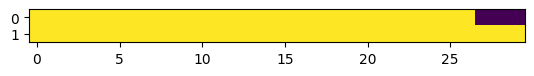

In [11]:
plt.imshow(residue_mask.numpy())
residue_mask.shape, residue_mask

**Atom coordinate fields**

The cache keeps deposited target coordinates separate from reference/template coordinates. The reference mask identifies which atom rows exist in the atom-token template, while the target atom mask tells us which coordinates can be used for training.

In [12]:
shard_atom_coords = torch.tensor(shard['atom_coords'], dtype=torch.float32)
shard_atom_mask = torch.tensor(shard['atom_mask'], dtype=torch.bool)
shard_reference_atom_coords = torch.tensor(shard['reference_atom_coords'], dtype=torch.float32)
shard_reference_atom_mask = torch.tensor(shard['reference_atom_mask'], dtype=torch.bool)

shard_atom_coords.shape, shard_atom_mask.shape, shard_reference_atom_coords.shape, shard_reference_atom_mask.shape

(torch.Size([113, 64, 37, 3]),
 torch.Size([113, 64, 37]),
 torch.Size([113, 64, 37, 3]),
 torch.Size([113, 64, 37]))

In [13]:
atom_coords_slots = shard_atom_coords[:batch_size, :context_size]
atom_mask_slots = shard_atom_mask[:batch_size, :context_size]
reference_atom_coords_slots = shard_reference_atom_coords[:batch_size, :context_size]
reference_atom_mask_slots = shard_reference_atom_mask[:batch_size, :context_size]

(torch.Size([2, 30, 37, 3]), torch.Size([2, 30, 37]))

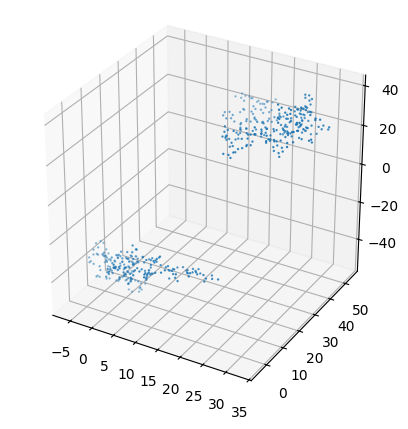

In [14]:
plot_coords(atom_coords_slots, atom_mask_slots)
atom_coords_slots.shape, atom_mask_slots.shape

(torch.Size([2, 30, 37, 3]), torch.Size([2, 30, 37]))

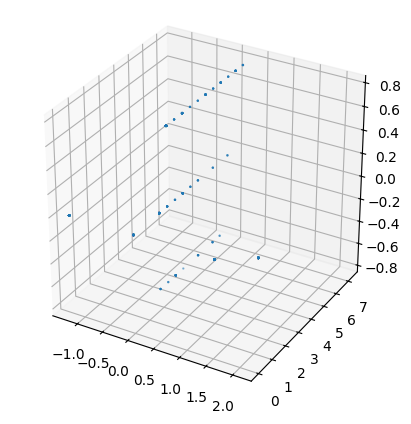

In [15]:
plot_coords(reference_atom_coords_slots, reference_atom_mask_slots)
reference_atom_coords_slots.shape, reference_atom_mask_slots.shape

**Atom identity fields**

Each atom row also carries the token it belongs to, an element ID, a formal charge, atom-name character IDs, and a reference-space ID. These are the atom-level inputs used by both the initial atom encoder and the denoiser atom encoder.

In [16]:
shard_atom_to_token = torch.tensor(shard['atom_to_token'], dtype=torch.long)
shard_atom_element = torch.tensor(shard['atom_element'], dtype=torch.long)
shard_atom_charge = torch.tensor(shard['atom_charge'], dtype=torch.float32)
shard_atom_name_chars = torch.tensor(shard['atom_name_chars'], dtype=torch.long)
shard_ref_space_uid = torch.tensor(shard['ref_space_uid'], dtype=torch.long)

shard_atom_to_token.shape, shard_atom_element.shape, shard_atom_charge.shape, shard_atom_name_chars.shape, shard_ref_space_uid.shape

(torch.Size([113, 64, 37]),
 torch.Size([113, 64, 37]),
 torch.Size([113, 64, 37]),
 torch.Size([113, 64, 37, 4]),
 torch.Size([113, 64, 37]))

In [17]:
atom_to_token_slots = shard_atom_to_token[:batch_size, :context_size]
atom_element_slots = shard_atom_element[:batch_size, :context_size]
atom_charge_slots = shard_atom_charge[:batch_size, :context_size]
atom_name_chars_slots = shard_atom_name_chars[:batch_size, :context_size]
ref_space_uid_slots = shard_ref_space_uid[:batch_size, :context_size]

In [18]:
atom_to_token_slots.shape, atom_to_token_slots

(torch.Size([2, 30, 37]),
 tensor([[[ 0,  0,  0,  ..., -1, -1, -1],
          [ 1,  1,  1,  ..., -1, -1, -1],
          [ 2,  2,  2,  ..., -1, -1, -1],
          ...,
          [-1, -1, -1,  ..., -1, -1, -1],
          [-1, -1, -1,  ..., -1, -1, -1],
          [-1, -1, -1,  ..., -1, -1, -1]],
 
         [[ 0,  0,  0,  ..., -1, -1, -1],
          [ 1,  1,  1,  ..., -1, -1, -1],
          [ 2,  2,  2,  ..., -1, -1, -1],
          ...,
          [27, 27, 27,  ..., -1, -1, -1],
          [28, 28, 28,  ..., -1, 28, -1],
          [29, 29, 29,  ..., -1, -1, -1]]]))

In [19]:
atom_element_slots.shape,  atom_element_slots

(torch.Size([2, 30, 37]),
 tensor([[[7, 6, 6,  ..., 0, 0, 0],
          [7, 6, 6,  ..., 0, 0, 0],
          [7, 6, 6,  ..., 0, 0, 0],
          ...,
          [0, 0, 0,  ..., 0, 0, 0],
          [0, 0, 0,  ..., 0, 0, 0],
          [0, 0, 0,  ..., 0, 0, 0]],
 
         [[7, 6, 6,  ..., 0, 0, 0],
          [7, 6, 6,  ..., 0, 0, 0],
          [7, 6, 6,  ..., 0, 0, 0],
          ...,
          [7, 6, 6,  ..., 0, 0, 0],
          [7, 6, 6,  ..., 0, 7, 0],
          [7, 6, 6,  ..., 0, 0, 0]]]))

In [20]:
atom_charge_slots.shape,  atom_charge_slots

(torch.Size([2, 30, 37]),
 tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]],
 
         [[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]]]))

In [21]:
atom_name_chars_slots.shape, atom_name_chars_slots

(torch.Size([2, 30, 37, 4]),
 tensor([[[[46,  0,  0,  0],
           [35, 33,  0,  0],
           [35,  0,  0,  0],
           ...,
           [ 0,  0,  0,  0],
           [ 0,  0,  0,  0],
           [ 0,  0,  0,  0]],
 
          [[46,  0,  0,  0],
           [35, 33,  0,  0],
           [35,  0,  0,  0],
           ...,
           [ 0,  0,  0,  0],
           [ 0,  0,  0,  0],
           [ 0,  0,  0,  0]],
 
          [[46,  0,  0,  0],
           [35, 33,  0,  0],
           [35,  0,  0,  0],
           ...,
           [ 0,  0,  0,  0],
           [ 0,  0,  0,  0],
           [ 0,  0,  0,  0]],
 
          ...,
 
          [[ 0,  0,  0,  0],
           [ 0,  0,  0,  0],
           [ 0,  0,  0,  0],
           ...,
           [ 0,  0,  0,  0],
           [ 0,  0,  0,  0],
           [ 0,  0,  0,  0]],
 
          [[ 0,  0,  0,  0],
           [ 0,  0,  0,  0],
           [ 0,  0,  0,  0],
           ...,
           [ 0,  0,  0,  0],
           [ 0,  0,  0,  0],
           [ 0,  0,  

In [22]:
ref_space_uid_slots.shape, ref_space_uid_slots

(torch.Size([2, 30, 37]),
 tensor([[[ 1,  1,  1,  ...,  0,  0,  0],
          [ 2,  2,  2,  ...,  0,  0,  0],
          [ 3,  3,  3,  ...,  0,  0,  0],
          ...,
          [ 0,  0,  0,  ...,  0,  0,  0],
          [ 0,  0,  0,  ...,  0,  0,  0],
          [ 0,  0,  0,  ...,  0,  0,  0]],
 
         [[ 1,  1,  1,  ...,  0,  0,  0],
          [ 2,  2,  2,  ...,  0,  0,  0],
          [ 3,  3,  3,  ...,  0,  0,  0],
          ...,
          [28, 28, 28,  ...,  0,  0,  0],
          [29, 29, 29,  ...,  0, 29,  0],
          [30, 30, 30,  ...,  0,  0,  0]]]))

**Bond and metadata fields**

`residue_atom_bonds` and `peptide_bond_mask` become the flattened atom-bond matrix. The token metadata stays on the residue axis and feeds the relative-position encodings. You'll notice that `token_bonds` is all false because, in our current single-chain standard-protein cache, we are not using the token-level bond channel for ordinary peptide adjacency. Also, since our examples are all single-chain, we can expect `asym_id`, `sym_id`, `entity_id`, and `mol_type` will all be set to zero. We include them to show how the model uses them should you expand to multi-chain, multi-molecule inputs.

You might be wondering why `peptide_bond_mask` shows false at the last real residue position if our second example has 30 residues. This is because a position in the mask looks to see if there's a peptide bond to the next position, which here there is not.

In [23]:
shard_residue_atom_bonds = torch.tensor(shard['residue_atom_bonds'], dtype=torch.bool)
shard_peptide_bond_mask = torch.tensor(shard['peptide_bond_mask'], dtype=torch.bool)
shard_token_bonds = torch.tensor(shard['token_bonds'], dtype=torch.bool)
shard_residue_index = torch.tensor(shard['residue_index'], dtype=torch.long)
shard_token_index = torch.tensor(shard['token_index'], dtype=torch.long)
shard_asym_id = torch.tensor(shard['asym_id'], dtype=torch.long)
shard_sym_id = torch.tensor(shard['sym_id'], dtype=torch.long)
shard_entity_id = torch.tensor(shard['entity_id'], dtype=torch.long)
shard_mol_type = torch.tensor(shard['mol_type'], dtype=torch.long)

shard.close()
shard_residue_atom_bonds.shape, shard_peptide_bond_mask.shape, shard_token_bonds.shape, shard_residue_index.shape, shard_token_index.shape, shard_asym_id.shape, shard_sym_id.shape, shard_entity_id.shape, shard_mol_type.shape


(torch.Size([113, 64, 37, 37]),
 torch.Size([113, 64]),
 torch.Size([113, 64, 64]),
 torch.Size([113, 64]),
 torch.Size([113, 64]),
 torch.Size([113, 64]),
 torch.Size([113, 64]),
 torch.Size([113, 64]),
 torch.Size([113, 64]))

In [24]:
residue_atom_bonds = shard_residue_atom_bonds[:batch_size, :context_size]
peptide_bond_mask = shard_peptide_bond_mask[:batch_size, :context_size]
token_bonds = shard_token_bonds[:batch_size, :context_size, :context_size]
residue_index = shard_residue_index[:batch_size, :context_size]
token_index = shard_token_index[:batch_size, :context_size]
asym_id = shard_asym_id[:batch_size, :context_size]
sym_id = shard_sym_id[:batch_size, :context_size]
entity_id = shard_entity_id[:batch_size, :context_size]
mol_type = shard_mol_type[:batch_size, :context_size]

In [25]:
residue_atom_bonds.shape, residue_atom_bonds

(torch.Size([2, 30, 37, 37]),
 tensor([[[[False,  True, False,  ..., False, False, False],
           [ True, False,  True,  ..., False, False, False],
           [False,  True, False,  ..., False, False, False],
           ...,
           [False, False, False,  ..., False, False, False],
           [False, False, False,  ..., False, False, False],
           [False, False, False,  ..., False, False, False]],
 
          [[False,  True, False,  ..., False, False, False],
           [ True, False,  True,  ..., False, False, False],
           [False,  True, False,  ..., False, False, False],
           ...,
           [False, False, False,  ..., False, False, False],
           [False, False, False,  ..., False, False, False],
           [False, False, False,  ..., False, False, False]],
 
          [[False,  True, False,  ..., False, False, False],
           [ True, False,  True,  ..., False, False, False],
           [False,  True, False,  ..., False, False, False],
           ...,
 

(torch.Size([2, 30]),
 tensor([[ True,  True,  True,  True,  True,  True,  True,  True,  True,  True,
           True,  True,  True,  True,  True,  True,  True,  True,  True,  True,
           True,  True,  True,  True,  True,  True, False, False, False, False],
         [ True,  True,  True,  True,  True,  True,  True,  True,  True,  True,
           True,  True,  True,  True,  True,  True,  True,  True,  True,  True,
           True,  True,  True,  True,  True,  True,  True,  True,  True, False]]))

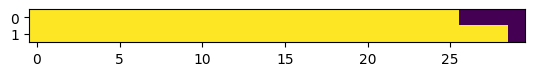

In [26]:
plt.imshow(peptide_bond_mask.numpy())
peptide_bond_mask.shape, peptide_bond_mask

In [27]:
token_bonds.shape, token_bonds

(torch.Size([2, 30, 30]),
 tensor([[[False, False, False,  ..., False, False, False],
          [False, False, False,  ..., False, False, False],
          [False, False, False,  ..., False, False, False],
          ...,
          [False, False, False,  ..., False, False, False],
          [False, False, False,  ..., False, False, False],
          [False, False, False,  ..., False, False, False]],
 
         [[False, False, False,  ..., False, False, False],
          [False, False, False,  ..., False, False, False],
          [False, False, False,  ..., False, False, False],
          ...,
          [False, False, False,  ..., False, False, False],
          [False, False, False,  ..., False, False, False],
          [False, False, False,  ..., False, False, False]]]))

In [28]:
residue_index.shape, residue_index

(torch.Size([2, 30]),
 tensor([[ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18,
          19, 20, 21, 22, 23, 24, 25, 26, 27,  0,  0,  0],
         [ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18,
          19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30]]))

In [29]:
token_index.shape, token_index

(torch.Size([2, 30]),
 tensor([[ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
          18, 19, 20, 21, 22, 23, 24, 25, 26,  0,  0,  0],
         [ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
          18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29]]))

In [30]:
asym_id.shape, asym_id

(torch.Size([2, 30]),
 tensor([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
          0, 0, 0, 0, 0, 0],
         [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
          0, 0, 0, 0, 0, 0]]))

In [31]:
sym_id.shape, sym_id

(torch.Size([2, 30]),
 tensor([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
          0, 0, 0, 0, 0, 0],
         [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
          0, 0, 0, 0, 0, 0]]))

In [32]:
entity_id.shape, entity_id

(torch.Size([2, 30]),
 tensor([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
          0, 0, 0, 0, 0, 0],
         [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
          0, 0, 0, 0, 0, 0]]))

In [33]:
mol_type.shape, mol_type

(torch.Size([2, 30]),
 tensor([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
          0, 0, 0, 0, 0, 0],
         [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
          0, 0, 0, 0, 0, 0]]))

### Flatten Atom Fields

The cache still has atoms in `[batch, residue, atom_slot, ...]` form. Our folding modules operate on a flattened atom axis, so each atom row carries its token index, reference-space ID, atom identity, and atom-bond information.

In [34]:
atom_slot_count = len(ATOM_SLOTS)
flat_atom_count = context_size * atom_slot_count
atom_slot_count, flat_atom_count

(37, 1110)

**Flatten coordinates**

We'll start with our atom coordinates. Recall that `ref_pos` is the model's reference atom geometry and `target_atom_coords` is the deposited structure used for diffusion and distance losses. In this compression, you'll see that we compress the residue and atom slot to create the 1110 flattened dimension. (We won't print this out as it won't help).

In [35]:
ref_pos = reference_atom_coords_slots.reshape(batch_size, flat_atom_count, 3)
target_atom_coords = atom_coords_slots.reshape(batch_size, flat_atom_count, 3)

ref_pos.shape, target_atom_coords.shape

(torch.Size([2, 1110, 3]), torch.Size([2, 1110, 3]))

**Flatten atom masks**

Now we need our masks to be similarly flattened. We'll flatten our masks so `atom_attention_mask` marks atom rows that exist in the reference/template and `coordinate_atom_mask` marks atom rows that also have supervised target coordinates.

In [36]:
atom_attention_mask = reference_atom_mask_slots.reshape(batch_size, flat_atom_count)
coordinate_atom_mask = atom_mask_slots.reshape(batch_size, flat_atom_count) & atom_attention_mask

torch.Size([2, 1110])

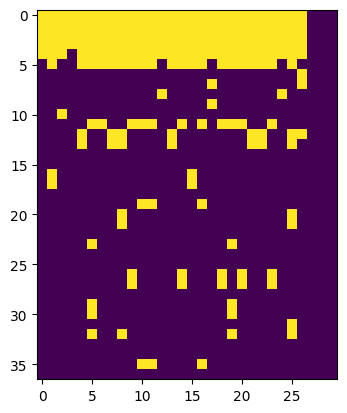

In [37]:
plt.imshow(atom_attention_mask[0].view(context_size, atom_slot_count).T.numpy())
atom_attention_mask.shape

torch.Size([2, 1110])

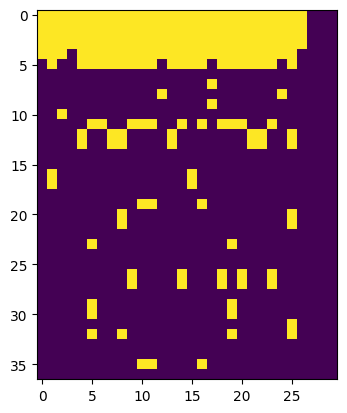

In [38]:
plt.imshow(coordinate_atom_mask[0].view(context_size, atom_slot_count).T.numpy())
coordinate_atom_mask.shape

**Flatten atom identity**

We'll now update the atom identity to do similar flattening. These fields stay one row per atom. `atom_to_token` is the bridge from the flattened atom axis back to the residue/token axis.

In [39]:
atom_to_token = atom_to_token_slots.reshape(batch_size, flat_atom_count)
ref_space_uid = ref_space_uid_slots.reshape(batch_size, flat_atom_count)
atom_element = atom_element_slots.reshape(batch_size, flat_atom_count)
atom_charge = atom_charge_slots.reshape(batch_size, flat_atom_count)
atom_name_chars = atom_name_chars_slots.reshape(batch_size, flat_atom_count, atom_name_chars_slots.size(-1))

atom_to_token.shape, ref_space_uid.shape, atom_element.shape, atom_charge.shape, atom_name_chars.shape, 

(torch.Size([2, 1110]),
 torch.Size([2, 1110]),
 torch.Size([2, 1110]),
 torch.Size([2, 1110]),
 torch.Size([2, 1110, 4]))

**Active atom-to-token indices**

We'll now update our attention mask to ensure we only keep atom rows that are both real atoms and actually attached to a residue. While we did this filtering in our data preprocessing since we're focused on single-chain proteins, if we were doing multi-chain proteins and other molecule types this would help add the other filter. This updated mask helps us update `atom_to_token` to ensure it's focused just on atoms tied to proteins.

In [40]:
atom_attention_mask = atom_attention_mask & (atom_to_token >= 0)
safe_atom_to_token = torch.where(
    atom_attention_mask,
    atom_to_token.clamp_min(0),
    torch.zeros_like(atom_to_token),
)
safe_atom_to_token.shape, safe_atom_to_token


(torch.Size([2, 1110]),
 tensor([[0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0]]))

torch.Size([2, 30])

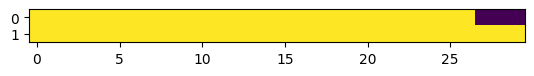

In [41]:
token_attention_mask = residue_mask

plt.imshow(token_attention_mask.numpy())
token_attention_mask.shape

**Intra-residue atom bonds**

The cache stores bonds inside each residue in atom-slot coordinates. We copy each residue block into the flattened atom-by-atom bond matrix.

In [42]:
atom_bonds = torch.zeros(batch_size, flat_atom_count, flat_atom_count, dtype=torch.bool)
atom_bonds.shape

torch.Size([2, 1110, 1110])

In [43]:
for residue_position in range(context_size):
    atom_start = residue_position * atom_slot_count
    atom_end = atom_start + atom_slot_count
    residue_reference_mask = reference_atom_mask_slots[:, residue_position]
    residue_bonds = residue_atom_bonds[:, residue_position]
    residue_bonds = residue_bonds & residue_reference_mask[:, :, None] & residue_reference_mask[:, None, :]
    atom_bonds[:, atom_start:atom_end, atom_start:atom_end] = residue_bonds

(torch.Size([2, 1110, 1110]), tensor(True))

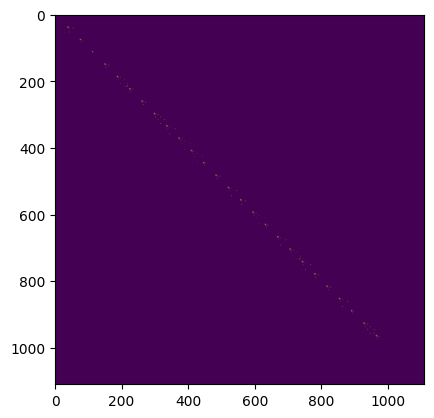

In [44]:
plt.imshow(atom_bonds[0].numpy())
atom_bonds.shape, atom_bonds.any()

**Peptide bonds**

The peptide-bond mask connects the C atom of one residue to the N atom of the next residue. This creates atom-level bond bias across residue boundaries.

In [45]:
c_index = ATOM_SLOTS.index('C')
n_index = ATOM_SLOTS.index('N')
c_index, n_index

(2, 0)

In [46]:
for residue_position in range(context_size - 1):
    atom_a = residue_position * atom_slot_count + c_index
    atom_b = (residue_position + 1) * atom_slot_count + n_index
    valid_peptide_bond = (
        peptide_bond_mask[:, residue_position]
        & reference_atom_mask_slots[:, residue_position, c_index]
        & reference_atom_mask_slots[:, residue_position + 1, n_index]
    )
    atom_bonds[:, atom_a, atom_b] = valid_peptide_bond
    atom_bonds[:, atom_b, atom_a] = valid_peptide_bond

(torch.Size([2, 1110, 1110]), tensor(940))

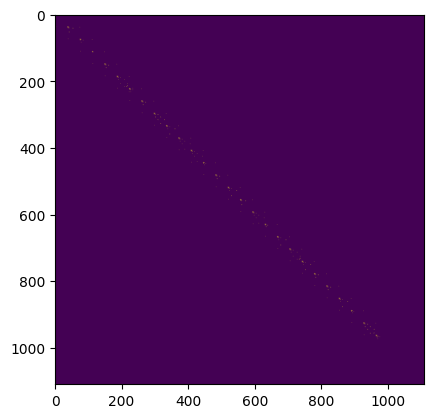

In [47]:
plt.imshow(atom_bonds[0].numpy())
atom_bonds.shape, atom_bonds.sum()

**Representative atom for pair distances**

The pair losses and distogram need one representative atom per residue. We use CB when present, then CA, then the first valid atom. The model still predicts all atom rows but this representative choice is only for pair-distance supervision.

In [48]:
positions = torch.arange(context_size).view(1, context_size).expand(batch_size, context_size)
cb_index = ATOM_SLOTS.index('CB')
ca_index = ATOM_SLOTS.index('CA')

In [49]:
first_valid_atom = reference_atom_mask_slots.float().argmax(dim=-1)
cb_atom_idx = positions * atom_slot_count + cb_index
ca_atom_idx = positions * atom_slot_count + ca_index

In [50]:
distogram_atom_idx = torch.where(
    reference_atom_mask_slots[:, :, cb_index],
    cb_atom_idx,
    torch.where(reference_atom_mask_slots[:, :, ca_index], ca_atom_idx, positions * atom_slot_count + first_valid_atom),
)

distogram_atom_idx.shape, distogram_atom_idx

(torch.Size([2, 30]),
 tensor([[   4,   41,   78,  112,  152,  189,  226,  263,  300,  337,  374,  411,
           448,  485,  522,  559,  596,  633,  670,  707,  744,  781,  818,  855,
           892,  929,  966,  999, 1036, 1073],
         [   4,   41,   78,  115,  152,  189,  226,  260,  300,  337,  374,  411,
           448,  485,  522,  559,  596,  633,  670,  704,  744,  781,  815,  855,
           892,  929,  966, 1003, 1040, 1077]]))

## Forward Pass

The forward pass takes residue tokens, atom-level reference features, deposited target coordinates, atom masks, bond features, and residue metadata. The folding core first gets PLM hidden states, builds token and pair representations, refines the pair stream through recycling, and predicts a distogram.

This notebook stops after the recycling trunk and distogram loss. The diffusion head and confidence head are separate components, so they stay out of this walkthrough.

## PLM Hidden States `ProteinLM`

We'll start by converting our residue chain into embeddings. This step takes our `input_ids` and chain metadata and does a forward pass through our trained PLM. This, in theory, helps augment the input ID with extra information on how that chain of residues is best represented in relation to all other proteins the PLM saw in training. You can think of this as a learned MSA, clustering, and all sorts of other protein relationships jammed into a series of embeddings. We use the `hidden_states` output from the PLM. As a reminder, this will include our embedding projection, the output of each transformer layer, and a normalized version of the final layer.

We'll get this by loading in the checkpoint, then running a forward pass.

In [51]:
checkpoint_path = Path('~/model/protein_folding/protein_lm.pt').expanduser()
checkpoint_path.name

'protein_lm.pt'

In [52]:
checkpoint = torch.load(checkpoint_path, map_location='cpu')
protein_lm = ProteinLM(ProteinLMConfig(**checkpoint['config']))

In [53]:
protein_lm.load_state_dict(checkpoint['model'])
protein_lm.eval()

ProteinLM(
  (token_embedding): Embedding(64, 64, padding_idx=1)
  (blocks): ModuleList(
    (0-2): 3 x ProteinTransformerBlock(
      (attention_norm): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
      (attention): ProteinSelfAttention(
        (qkv): Linear(in_features=64, out_features=192, bias=False)
        (output): Linear(in_features=64, out_features=64, bias=False)
        (dropout): Dropout(p=0.1, inplace=False)
        (query_norm): LayerNorm((16,), eps=1e-05, elementwise_affine=True)
        (key_norm): LayerNorm((16,), eps=1e-05, elementwise_affine=True)
        (rope): RotaryPositionEmbedding()
      )
      (mlp_norm): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
      (mlp): ProteinMLP(
        (fc): Linear(in_features=64, out_features=512, bias=False)
        (projection): Linear(in_features=256, out_features=64, bias=False)
      )
    )
  )
  (final_norm): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
  (sequence_head): Sequential(
    (0): Lin

In [54]:
with torch.no_grad():
    lm_output = protein_lm(input_ids, token_attention_mask, asym_id=asym_id, residue_index=residue_index, mol_type=mol_type)
    

In [55]:
lm_hidden_states = lm_output['hidden_states']
lm_hidden_states.shape, lm_hidden_states

(torch.Size([2, 30, 4, 64]),
 tensor([[[[ 2.8838e-02, -2.7398e-02, -2.2011e-02,  ...,  8.9524e-03,
            -1.2045e-02,  2.0018e-03],
           [ 2.9519e-02, -4.1004e-02, -3.6296e-02,  ...,  2.3174e-02,
            -1.7454e-02, -1.5967e-02],
           [ 5.1493e-02, -1.7748e-02, -5.1777e-02,  ..., -5.0757e-03,
             4.8927e-03, -4.0971e-02],
           [ 6.9566e-01,  1.2485e-01, -2.1159e+00,  ...,  1.5530e-01,
             4.3529e-02, -1.1465e+00]],
 
          [[ 2.1701e-02, -2.4549e-02, -2.4577e-02,  ..., -1.9018e-02,
             6.7759e-03, -1.0060e-02],
           [-2.6068e-02, -1.0683e-02, -1.9043e-02,  ..., -2.0268e-02,
             2.7252e-03,  8.5139e-03],
           [-4.6194e-03, -3.9888e-02, -1.4189e-02,  ..., -2.7491e-02,
             1.1739e-02,  1.3122e-02],
           [-5.0407e-01, -2.4070e-01, -6.6798e-01,  ..., -6.5846e-01,
            -2.0906e-01,  5.1941e-02]],
 
          [[-3.0595e-02,  1.9904e-02, -2.3047e-02,  ...,  1.4321e-02,
             1.1820e-02

## Unify Language Model Representations `LanguageModelShim`

<img src="explainer_screenshots/3a_foldingcore/languagemodelshim.png" width="300">

You can see that the PLM gave us 4 embedding representations of each residue for each example. We'll now want to pull them down into a single embedding, and then a residue-pair representation but we want to let the model learn the best way to combine the layers together.

To do this we:
1. Layer normalize each PLM hidden layer
2. Project each layer from the PLM embedding width into the folding model’s pair width
3. Multiply each projected layer by learned softmax weights. Softmax ensures that the scaling across the layers sums to 1 (e.g. 10% of layer 1, 20% of layer 2...etc)
4. Sum across the layer axis to collapse the full hidden-state stack into one residue representation per token.
5. Mask out padded residue positions so fake tokens do not contribute.
6. Down-project the mixed residue features into the pair-building space.
7. Compare every residue against every other residue by building pairwise product and difference features.
8. Run those pairwise features through a small feed-forward network.

This basically lets the model learn what percentage of each layer to use, do a weighted average based on that, and then create a pairwise relationship between the residues that lets the model learn how the embeddings relate.

**Projected resize of hidden state**

We'll start by first normalizing and then projecting the LM hidden state to the embedding dimension we'll use for our pairwise representation. For this case we'll use a small 8-dimensional embedding. This will be a large step down from the 64 the PLM used.

In [56]:
pair_dim = 8
lm_dim = lm_hidden_states.size(-1)
lm_layer_count = lm_hidden_states.size(2)

pair_dim, lm_dim, lm_layer_count

(8, 64, 4)

In [57]:
lm_projection = nn.Sequential(
    nn.LayerNorm(lm_dim), 
    nn.Linear(lm_dim, pair_dim, bias=False)
)

projected_lm_layers = lm_projection(lm_hidden_states)
projected_lm_layers.shape, projected_lm_layers

(torch.Size([2, 30, 4, 8]),
 tensor([[[[-0.6470, -0.6829, -0.4115,  ..., -0.4121, -0.0822, -0.6028],
           [-0.3628, -0.6297,  0.2012,  ..., -0.2732,  0.3002, -0.2608],
           [-0.9276, -0.5294, -0.4330,  ..., -0.7631,  0.0448, -0.3680],
           [-0.0284, -0.7133, -0.6917,  ..., -0.2538, -0.4711, -0.3844]],
 
          [[-0.1036, -0.5402,  0.3857,  ...,  0.2028,  0.5217,  0.6738],
           [-0.2820, -0.4075,  0.7506,  ..., -0.3272,  0.6646,  0.3393],
           [-0.5828, -0.4007,  0.7169,  ...,  0.0617,  0.5158,  0.3701],
           [-0.6555, -0.3024,  0.6051,  ...,  0.3738,  0.1491,  0.3884]],
 
          [[ 0.0246, -0.2407,  0.8162,  ...,  0.8016,  0.1676,  0.8183],
           [-0.2064, -0.0506,  1.0731,  ...,  0.4326,  0.5278,  0.5757],
           [-0.3240, -0.5486,  0.2568,  ...,  0.3392,  0.2168,  0.6174],
           [ 0.0089, -1.1047,  0.1045,  ...,  0.5281,  0.5798,  0.8222]],
 
          ...,
 
          [[ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000

**Weighted layer average**

Now we'll create our layer weighting and then use it to take the weighted average across the layers to generate a single per-example, per-residue embedding. You'll see that we start out with equal weight across all layers. After we take the sum, we'll then apply our residue mask to zero out padding and do another projection.

In [58]:
lm_layer_weights = nn.Parameter(torch.ones(lm_layer_count))
lm_layer_values = F.softmax(lm_layer_weights, dim=0)
lm_layer_values = lm_layer_values[None, None, :, None]
lm_layer_values.shape, lm_layer_values

(torch.Size([1, 1, 4, 1]),
 tensor([[[[0.2500],
           [0.2500],
           [0.2500],
           [0.2500]]]], grad_fn=<UnsqueezeBackward0>))

In [59]:
lm_mixed = (projected_lm_layers * lm_layer_values).sum(dim=2)
lm_mixed = lm_mixed * token_attention_mask.unsqueeze(-1)
lm_mixed.shape, lm_mixed

(torch.Size([2, 30, 8]),
 tensor([[[-0.4915, -0.6388, -0.3338, -0.3844,  0.4353, -0.4255, -0.0521,
           -0.4040],
          [-0.4060, -0.4127,  0.6146, -0.1984, -0.7483,  0.0778,  0.4628,
            0.4429],
          [-0.1242, -0.4862,  0.5627,  0.0652,  0.8034,  0.5254,  0.3730,
            0.7084],
          [ 0.2364,  0.6997,  0.0269,  0.1906,  0.0229,  0.3397, -0.0786,
            0.0721],
          [ 0.3918,  0.2963,  0.3797,  0.5462, -0.7142, -0.5215,  0.1921,
            0.2599],
          [ 0.1208,  0.3892,  0.3334, -0.3461,  0.7242,  1.2928, -0.5360,
           -0.3995],
          [-0.8279,  0.4083, -0.0986,  1.1713,  0.8721, -0.0053, -0.7412,
            0.6174],
          [ 0.3100,  0.3205,  0.4544,  0.5360, -0.6666, -0.5142,  0.0128,
            0.1570],
          [-0.0026,  0.1460, -0.3704, -0.2558,  0.0015, -0.7230,  0.3288,
           -0.1623],
          [-0.0424,  0.0121,  0.7440,  0.1270, -0.0868,  0.0499, -0.5157,
            0.8198],
          [ 0.4093, -0.11

In [60]:
lm_pair_downproject = nn.Linear(pair_dim, pair_dim)
lm_pair_base = lm_pair_downproject(lm_mixed)
lm_pair_base.shape, lm_pair_base

(torch.Size([2, 30, 8]),
 tensor([[[ 0.4203,  0.1667, -0.3071,  0.1703,  0.1162, -0.4042, -0.1264,
            0.1460],
          [ 0.2325,  0.3764, -0.0245,  0.0305,  0.3488, -0.1425,  0.1451,
           -0.4197],
          [ 0.5169, -0.0994, -0.5081,  0.6207, -0.0318, -0.0839, -0.2200,
            0.2488],
          [-0.1167,  0.0144, -0.3237, -0.1695,  0.3961,  0.1152,  0.1131,
            0.3679],
          [-0.4659,  0.2050, -0.1184, -0.3358,  0.5972, -0.1108,  0.2400,
            0.0493],
          [ 0.4995, -0.3685, -0.9614,  0.3571,  0.1439,  0.3569,  0.1175,
            0.5786],
          [-0.3273, -0.0233, -0.1260,  0.9299,  0.8321,  0.0770, -0.8580,
            0.6811],
          [-0.4620,  0.1796, -0.1806, -0.2297,  0.6751, -0.0773,  0.2126,
            0.0697],
          [ 0.0329,  0.3549, -0.0230, -0.4266,  0.2251, -0.4136,  0.1284,
            0.0667],
          [-0.1830,  0.1157, -0.3280,  0.5353,  0.6808,  0.1146, -0.1714,
            0.0146],
          [-0.5199, -0.17

**Pairwise Comparison**

Now that we have our summation and projection from our hidden layers to our pairwise embedding space, we're ready to build up our pairwise representation. For this we need to compare every residue to every other residue so that we go from $[\text{batch},\text{context},\text{embedding}]$ to $[\text{batch},\text{context},\text{context},\text{embedding}]$. We'll calculate two comparisons:
1. The product which captures where two residues have matching or reinforcing features. If residue $i$ and $j$ both have high values in the same feature, the product is high.
2. The difference which captures how residue $i$ differs from $j$ and embeds directionality since $i - j$ is not the same as $j - i$. We then concatenate these to create a single representation of the pairwise relationship.

In [61]:
lm_pair_product = lm_pair_base[:, :, None, :] * lm_pair_base[:, None, :, :]
lm_pair_product.shape, lm_pair_product

(torch.Size([2, 30, 30, 8]),
 tensor([[[[ 0.1766,  0.0278,  0.0943,  ...,  0.1634,  0.0160,  0.0213],
           [ 0.0977,  0.0628,  0.0075,  ...,  0.0576, -0.0183, -0.0613],
           [ 0.2172, -0.0166,  0.1560,  ...,  0.0339,  0.0278,  0.0363],
           ...,
           [ 0.0271,  0.0153,  0.0923,  ...,  0.0404, -0.0065,  0.0279],
           [ 0.0271,  0.0153,  0.0923,  ...,  0.0404, -0.0065,  0.0279],
           [ 0.0271,  0.0153,  0.0923,  ...,  0.0404, -0.0065,  0.0279]],
 
          [[ 0.0977,  0.0628,  0.0075,  ...,  0.0576, -0.0183, -0.0613],
           [ 0.0541,  0.1417,  0.0006,  ...,  0.0203,  0.0211,  0.1761],
           [ 0.1202, -0.0374,  0.0124,  ...,  0.0120, -0.0319, -0.1044],
           ...,
           [ 0.0150,  0.0345,  0.0074,  ...,  0.0143,  0.0075, -0.0801],
           [ 0.0150,  0.0345,  0.0074,  ...,  0.0143,  0.0075, -0.0801],
           [ 0.0150,  0.0345,  0.0074,  ...,  0.0143,  0.0075, -0.0801]],
 
          [[ 0.2172, -0.0166,  0.1560,  ...,  0.0339,  0.

In [62]:
lm_pair_difference = lm_pair_base[:, :, None, :] - lm_pair_base[:, None, :, :]
lm_pair_difference.shape, lm_pair_difference

(torch.Size([2, 30, 30, 8]),
 tensor([[[[ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
           [ 0.1877, -0.2097, -0.2826,  ..., -0.2617, -0.2715,  0.5657],
           [-0.0966,  0.2662,  0.2010,  ..., -0.3203,  0.0936, -0.1028],
           ...,
           [ 0.3557,  0.0750, -0.0064,  ..., -0.3042, -0.1781, -0.0449],
           [ 0.3557,  0.0750, -0.0064,  ..., -0.3042, -0.1781, -0.0449],
           [ 0.3557,  0.0750, -0.0064,  ..., -0.3042, -0.1781, -0.0449]],
 
          [[-0.1877,  0.2097,  0.2826,  ...,  0.2617,  0.2715, -0.5657],
           [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
           [-0.2844,  0.4759,  0.4836,  ..., -0.0587,  0.3651, -0.6685],
           ...,
           [ 0.1680,  0.2847,  0.2762,  ..., -0.0425,  0.0934, -0.6106],
           [ 0.1680,  0.2847,  0.2762,  ..., -0.0425,  0.0934, -0.6106],
           [ 0.1680,  0.2847,  0.2762,  ..., -0.0425,  0.0934, -0.6106]],
 
          [[ 0.0966, -0.2662, -0.2010,  ...,  0.3203, -0.

In [63]:
lm_pair = torch.cat([lm_pair_product, lm_pair_difference], dim=-1)
lm_pair.shape, lm_pair

(torch.Size([2, 30, 30, 16]),
 tensor([[[[ 1.7662e-01,  2.7806e-02,  9.4286e-02,  ...,  0.0000e+00,
             0.0000e+00,  0.0000e+00],
           [ 9.7730e-02,  6.2771e-02,  7.5176e-03,  ..., -2.6166e-01,
            -2.7150e-01,  5.6570e-01],
           [ 2.1724e-01, -1.6579e-02,  1.5602e-01,  ..., -3.2033e-01,
             9.3574e-02, -1.0278e-01],
           ...,
           [ 2.7145e-02,  1.5300e-02,  9.2324e-02,  ..., -3.0420e-01,
            -1.7808e-01, -4.4874e-02],
           [ 2.7145e-02,  1.5300e-02,  9.2324e-02,  ..., -3.0420e-01,
            -1.7808e-01, -4.4874e-02],
           [ 2.7145e-02,  1.5300e-02,  9.2324e-02,  ..., -3.0420e-01,
            -1.7808e-01, -4.4874e-02]],
 
          [[ 9.7730e-02,  6.2771e-02,  7.5176e-03,  ...,  2.6166e-01,
             2.7150e-01, -5.6570e-01],
           [ 5.4077e-02,  1.4170e-01,  5.9940e-04,  ...,  0.0000e+00,
             0.0000e+00,  0.0000e+00],
           [ 1.2020e-01, -3.7427e-02,  1.2439e-02,  ..., -5.8678e-02,
         

**Pairwise Feed Forward**

You'll notice now that we have double the embedding dimensions expected for our pairwise. We'll use a feed forward layer (linear, tanh, linear, layer norm) to project back to the pairwise embedding space and give the ability to learn how to best weight the different residue interactions. At the end we'll do a final level of masking on the pairwise dimension which will require us building a pairwise mask.

In [64]:
lm_pair_output = nn.Sequential(
    nn.Linear(2 * pair_dim, pair_dim),
    nn.GELU(approximate='tanh'),
    nn.Linear(pair_dim, pair_dim),
    nn.LayerNorm(pair_dim),
)

lm_pair = lm_pair_output(lm_pair)
lm_pair.shape, lm_pair

(torch.Size([2, 30, 30, 8]),
 tensor([[[[-1.3433,  0.6668,  1.2423,  ...,  0.7200,  0.5438, -1.8411],
           [-1.4626,  0.8573,  1.1763,  ...,  0.6336,  0.4053, -1.7739],
           [-0.9634,  0.4557,  1.4973,  ...,  0.6752,  0.5358, -1.9616],
           ...,
           [-1.2382,  0.8437,  1.0774,  ...,  0.6396,  0.7210, -1.9106],
           [-1.2382,  0.8437,  1.0774,  ...,  0.6396,  0.7210, -1.9106],
           [-1.2382,  0.8437,  1.0774,  ...,  0.6396,  0.7210, -1.9106]],
 
          [[-1.1728,  0.5283,  1.2640,  ...,  0.7888,  0.7228, -1.8880],
           [-1.2257,  0.6251,  1.3165,  ...,  0.6895,  0.5601, -1.8918],
           [-0.8809,  0.3333,  1.4948,  ...,  0.7580,  0.6657, -1.9371],
           ...,
           [-1.1078,  0.7398,  1.1167,  ...,  0.7332,  0.8243, -1.9130],
           [-1.1078,  0.7398,  1.1167,  ...,  0.7332,  0.8243, -1.9130],
           [-1.1078,  0.7398,  1.1167,  ...,  0.7332,  0.8243, -1.9130]],
 
          [[-1.6793,  0.9156,  0.9045,  ...,  0.7587,  0.

In [65]:
pair_mask = (token_attention_mask[:, :, None] & token_attention_mask[:, None, :]).unsqueeze(-1)
lm_pair = lm_pair * pair_mask
lm_pair.shape, lm_pair

(torch.Size([2, 30, 30, 8]),
 tensor([[[[-1.3433,  0.6668,  1.2423,  ...,  0.7200,  0.5438, -1.8411],
           [-1.4626,  0.8573,  1.1763,  ...,  0.6336,  0.4053, -1.7739],
           [-0.9634,  0.4557,  1.4973,  ...,  0.6752,  0.5358, -1.9616],
           ...,
           [-0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000, -0.0000],
           [-0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000, -0.0000],
           [-0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000, -0.0000]],
 
          [[-1.1728,  0.5283,  1.2640,  ...,  0.7888,  0.7228, -1.8880],
           [-1.2257,  0.6251,  1.3165,  ...,  0.6895,  0.5601, -1.8918],
           [-0.8809,  0.3333,  1.4948,  ...,  0.7580,  0.6657, -1.9371],
           ...,
           [-0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000, -0.0000],
           [-0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000, -0.0000],
           [-0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000, -0.0000]],
 
          [[-1.6793,  0.9156,  0.9045,  ...,  0.7587,  0.

## Embed Inputs `InputsEmbedder`

<img src="explainer_screenshots/3a_foldingcore/inputsembedder.png" width="600">

Now we'll build the model's first folding input representation. The PLM path gave us learned sequence context, but the folding model also needs the structure-side inputs from our cache based on the residue type, reference atom positions, atom identity, atom masks, atom bonds, and the mapping from atoms back to residue tokens. We'll first embed the atom-level information and use a protein-specific attention to let nearby or bonded atoms exchange information. Then we'll gather those atom features back onto the residue axis so each residue gets a learned summary of its atoms. To do this we:

1. Project each reference atom coordinate into the atom embedding width.
2. Add in the atom identity features including element, charge, atom-name characters, atom mask, and reference-space ID.
3. Apply the protein-specific version of multi-head dot-product attention that includes RoPE.
4. Collect the atom embeddings back to their residue position
5. Since we do not have an MSA, we keep this simple. We set up a residue one-hot that tells the model which amino acid is present and it becomes the profile. We also set the deletion feature to all zeros.
6. Concatenate the atom-derived residue features, residue identity, profile, and deletion feature.
7. Normalize the combined input. In the production module, this is where the model masks out padded residue positions again; in this walkthrough, we skip that repeated mask because the shown example rows are already zero.

This basically turns the cache fields into our input which is one residue-level input embedding per token. This input, different from our lm_pair we just built, is a second model input built from the atom, MSA, and residue information.

### Atom Input Features

We'll start out by projecting our atom features into their embedding space. We'll use a shared width to unify dimensions to make summing easier, though, you don't have to and can handle it during summing if you're feeling wild. Each flattened atom gets reference coordinates, element ID, formal charge, atom-name characters, an atom-existence mask signal, and a reference-space ID. These are summed into the atom feature width before atom attention.

In [66]:
atom_dim = 8
ATOM_PADDING_INDEX = 0

**Embed and Project Atom Features**

We'll start by embedding and projecting our different atom-level features. This will unify all the features into the same dimension embedding space.

*Note that with some layers we'll pass in the padding index. By setting that index, the embedding weights will be set to zero and they'll automatically skip any gradient updates.*

In [67]:
name_char_embedding = nn.Embedding(ATOM_NAME_CHAR_VOCAB_SIZE, atom_dim, padding_idx=ATOM_PADDING_INDEX)
atom_name_features = name_char_embedding(atom_name_chars).sum(dim=-2)
atom_name_features.shape, atom_name_features

(torch.Size([2, 1110, 8]),
 tensor([[[ 0.1061, -0.1819, -0.0099,  ..., -1.5735,  0.4992,  1.3917],
          [-0.9518,  0.3548, -0.4102,  ..., -0.1197,  0.6117, -2.3145],
          [ 0.1099,  0.1126, -0.9057,  ..., -0.0947,  1.0247, -2.1305],
          ...,
          [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
          [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
          [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000]],
 
         [[ 0.1061, -0.1819, -0.0099,  ..., -1.5735,  0.4992,  1.3917],
          [-0.9518,  0.3548, -0.4102,  ..., -0.1197,  0.6117, -2.3145],
          [ 0.1099,  0.1126, -0.9057,  ..., -0.0947,  1.0247, -2.1305],
          ...,
          [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
          [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
          [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000]]],
        grad_fn=<SumBackward1>))

In [68]:
reference_projection = nn.Linear(3, atom_dim)
atom_ref_features = reference_projection(ref_pos)
atom_ref_features.shape, atom_ref_features

(torch.Size([2, 1110, 8]),
 tensor([[[-0.4262,  0.6159, -0.2702,  ..., -0.1378, -0.7820, -0.6619],
          [-0.1863,  0.3893,  0.2340,  ..., -0.0885, -0.0733, -0.2249],
          [ 0.1054,  0.1137,  0.8470,  ..., -0.0285,  0.7885,  0.3065],
          ...,
          [-0.1863,  0.3893,  0.2340,  ..., -0.0885, -0.0733, -0.2249],
          [-0.1863,  0.3893,  0.2340,  ..., -0.0885, -0.0733, -0.2249],
          [-0.1863,  0.3893,  0.2340,  ..., -0.0885, -0.0733, -0.2249]],
 
         [[-0.4262,  0.6159, -0.2702,  ..., -0.1378, -0.7820, -0.6619],
          [-0.1863,  0.3893,  0.2340,  ..., -0.0885, -0.0733, -0.2249],
          [ 0.1054,  0.1137,  0.8470,  ..., -0.0285,  0.7885,  0.3065],
          ...,
          [-0.1863,  0.3893,  0.2340,  ..., -0.0885, -0.0733, -0.2249],
          [-0.1863,  0.3893,  0.2340,  ..., -0.0885, -0.0733, -0.2249],
          [-0.1863,  0.3893,  0.2340,  ..., -0.0885, -0.0733, -0.2249]]],
        grad_fn=<AddBackward0>))

In [69]:
element_embedding = nn.Embedding(ATOM_ELEMENT_VOCAB_SIZE, atom_dim, padding_idx=0)
atom_element_features = element_embedding(atom_element)
atom_element_features.shape, atom_element_features

(torch.Size([2, 1110, 8]),
 tensor([[[ 0.2647, -1.5598, -1.7260,  ...,  1.3161,  0.8895, -0.0795],
          [ 0.8198, -1.0822,  0.4203,  ...,  1.0607,  0.6459, -1.2816],
          [ 0.8198, -1.0822,  0.4203,  ...,  1.0607,  0.6459, -1.2816],
          ...,
          [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
          [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
          [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000]],
 
         [[ 0.2647, -1.5598, -1.7260,  ...,  1.3161,  0.8895, -0.0795],
          [ 0.8198, -1.0822,  0.4203,  ...,  1.0607,  0.6459, -1.2816],
          [ 0.8198, -1.0822,  0.4203,  ...,  1.0607,  0.6459, -1.2816],
          ...,
          [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
          [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
          [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000]]],
        grad_fn=<EmbeddingBackward0>))

In [70]:
charge_projection = nn.Linear(1, atom_dim)
atom_charge_features = charge_projection(atom_charge.unsqueeze(-1))
atom_charge_features.shape, atom_charge_features

(torch.Size([2, 1110, 8]),
 tensor([[[-0.1413,  0.6950,  0.7814,  ...,  0.4915, -0.7396,  0.4317],
          [-0.1413,  0.6950,  0.7814,  ...,  0.4915, -0.7396,  0.4317],
          [-0.1413,  0.6950,  0.7814,  ...,  0.4915, -0.7396,  0.4317],
          ...,
          [-0.1413,  0.6950,  0.7814,  ...,  0.4915, -0.7396,  0.4317],
          [-0.1413,  0.6950,  0.7814,  ...,  0.4915, -0.7396,  0.4317],
          [-0.1413,  0.6950,  0.7814,  ...,  0.4915, -0.7396,  0.4317]],
 
         [[-0.1413,  0.6950,  0.7814,  ...,  0.4915, -0.7396,  0.4317],
          [-0.1413,  0.6950,  0.7814,  ...,  0.4915, -0.7396,  0.4317],
          [-0.1413,  0.6950,  0.7814,  ...,  0.4915, -0.7396,  0.4317],
          ...,
          [-0.1413,  0.6950,  0.7814,  ...,  0.4915, -0.7396,  0.4317],
          [-0.1413,  0.6950,  0.7814,  ...,  0.4915, -0.7396,  0.4317],
          [-0.1413,  0.6950,  0.7814,  ...,  0.4915, -0.7396,  0.4317]]],
        grad_fn=<AddBackward0>))

In [71]:
mask_projection = nn.Linear(1, atom_dim)
atom_mask_features = mask_projection(atom_attention_mask.to(ref_pos.dtype).unsqueeze(-1))
atom_mask_features.shape, atom_mask_features

(torch.Size([2, 1110, 8]),
 tensor([[[-0.7534, -0.0646,  0.3393,  ...,  0.8617,  0.2364,  0.3741],
          [-0.7534, -0.0646,  0.3393,  ...,  0.8617,  0.2364,  0.3741],
          [-0.7534, -0.0646,  0.3393,  ...,  0.8617,  0.2364,  0.3741],
          ...,
          [-0.2795,  0.1148,  0.7773,  ...,  0.8713, -0.2823, -0.1013],
          [-0.2795,  0.1148,  0.7773,  ...,  0.8713, -0.2823, -0.1013],
          [-0.2795,  0.1148,  0.7773,  ...,  0.8713, -0.2823, -0.1013]],
 
         [[-0.7534, -0.0646,  0.3393,  ...,  0.8617,  0.2364,  0.3741],
          [-0.7534, -0.0646,  0.3393,  ...,  0.8617,  0.2364,  0.3741],
          [-0.7534, -0.0646,  0.3393,  ...,  0.8617,  0.2364,  0.3741],
          ...,
          [-0.2795,  0.1148,  0.7773,  ...,  0.8713, -0.2823, -0.1013],
          [-0.2795,  0.1148,  0.7773,  ...,  0.8713, -0.2823, -0.1013],
          [-0.2795,  0.1148,  0.7773,  ...,  0.8713, -0.2823, -0.1013]]],
        grad_fn=<ViewBackward0>))

In [72]:
space_uid_embedding = nn.Embedding(context_size + 1, atom_dim, padding_idx=0)
atom_space_features = space_uid_embedding(ref_space_uid)
atom_space_features.shape, atom_space_features

(torch.Size([2, 1110, 8]),
 tensor([[[-0.4480, -2.3644, -0.7998,  ...,  0.9275,  0.0646, -0.1507],
          [-0.4480, -2.3644, -0.7998,  ...,  0.9275,  0.0646, -0.1507],
          [-0.4480, -2.3644, -0.7998,  ...,  0.9275,  0.0646, -0.1507],
          ...,
          [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
          [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
          [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000]],
 
         [[-0.4480, -2.3644, -0.7998,  ...,  0.9275,  0.0646, -0.1507],
          [-0.4480, -2.3644, -0.7998,  ...,  0.9275,  0.0646, -0.1507],
          [-0.4480, -2.3644, -0.7998,  ...,  0.9275,  0.0646, -0.1507],
          ...,
          [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
          [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
          [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000]]],
        grad_fn=<EmbeddingBackward0>))

**Sum the atom feature streams**

We now need to sum up the different embeddings and projections to have a single atom representation. You can see that when a layer has highly repetitive values (e.g. atom_attention_mask), the same embedding is repeated many times. By summing these different streams together, we allow the model to decide where to upweight and downweight the different features. After summing we'll apply the padding mask to ensure that padded positions are zeroed out before we continue.

In [73]:
atom_base_features = (atom_name_features
    + atom_ref_features
    + atom_element_features
    + atom_charge_features
    + atom_mask_features
    + atom_space_features
)
atom_base_features.shape, atom_base_features

(torch.Size([2, 1110, 8]),
 tensor([[[-1.3980, -2.8599, -1.6852,  ...,  1.8855,  0.1680,  1.3053],
          [-1.6609, -2.0722,  0.5650,  ...,  3.1333,  0.7457, -3.1659],
          [-0.3075, -2.5900,  0.6825,  ...,  3.2182,  2.0205, -2.4504],
          ...,
          [-0.6070,  1.1990,  1.7927,  ...,  1.2744, -1.0952,  0.1055],
          [-0.6070,  1.1990,  1.7927,  ...,  1.2744, -1.0952,  0.1055],
          [-0.6070,  1.1990,  1.7927,  ...,  1.2744, -1.0952,  0.1055]],
 
         [[-1.3980, -2.8599, -1.6852,  ...,  1.8855,  0.1680,  1.3053],
          [-1.6609, -2.0722,  0.5650,  ...,  3.1333,  0.7457, -3.1659],
          [-0.3075, -2.5900,  0.6825,  ...,  3.2182,  2.0205, -2.4504],
          ...,
          [-0.6070,  1.1990,  1.7927,  ...,  1.2744, -1.0952,  0.1055],
          [-0.6070,  1.1990,  1.7927,  ...,  1.2744, -1.0952,  0.1055],
          [-0.6070,  1.1990,  1.7927,  ...,  1.2744, -1.0952,  0.1055]]],
        grad_fn=<AddBackward0>))

In [74]:
atom_states = atom_base_features * atom_attention_mask[..., None]
atom_states.shape, atom_states

(torch.Size([2, 1110, 8]),
 tensor([[[-1.3980, -2.8599, -1.6852,  ...,  1.8855,  0.1680,  1.3053],
          [-1.6609, -2.0722,  0.5650,  ...,  3.1333,  0.7457, -3.1659],
          [-0.3075, -2.5900,  0.6825,  ...,  3.2182,  2.0205, -2.4504],
          ...,
          [-0.0000,  0.0000,  0.0000,  ...,  0.0000, -0.0000,  0.0000],
          [-0.0000,  0.0000,  0.0000,  ...,  0.0000, -0.0000,  0.0000],
          [-0.0000,  0.0000,  0.0000,  ...,  0.0000, -0.0000,  0.0000]],
 
         [[-1.3980, -2.8599, -1.6852,  ...,  1.8855,  0.1680,  1.3053],
          [-1.6609, -2.0722,  0.5650,  ...,  3.1333,  0.7457, -3.1659],
          [-0.3075, -2.5900,  0.6825,  ...,  3.2182,  2.0205, -2.4504],
          ...,
          [-0.0000,  0.0000,  0.0000,  ...,  0.0000, -0.0000,  0.0000],
          [-0.0000,  0.0000,  0.0000,  ...,  0.0000, -0.0000,  0.0000],
          [-0.0000,  0.0000,  0.0000,  ...,  0.0000, -0.0000,  0.0000]]],
        grad_fn=<MulBackward0>))

### Atom Transformer / Attention Block

Now that we've unified our different features, we'll pass them through a dedicated attention block. This attention block is based on typical multi-head dot-product attention with RoPE, we just add the following updates:
- atoms can attend bidirectionally
- attention is restricted to a local atom window (based on the flattened atom coordinates) unless atoms are bonded, similar to patch-style attention
- atoms are usually kept within the same `ref_space_uid` unless bonded
- atom bonds add a learned bias to attention scores
- invalid/padded atoms are masked out
- query/key use atom-coordinate rotary features from `ref_pos` and `ref_space_uid`

We'll set this to have 2 heads to keep it more simple to follow through.

In [75]:
atom_heads = 2

In [76]:
batch, attention_atom_count, width = atom_states.shape
head_dim = atom_dim // atom_heads
rotary_pairs = head_dim // 2

batch, attention_atom_count, width, head_dim, rotary_pairs

(2, 1110, 8, 4, 2)

**Normalize and create Q, K, V**

We'll start our attention by normalizing our incoming `atom_state` and then projecting it upward to create our per-head query, key, and value and insert in our head dimension. You'll notice that we fork this from the `atom_state` as we need to preserve the `atom_state` to add it in later as a residual connection.

In [77]:
atom_norm = nn.LayerNorm(atom_dim)
atom_state_normalized = atom_norm(atom_states)
atom_state_normalized.shape, atom_state_normalized

(torch.Size([2, 1110, 8]),
 tensor([[[-0.8461, -1.7103, -1.0159,  ...,  1.0951,  0.0797,  0.7520],
          [-0.6715, -0.8960,  0.5441,  ...,  1.9465,  0.6427, -1.4933],
          [-0.2339, -1.3933,  0.2690,  ...,  1.5570,  0.9486, -1.3224],
          ...,
          [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
          [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
          [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000]],
 
         [[-0.8461, -1.7103, -1.0159,  ...,  1.0951,  0.0797,  0.7520],
          [-0.6715, -0.8960,  0.5441,  ...,  1.9465,  0.6427, -1.4933],
          [-0.2339, -1.3933,  0.2690,  ...,  1.5570,  0.9486, -1.3224],
          ...,
          [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
          [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
          [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000]]],
        grad_fn=<NativeLayerNormBackward0>))

In [78]:
as_qkv = nn.Linear(atom_dim, 3 * atom_dim)
as_query, as_key, as_value = as_qkv(atom_state_normalized).chunk(3, dim=-1)

In [79]:
as_query = as_query.view(batch, attention_atom_count, atom_heads, head_dim).transpose(1, 2)
as_query.shape, as_query

(torch.Size([2, 2, 1110, 4]),
 tensor([[[[ 1.1197,  0.3413, -0.0089,  0.0703],
           [ 0.6607,  0.0867,  0.1474, -0.6327],
           [ 0.6188,  0.4735,  0.1088, -0.9239],
           ...,
           [ 0.2667, -0.2750,  0.1672, -0.2247],
           [ 0.2667, -0.2750,  0.1672, -0.2247],
           [ 0.2667, -0.2750,  0.1672, -0.2247]],
 
          [[-0.1931,  0.2578, -0.3271, -1.0469],
           [-1.0793, -0.0459, -0.1134, -1.2987],
           [-1.0525, -0.1314, -0.0080, -1.4725],
           ...,
           [-0.0055, -0.0588, -0.1437, -0.2401],
           [-0.0055, -0.0588, -0.1437, -0.2401],
           [-0.0055, -0.0588, -0.1437, -0.2401]]],
 
 
         [[[ 1.1197,  0.3413, -0.0089,  0.0703],
           [ 0.6607,  0.0867,  0.1474, -0.6327],
           [ 0.6188,  0.4735,  0.1088, -0.9239],
           ...,
           [ 0.2667, -0.2750,  0.1672, -0.2247],
           [ 0.2667, -0.2750,  0.1672, -0.2247],
           [ 0.2667, -0.2750,  0.1672, -0.2247]],
 
          [[-0.1931,  0.2578

In [80]:
as_key = as_key.view(batch, attention_atom_count, atom_heads, head_dim).transpose(1, 2)
as_key.shape, as_key

(torch.Size([2, 2, 1110, 4]),
 tensor([[[[-0.4472,  0.1659, -0.2690,  0.1826],
           [-0.6945,  0.1461, -0.1449, -0.7075],
           [-1.0120,  0.4018, -0.0535, -0.5357],
           ...,
           [-0.1237, -0.0614,  0.1955, -0.0267],
           [-0.1237, -0.0614,  0.1955, -0.0267],
           [-0.1237, -0.0614,  0.1955, -0.0267]],
 
          [[ 0.5341,  0.4684, -1.0912,  0.4241],
           [ 0.3467,  0.3122, -0.6740,  0.9747],
           [-0.1749,  0.5581, -0.9891,  0.6130],
           ...,
           [-0.2693,  0.2607, -0.2240,  0.1337],
           [-0.2693,  0.2607, -0.2240,  0.1337],
           [-0.2693,  0.2607, -0.2240,  0.1337]]],
 
 
         [[[-0.4472,  0.1659, -0.2690,  0.1826],
           [-0.6945,  0.1461, -0.1449, -0.7075],
           [-1.0120,  0.4018, -0.0535, -0.5357],
           ...,
           [-0.1237, -0.0614,  0.1955, -0.0267],
           [-0.1237, -0.0614,  0.1955, -0.0267],
           [-0.1237, -0.0614,  0.1955, -0.0267]],
 
          [[ 0.5341,  0.4684

In [81]:
as_value = as_value.view(batch, attention_atom_count, atom_heads, head_dim).transpose(1, 2)
as_value.shape, as_value

(torch.Size([2, 2, 1110, 4]),
 tensor([[[[-0.4919, -0.4587,  0.1546,  1.2419],
           [ 0.0842, -0.3040, -0.9635, -0.0122],
           [ 0.5664, -0.1955, -1.0711, -0.1050],
           ...,
           [-0.0355,  0.1401, -0.2905,  0.2705],
           [-0.0355,  0.1401, -0.2905,  0.2705],
           [-0.0355,  0.1401, -0.2905,  0.2705]],
 
          [[-0.3917,  0.2525,  0.2898,  0.2639],
           [-0.8087,  0.5877,  0.3583, -0.4160],
           [-0.4565,  0.4534,  0.0890, -0.4457],
           ...,
           [-0.2634, -0.0593,  0.0934, -0.2924],
           [-0.2634, -0.0593,  0.0934, -0.2924],
           [-0.2634, -0.0593,  0.0934, -0.2924]]],
 
 
         [[[-0.4919, -0.4587,  0.1546,  1.2419],
           [ 0.0842, -0.3040, -0.9635, -0.0122],
           [ 0.5664, -0.1955, -1.0711, -0.1050],
           ...,
           [-0.0355,  0.1401, -0.2905,  0.2705],
           [-0.0355,  0.1401, -0.2905,  0.2705],
           [-0.0355,  0.1401, -0.2905,  0.2705]],
 
          [[-0.3917,  0.2525

**Normalize Query and Key**

Next we'll do a normalization layer for the query and key.

In [82]:
as_query_norm = nn.LayerNorm(head_dim)
as_query = as_query_norm(as_query)
as_query.shape, as_query

(torch.Size([2, 2, 1110, 4]),
 tensor([[[[ 1.6569e+00, -8.8003e-02, -8.7329e-01, -6.9566e-01],
           [ 1.2919e+00,  4.5999e-02,  1.7768e-01, -1.5156e+00],
           [ 9.1159e-01,  6.7060e-01,  6.5510e-02, -1.6477e+00],
           ...,
           [ 1.1960e+00, -1.0922e+00,  7.7595e-01, -8.7978e-01],
           [ 1.1960e+00, -1.0922e+00,  7.7595e-01, -8.7978e-01],
           [ 1.1960e+00, -1.0922e+00,  7.7595e-01, -8.7978e-01]],
 
          [[ 2.8640e-01,  1.2488e+00,  4.7887e-04, -1.5357e+00],
           [-7.9370e-01,  1.0497e+00,  9.2921e-01, -1.1852e+00],
           [-6.2716e-01,  8.6781e-01,  1.0681e+00, -1.3087e+00],
           ...,
           [ 1.1977e+00,  5.9884e-01, -3.5604e-01, -1.4405e+00],
           [ 1.1977e+00,  5.9884e-01, -3.5604e-01, -1.4405e+00],
           [ 1.1977e+00,  5.9884e-01, -3.5604e-01, -1.4405e+00]]],
 
 
         [[[ 1.6569e+00, -8.8003e-02, -8.7329e-01, -6.9566e-01],
           [ 1.2919e+00,  4.5999e-02,  1.7768e-01, -1.5156e+00],
           [ 9.1159

In [83]:
as_key_norm = nn.LayerNorm(head_dim)
as_key = as_key_norm(as_key)
as_key.shape, as_key

(torch.Size([2, 2, 1110, 4]),
 tensor([[[[-1.2985,  0.9422, -0.6471,  1.0034],
           [-0.9417,  1.3574,  0.5615, -0.9772],
           [-1.3484,  1.3284,  0.4665, -0.4465],
           ...,
           [-0.9937, -0.4760,  1.6577, -0.1880],
           [-0.9937, -0.4760,  1.6577, -0.1880],
           [-0.9937, -0.4760,  1.6577, -0.1880]],
 
          [[ 0.6626,  0.5659, -1.7292,  0.5007],
           [ 0.1810,  0.1226, -1.5493,  1.2457],
           [-0.2713,  0.8544, -1.5216,  0.9386],
           ...,
           [-1.0774,  1.2573, -0.8778,  0.6980],
           [-1.0774,  1.2573, -0.8778,  0.6980],
           [-1.0774,  1.2573, -0.8778,  0.6980]]],
 
 
         [[[-1.2985,  0.9422, -0.6471,  1.0034],
           [-0.9417,  1.3574,  0.5615, -0.9772],
           [-1.3484,  1.3284,  0.4665, -0.4465],
           ...,
           [-0.9937, -0.4760,  1.6577, -0.1880],
           [-0.9937, -0.4760,  1.6577, -0.1880],
           [-0.9937, -0.4760,  1.6577, -0.1880]],
 
          [[ 0.6626,  0.5659

**Create atom 3D RoPE angles**

We need to create our 3D RoPE angles since our atoms are in 3 dimensional space. This will require working with an extra axis compared to the RoPE we used in the PLM. Atom RoPE uses reference coordinates plus reference-space ID. This lets the atom attention compare atoms using local 3D/reference-space information instead of only sequence position.

In [84]:
rotary_coordinates = torch.cat([ref_pos, ref_space_uid.to(ref_pos.dtype).unsqueeze(-1)], dim=-1)
rotary_coordinates.shape, rotary_coordinates

(torch.Size([2, 1110, 4]),
 tensor([[[-1.2500,  0.0000,  0.0000,  1.0000],
          [ 0.0000,  0.0000,  0.0000,  1.0000],
          [ 1.5200,  0.0000,  0.0000,  1.0000],
          ...,
          [ 0.0000,  0.0000,  0.0000,  0.0000],
          [ 0.0000,  0.0000,  0.0000,  0.0000],
          [ 0.0000,  0.0000,  0.0000,  0.0000]],
 
         [[-1.2500,  0.0000,  0.0000,  1.0000],
          [ 0.0000,  0.0000,  0.0000,  1.0000],
          [ 1.5200,  0.0000,  0.0000,  1.0000],
          ...,
          [ 0.0000,  0.0000,  0.0000,  0.0000],
          [ 0.0000,  0.0000,  0.0000,  0.0000],
          [ 0.0000,  0.0000,  0.0000,  0.0000]]]))

In [85]:
rotary_coordinate_index = torch.arange(rotary_pairs) % 4
rotary_coordinate_index

tensor([0, 1])

In [86]:
rotary_frequencies = 1.0 / (10000 ** (torch.arange(rotary_pairs, dtype=torch.float32) / rotary_pairs))
rotary_frequencies

tensor([1.0000, 0.0100])

In [87]:
rotary_angles = rotary_coordinates[..., rotary_coordinate_index] * rotary_frequencies.to(ref_pos.dtype)
rotary_angles.shape, rotary_angles

(torch.Size([2, 1110, 2]),
 tensor([[[-1.2500,  0.0000],
          [ 0.0000,  0.0000],
          [ 1.5200,  0.0000],
          ...,
          [ 0.0000,  0.0000],
          [ 0.0000,  0.0000],
          [ 0.0000,  0.0000]],
 
         [[-1.2500,  0.0000],
          [ 0.0000,  0.0000],
          [ 1.5200,  0.0000],
          ...,
          [ 0.0000,  0.0000],
          [ 0.0000,  0.0000],
          [ 0.0000,  0.0000]]]))

In [88]:
rotary_cos = torch.cos(rotary_angles)[:, None]
rotary_cos.shape, rotary_cos

(torch.Size([2, 1, 1110, 2]),
 tensor([[[[0.3153, 1.0000],
           [1.0000, 1.0000],
           [0.0508, 1.0000],
           ...,
           [1.0000, 1.0000],
           [1.0000, 1.0000],
           [1.0000, 1.0000]]],
 
 
         [[[0.3153, 1.0000],
           [1.0000, 1.0000],
           [0.0508, 1.0000],
           ...,
           [1.0000, 1.0000],
           [1.0000, 1.0000],
           [1.0000, 1.0000]]]]))

In [89]:
rotary_sin = torch.sin(rotary_angles)[:, None]
rotary_sin.shape, rotary_sin

(torch.Size([2, 1, 1110, 2]),
 tensor([[[[-0.9490,  0.0000],
           [ 0.0000,  0.0000],
           [ 0.9987,  0.0000],
           ...,
           [ 0.0000,  0.0000],
           [ 0.0000,  0.0000],
           [ 0.0000,  0.0000]]],
 
 
         [[[-0.9490,  0.0000],
           [ 0.0000,  0.0000],
           [ 0.9987,  0.0000],
           ...,
           [ 0.0000,  0.0000],
           [ 0.0000,  0.0000],
           [ 0.0000,  0.0000]]]]))

**Define RoPE**

You'll notice that this is largely the same formula as we had for the PLM RoPE with just some slight changes to the dimension. Because of that we won't repeat a line-by-line breakdown.

In [90]:
def apply_rotary(tensor):
    tensor_pairs = tensor.view(batch, atom_heads, attention_atom_count, rotary_pairs, 2)
    first, second = tensor_pairs.unbind(dim=-1)
    rotated = torch.stack(
        [
            first * rotary_cos - second * rotary_sin,
            first * rotary_sin + second * rotary_cos,
        ],
        dim=-1,
    )
    return rotated.view(batch, atom_heads, attention_atom_count, head_dim)

**RoPE - Apply to Query**

In [91]:
as_query = apply_rotary(as_query)
as_query.shape, as_query

(torch.Size([2, 2, 1110, 4]),
 tensor([[[[ 4.3896e-01, -1.6002e+00, -8.7329e-01, -6.9566e-01],
           [ 1.2919e+00,  4.5999e-02,  1.7768e-01, -1.5156e+00],
           [-6.2345e-01,  9.4446e-01,  6.5510e-02, -1.6477e+00],
           ...,
           [ 1.1960e+00, -1.0922e+00,  7.7595e-01, -8.7978e-01],
           [ 1.1960e+00, -1.0922e+00,  7.7595e-01, -8.7978e-01],
           [ 1.1960e+00, -1.0922e+00,  7.7595e-01, -8.7978e-01]],
 
          [[ 1.2754e+00,  1.2198e-01,  4.7887e-04, -1.5357e+00],
           [-7.9370e-01,  1.0497e+00,  9.2921e-01, -1.1852e+00],
           [-8.9853e-01, -5.8229e-01,  1.0681e+00, -1.3087e+00],
           ...,
           [ 1.1977e+00,  5.9884e-01, -3.5604e-01, -1.4405e+00],
           [ 1.1977e+00,  5.9884e-01, -3.5604e-01, -1.4405e+00],
           [ 1.1977e+00,  5.9884e-01, -3.5604e-01, -1.4405e+00]]],
 
 
         [[[ 4.3896e-01, -1.6002e+00, -8.7329e-01, -6.9566e-01],
           [ 1.2919e+00,  4.5999e-02,  1.7768e-01, -1.5156e+00],
           [-6.2345

**RoPE - Apply to Key**

The key gets the same rotation rule so the query-key dot product can represent relative atom geometry.

In [92]:
as_key = apply_rotary(as_key)
as_key.shape, as_key

(torch.Size([2, 2, 1110, 4]),
 tensor([[[[ 0.4847,  1.5294, -0.6471,  1.0034],
           [-0.9417,  1.3574,  0.5615, -0.9772],
           [-1.3952, -1.2792,  0.4665, -0.4465],
           ...,
           [-0.9937, -0.4760,  1.6577, -0.1880],
           [-0.9937, -0.4760,  1.6577, -0.1880],
           [-0.9937, -0.4760,  1.6577, -0.1880]],
 
          [[ 0.7459, -0.4504, -1.7292,  0.5007],
           [ 0.1810,  0.1226, -1.5493,  1.2457],
           [-0.8670, -0.2276, -1.5216,  0.9386],
           ...,
           [-1.0774,  1.2573, -0.8778,  0.6980],
           [-1.0774,  1.2573, -0.8778,  0.6980],
           [-1.0774,  1.2573, -0.8778,  0.6980]]],
 
 
         [[[ 0.4847,  1.5294, -0.6471,  1.0034],
           [-0.9417,  1.3574,  0.5615, -0.9772],
           [-1.3952, -1.2792,  0.4665, -0.4465],
           ...,
           [-0.9937, -0.4760,  1.6577, -0.1880],
           [-0.9937, -0.4760,  1.6577, -0.1880],
           [-0.9937, -0.4760,  1.6577, -0.1880]],
 
          [[ 0.7459, -0.4504

**Raw atom attention**

Now that we have the rotary-applied Q and K, we can calculate and scale the unnormalized attention.

In [93]:
as_scale = 1.0 / math.sqrt(head_dim)
as_scale

0.5

In [94]:
as_scores = as_query @ as_key.transpose(-2, -1) * as_scale
as_scores.shape, as_scores

(torch.Size([2, 2, 1110, 1110]),
 tensor([[[[-1.1837, -1.1980,  0.6689,  ..., -0.4957, -0.4957, -0.4957],
           [-0.4696,  0.2133, -0.5508,  ..., -0.3631, -0.3631, -0.3631],
           [-0.2767,  1.7580,  0.2140,  ...,  0.2942,  0.2942,  0.2942],
           ...,
           [-1.2377, -0.6567,  0.2416,  ...,  0.3915,  0.3915,  0.3915],
           [-1.2377, -0.6567,  0.2416,  ...,  0.3915,  0.3915,  0.3915],
           [-1.2377, -0.6567,  0.2416,  ...,  0.3915,  0.3915,  0.3915]],
 
          [[ 0.0634, -0.8339, -1.2878,  ..., -1.1465, -1.1465, -1.1465],
           [-1.6325, -1.4655, -1.0385,  ...,  0.2660,  0.2660,  0.2660],
           [-1.4550, -1.7595, -0.9710,  ..., -0.8075, -0.8075, -0.8075],
           ...,
           [ 0.2591, -0.4763, -0.9925,  ..., -0.6152, -0.6152, -0.6152],
           [ 0.2591, -0.4763, -0.9925,  ..., -0.6152, -0.6152, -0.6152],
           [ 0.2591, -0.4763, -0.9925,  ..., -0.6152, -0.6152, -0.6152]]],
 
 
         [[[-1.1837, -1.1980,  0.6689,  ..., -0.49

**Atom bond bias**

Now we need to add in a bias for bonded atom pairs. We'll create a learnable layer that we add to our raw attention so that the model can learn how to treat chemically connected atoms differently from merely nearby atoms. In practice, it gives the model a direct signal for covalent structure instead of forcing it to infer bonds only from atom order or coordinates.

*Note that we'll need to adjust the dimensions of our atom bonds variable to match our permutation we made for attention.*

In [95]:
bond_bias = nn.Linear(1, atom_heads, bias=False)
bond_bias.weight

Parameter containing:
tensor([[0.4285],
        [0.7153]], requires_grad=True)

In [96]:
atom_bond_bias = bond_bias(atom_bonds.to(atom_states.dtype).unsqueeze(-1))
atom_bond_bias = atom_bond_bias.permute(0, 3, 1, 2)
atom_bond_bias.shape, atom_bond_bias

(torch.Size([2, 2, 1110, 1110]),
 tensor([[[[0.0000, 0.4285, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
           [0.4285, 0.0000, 0.4285,  ..., 0.0000, 0.0000, 0.0000],
           [0.0000, 0.4285, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
           ...,
           [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
           [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
           [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000]],
 
          [[0.0000, 0.7153, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
           [0.7153, 0.0000, 0.7153,  ..., 0.0000, 0.0000, 0.0000],
           [0.0000, 0.7153, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
           ...,
           [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
           [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
           [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000]]],
 
 
         [[[0.0000, 0.4285, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
           [0.4285, 0.0000, 0.4285,  ..., 0.0000, 0.000

In [97]:
as_scores = as_scores + atom_bond_bias
as_scores.shape, as_scores

(torch.Size([2, 2, 1110, 1110]),
 tensor([[[[-1.1837, -0.7695,  0.6689,  ..., -0.4957, -0.4957, -0.4957],
           [-0.0410,  0.2133, -0.1223,  ..., -0.3631, -0.3631, -0.3631],
           [-0.2767,  2.1866,  0.2140,  ...,  0.2942,  0.2942,  0.2942],
           ...,
           [-1.2377, -0.6567,  0.2416,  ...,  0.3915,  0.3915,  0.3915],
           [-1.2377, -0.6567,  0.2416,  ...,  0.3915,  0.3915,  0.3915],
           [-1.2377, -0.6567,  0.2416,  ...,  0.3915,  0.3915,  0.3915]],
 
          [[ 0.0634, -0.1186, -1.2878,  ..., -1.1465, -1.1465, -1.1465],
           [-0.9171, -1.4655, -0.3232,  ...,  0.2660,  0.2660,  0.2660],
           [-1.4550, -1.0442, -0.9710,  ..., -0.8075, -0.8075, -0.8075],
           ...,
           [ 0.2591, -0.4763, -0.9925,  ..., -0.6152, -0.6152, -0.6152],
           [ 0.2591, -0.4763, -0.9925,  ..., -0.6152, -0.6152, -0.6152],
           [ 0.2591, -0.4763, -0.9925,  ..., -0.6152, -0.6152, -0.6152]]],
 
 
         [[[-1.1837, -0.7695,  0.6689,  ..., -0.49

**Atom attention window**

Recall that we mentioned that the atom attention is based on a window of nearby atoms (and those directly bound). We now have to create a mask where we'll allow an atom to only interact with nearby atoms and not ones far away, while still letting it talk to bonded atoms beyond that window. We'll use a window of 32 to show how this can narrow down the attention space. The final limit we'll apply is to ensure that the atoms also have to be in the same reference space, meaning they are in the same atom/reference-frame grouping so it will look similar to residue/token grouping.

In [98]:
atom_window_size = 32
atom_positions = torch.arange(attention_atom_count)
atom_positions.shape, atom_positions

(torch.Size([1110]), tensor([   0,    1,    2,  ..., 1107, 1108, 1109]))

In [99]:
local_window = (atom_positions[:, None] - atom_positions[None, :]).abs() <= atom_window_size
local_window.shape, local_window

(torch.Size([1110, 1110]),
 tensor([[ True,  True,  True,  ..., False, False, False],
         [ True,  True,  True,  ..., False, False, False],
         [ True,  True,  True,  ..., False, False, False],
         ...,
         [False, False, False,  ...,  True,  True,  True],
         [False, False, False,  ...,  True,  True,  True],
         [False, False, False,  ...,  True,  True,  True]]))

In [100]:
same_reference_space = ref_space_uid[:, :, None] == ref_space_uid[:, None, :]
same_reference_space.shape, same_reference_space

(torch.Size([2, 1110, 1110]),
 tensor([[[ True,  True,  True,  ..., False, False, False],
          [ True,  True,  True,  ..., False, False, False],
          [ True,  True,  True,  ..., False, False, False],
          ...,
          [False, False, False,  ...,  True,  True,  True],
          [False, False, False,  ...,  True,  True,  True],
          [False, False, False,  ...,  True,  True,  True]],
 
         [[ True,  True,  True,  ..., False, False, False],
          [ True,  True,  True,  ..., False, False, False],
          [ True,  True,  True,  ..., False, False, False],
          ...,
          [False, False, False,  ...,  True,  True,  True],
          [False, False, False,  ...,  True,  True,  True],
          [False, False, False,  ...,  True,  True,  True]]]))

In [101]:
as_key_mask = atom_attention_mask[:, None, None, :]
as_key_mask.shape, as_key_mask

(torch.Size([2, 1, 1, 1110]),
 tensor([[[[ True,  True,  True,  ..., False, False, False]]],
 
 
         [[[ True,  True,  True,  ..., False, False, False]]]]))

In [102]:
as_query_mask = atom_attention_mask[:, None, :, None]
as_query_mask.shape, as_query_mask

(torch.Size([2, 1, 1110, 1]),
 tensor([[[[ True],
           [ True],
           [ True],
           ...,
           [False],
           [False],
           [False]]],
 
 
         [[[ True],
           [ True],
           [ True],
           ...,
           [False],
           [False],
           [False]]]]))

In [103]:
as_attention_mask = (local_window[None, None] | atom_bonds[:, None])
as_attention_mask.shape, as_attention_mask

(torch.Size([2, 1, 1110, 1110]),
 tensor([[[[ True,  True,  True,  ..., False, False, False],
           [ True,  True,  True,  ..., False, False, False],
           [ True,  True,  True,  ..., False, False, False],
           ...,
           [False, False, False,  ...,  True,  True,  True],
           [False, False, False,  ...,  True,  True,  True],
           [False, False, False,  ...,  True,  True,  True]]],
 
 
         [[[ True,  True,  True,  ..., False, False, False],
           [ True,  True,  True,  ..., False, False, False],
           [ True,  True,  True,  ..., False, False, False],
           ...,
           [False, False, False,  ...,  True,  True,  True],
           [False, False, False,  ...,  True,  True,  True],
           [False, False, False,  ...,  True,  True,  True]]]]))

In [104]:
as_attention_mask = as_attention_mask & \
    (same_reference_space[:, None] | atom_bonds[:, None]) & \
    as_key_mask
as_attention_mask.shape, as_attention_mask

(torch.Size([2, 1, 1110, 1110]),
 tensor([[[[ True,  True,  True,  ..., False, False, False],
           [ True,  True,  True,  ..., False, False, False],
           [ True,  True,  True,  ..., False, False, False],
           ...,
           [False, False, False,  ..., False, False, False],
           [False, False, False,  ..., False, False, False],
           [False, False, False,  ..., False, False, False]]],
 
 
         [[[ True,  True,  True,  ..., False, False, False],
           [ True,  True,  True,  ..., False, False, False],
           [ True,  True,  True,  ..., False, False, False],
           ...,
           [False, False, False,  ..., False, False, False],
           [False, False, False,  ..., False, False, False],
           [False, False, False,  ..., False, False, False]]]]))

**Atom Attention window masking**

Now that we have our attention window set, we are ready to apply the attention masking. You'll notice that we have two sets of masks, our attention mask and the query mask. Before softmax, we'll just apply the attention masking. This identifies invalid keys which we want to push their probabilities to zero, so we'll give them a value close to negative infinity. You'll notice invalid queries get a value, but we'll handle that after softmax.

In [105]:
as_scores = as_scores.masked_fill(~as_attention_mask, torch.finfo(as_scores.dtype).min)
as_scores.shape, as_scores

(torch.Size([2, 2, 1110, 1110]),
 tensor([[[[-1.1837e+00, -7.6948e-01,  6.6888e-01,  ..., -3.4028e+38,
            -3.4028e+38, -3.4028e+38],
           [-4.1016e-02,  2.1330e-01, -1.2230e-01,  ..., -3.4028e+38,
            -3.4028e+38, -3.4028e+38],
           [-2.7668e-01,  2.1866e+00,  2.1400e-01,  ..., -3.4028e+38,
            -3.4028e+38, -3.4028e+38],
           ...,
           [-3.4028e+38, -3.4028e+38, -3.4028e+38,  ..., -3.4028e+38,
            -3.4028e+38, -3.4028e+38],
           [-3.4028e+38, -3.4028e+38, -3.4028e+38,  ..., -3.4028e+38,
            -3.4028e+38, -3.4028e+38],
           [-3.4028e+38, -3.4028e+38, -3.4028e+38,  ..., -3.4028e+38,
            -3.4028e+38, -3.4028e+38]],
 
          [[ 6.3365e-02, -1.1860e-01, -1.2878e+00,  ..., -3.4028e+38,
            -3.4028e+38, -3.4028e+38],
           [-9.1713e-01, -1.4655e+00, -3.2319e-01,  ..., -3.4028e+38,
            -3.4028e+38, -3.4028e+38],
           [-1.4550e+00, -1.0442e+00, -9.7098e-01,  ..., -3.4028e+38,
      

**Atom attention softmax**

Now that we have our raw attention scores set up, we'll take the softmax to turn our entries into probabilities. After we do this we then have to handle invalid queries. For those, since the whole row is fake we need to zero it out. We'll do this by just multiplying by the query mask.

In [106]:
atom_attention_weights = F.softmax(as_scores, dim=-1)
atom_attention_weights.shape, atom_attention_weights

(torch.Size([2, 2, 1110, 1110]),
 tensor([[[[0.0438, 0.0663, 0.2793,  ..., 0.0000, 0.0000, 0.0000],
           [0.2057, 0.2652, 0.1896,  ..., 0.0000, 0.0000, 0.0000],
           [0.0520, 0.6106, 0.0849,  ..., 0.0000, 0.0000, 0.0000],
           ...,
           [0.0009, 0.0009, 0.0009,  ..., 0.0009, 0.0009, 0.0009],
           [0.0009, 0.0009, 0.0009,  ..., 0.0009, 0.0009, 0.0009],
           [0.0009, 0.0009, 0.0009,  ..., 0.0009, 0.0009, 0.0009]],
 
          [[0.3465, 0.2889, 0.0897,  ..., 0.0000, 0.0000, 0.0000],
           [0.1510, 0.0873, 0.2735,  ..., 0.0000, 0.0000, 0.0000],
           [0.0746, 0.1125, 0.1211,  ..., 0.0000, 0.0000, 0.0000],
           ...,
           [0.0009, 0.0009, 0.0009,  ..., 0.0009, 0.0009, 0.0009],
           [0.0009, 0.0009, 0.0009,  ..., 0.0009, 0.0009, 0.0009],
           [0.0009, 0.0009, 0.0009,  ..., 0.0009, 0.0009, 0.0009]]],
 
 
         [[[0.0334, 0.0505, 0.2128,  ..., 0.0000, 0.0000, 0.0000],
           [0.0911, 0.1175, 0.0840,  ..., 0.0000, 0.000

In [107]:
atom_attention_weights = atom_attention_weights * as_query_mask.to(as_scores.dtype)
atom_attention_weights.shape, atom_attention_weights

(torch.Size([2, 2, 1110, 1110]),
 tensor([[[[0.0438, 0.0663, 0.2793,  ..., 0.0000, 0.0000, 0.0000],
           [0.2057, 0.2652, 0.1896,  ..., 0.0000, 0.0000, 0.0000],
           [0.0520, 0.6106, 0.0849,  ..., 0.0000, 0.0000, 0.0000],
           ...,
           [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
           [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
           [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000]],
 
          [[0.3465, 0.2889, 0.0897,  ..., 0.0000, 0.0000, 0.0000],
           [0.1510, 0.0873, 0.2735,  ..., 0.0000, 0.0000, 0.0000],
           [0.0746, 0.1125, 0.1211,  ..., 0.0000, 0.0000, 0.0000],
           ...,
           [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
           [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
           [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000]]],
 
 
         [[[0.0334, 0.0505, 0.2128,  ..., 0.0000, 0.0000, 0.0000],
           [0.0911, 0.1175, 0.0840,  ..., 0.0000, 0.000

**Aggregate atom values**

We're now ready to take our attention and use it to weight the values. This gives each query position a weighted blend of the information it attended to. Once we have this blend, we'll then swap our dimensions back and collapse out our head.

In [108]:
atom_attention_weights = atom_attention_weights @ as_value
atom_attention_weights = atom_attention_weights.transpose(1, 2).contiguous().view(batch, attention_atom_count, width)
atom_attention_weights.shape, atom_attention_weights

(torch.Size([2, 1110, 8]),
 tensor([[[ 1.3596e-01, -9.9720e-02, -6.6976e-01,  ...,  4.3811e-01,
            2.4878e-01, -1.6893e-01],
          [ 7.9665e-02, -2.8816e-01, -6.8179e-01,  ...,  4.1825e-01,
            8.8644e-02, -3.4119e-01],
          [ 5.9351e-02, -3.2305e-01, -7.8431e-01,  ...,  4.0153e-01,
            4.8425e-01, -6.6630e-02],
          ...,
          [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  ...,  0.0000e+00,
            0.0000e+00,  0.0000e+00],
          [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  ...,  0.0000e+00,
            0.0000e+00,  0.0000e+00],
          [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  ...,  0.0000e+00,
            0.0000e+00,  0.0000e+00]],
 
         [[ 1.6568e-01, -1.0841e-01, -7.6469e-01,  ...,  4.0073e-01,
           -3.7856e-05, -1.5859e-01],
          [ 1.4786e-01, -1.1281e-01, -9.7886e-01,  ...,  4.1145e-01,
           -6.9676e-02, -2.7709e-01],
          [ 1.6171e-01, -2.0664e-01, -9.3593e-01,  ...,  4.0231e-01,
            2.8498e-01, -1.075

**Atom attention output**

As the final step for the atom-focused part of attention we will now project the attention result through a final linear layer to mix the channels one more time.

In [109]:
atom_output = nn.Linear(atom_dim, atom_dim)
atom_attention_weights = atom_output(atom_attention_weights)
atom_attention_weights.shape, atom_attention_weights

(torch.Size([2, 1110, 8]),
 tensor([[[ 0.6500,  0.4453,  0.3883,  ..., -0.6060,  0.2601, -0.0108],
          [ 0.6633,  0.3920,  0.3628,  ..., -0.5371,  0.2431,  0.0267],
          [ 0.5800,  0.5094,  0.2547,  ..., -0.6903,  0.1966, -0.0817],
          ...,
          [ 0.2720,  0.2435,  0.1526,  ..., -0.2296,  0.2566, -0.0442],
          [ 0.2720,  0.2435,  0.1526,  ..., -0.2296,  0.2566, -0.0442],
          [ 0.2720,  0.2435,  0.1526,  ..., -0.2296,  0.2566, -0.0442]],
 
         [[ 0.6139,  0.4360,  0.4396,  ..., -0.6568,  0.1706,  0.0202],
          [ 0.6457,  0.4201,  0.4882,  ..., -0.6955,  0.1320,  0.0919],
          [ 0.5790,  0.4965,  0.3751,  ..., -0.7597,  0.1241, -0.0196],
          ...,
          [ 0.2720,  0.2435,  0.1526,  ..., -0.2296,  0.2566, -0.0442],
          [ 0.2720,  0.2435,  0.1526,  ..., -0.2296,  0.2566, -0.0442],
          [ 0.2720,  0.2435,  0.1526,  ..., -0.2296,  0.2566, -0.0442]]],
        grad_fn=<ViewBackward0>))

**Atom attention residual connection**

Now that we have our atom attention output, we'll add our atom states residual connection to allow for the gradients to skip the attention layers.

In [110]:
atom_states = atom_states + atom_attention_weights
atom_states.shape, atom_states

(torch.Size([2, 1110, 8]),
 tensor([[[-0.7480, -2.4145, -1.2968,  ...,  1.2796,  0.4282,  1.2945],
          [-0.9977, -1.6801,  0.9279,  ...,  2.5962,  0.9888, -3.1392],
          [ 0.2725, -2.0806,  0.9373,  ...,  2.5280,  2.2171, -2.5321],
          ...,
          [ 0.2720,  0.2435,  0.1526,  ..., -0.2296,  0.2566, -0.0442],
          [ 0.2720,  0.2435,  0.1526,  ..., -0.2296,  0.2566, -0.0442],
          [ 0.2720,  0.2435,  0.1526,  ..., -0.2296,  0.2566, -0.0442]],
 
         [[-0.7841, -2.4239, -1.2456,  ...,  1.2287,  0.3386,  1.3255],
          [-1.0152, -1.6520,  1.0532,  ...,  2.4379,  0.8777, -3.0740],
          [ 0.2714, -2.0935,  1.0577,  ...,  2.4585,  2.1446, -2.4700],
          ...,
          [ 0.2720,  0.2435,  0.1526,  ..., -0.2296,  0.2566, -0.0442],
          [ 0.2720,  0.2435,  0.1526,  ..., -0.2296,  0.2566, -0.0442],
          [ 0.2720,  0.2435,  0.1526,  ..., -0.2296,  0.2566, -0.0442]]],
        grad_fn=<AddBackward0>))

**Post atom attention normalization**

To help manage the gradients, we'll run a layer normalization before our feed forward portion of our atom transformer.

In [111]:
transition_norm = nn.LayerNorm(atom_dim)
as_norm = transition_norm(atom_states)
as_norm.shape, as_norm

(torch.Size([2, 1110, 8]),
 tensor([[[-0.6448, -1.8430, -1.0394,  ...,  0.8129,  0.2008,  0.8236],
          [-0.4126, -0.8222,  0.7430,  ...,  1.7443,  0.7796, -1.6979],
          [ 0.0210, -1.2842,  0.3897,  ...,  1.2721,  1.0997, -1.5347],
          ...,
          [ 1.1665,  1.0182,  0.5451,  ..., -1.4437,  1.0862, -0.4791],
          [ 1.1665,  1.0182,  0.5451,  ..., -1.4437,  1.0862, -0.4791],
          [ 1.1665,  1.0182,  0.5451,  ..., -1.4437,  1.0862, -0.4791]],
 
         [[-0.6597, -1.8609, -0.9978,  ...,  0.8147,  0.1627,  0.8856],
          [-0.4136, -0.8052,  0.8584,  ...,  1.7099,  0.7504, -1.6796],
          [ 0.0286, -1.2926,  0.4679,  ...,  1.2505,  1.0751, -1.5030],
          ...,
          [ 1.1665,  1.0182,  0.5451,  ..., -1.4437,  1.0862, -0.4791],
          [ 1.1665,  1.0182,  0.5451,  ..., -1.4437,  1.0862, -0.4791],
          [ 1.1665,  1.0182,  0.5451,  ..., -1.4437,  1.0862, -0.4791]]],
        grad_fn=<NativeLayerNormBackward0>))

**Atom MLP**

Now that we have our atom state attention embeddings, we'll run them through a SiLU-based feed forward network to give the transformer a nonlinearity. The SiLU layer pulls negative numbers close to zero, smoothly scales numbers between $[-1,1]$, and allows positive values to pass through mostly unchanged.

In [112]:
mlp_scale = 4
transition = nn.Sequential(
    nn.Linear(atom_dim, mlp_scale * atom_dim),
    nn.SiLU(),
    nn.Linear(mlp_scale* atom_dim, atom_dim),
)

In [113]:
as_norm = transition(as_norm)
as_norm.shape, as_norm

(torch.Size([2, 1110, 8]),
 tensor([[[ 0.1295,  0.1067,  0.2350,  ...,  0.1361,  0.2294, -0.1671],
          [ 0.3580,  0.0856,  0.4033,  ...,  0.2105,  0.3737,  0.2479],
          [ 0.0840, -0.0308,  0.3415,  ...,  0.2852,  0.4871,  0.1109],
          ...,
          [-0.0873, -0.2509,  0.0202,  ...,  0.3262,  0.0887, -0.1924],
          [-0.0873, -0.2509,  0.0202,  ...,  0.3262,  0.0887, -0.1924],
          [-0.0873, -0.2509,  0.0202,  ...,  0.3262,  0.0887, -0.1924]],
 
         [[ 0.1273,  0.1078,  0.2290,  ...,  0.1353,  0.2282, -0.1669],
          [ 0.3543,  0.0746,  0.3954,  ...,  0.2148,  0.3765,  0.2676],
          [ 0.0824, -0.0389,  0.3351,  ...,  0.2881,  0.4886,  0.1237],
          ...,
          [-0.0873, -0.2509,  0.0202,  ...,  0.3262,  0.0887, -0.1924],
          [-0.0873, -0.2509,  0.0202,  ...,  0.3262,  0.0887, -0.1924],
          [-0.0873, -0.2509,  0.0202,  ...,  0.3262,  0.0887, -0.1924]]],
        grad_fn=<ViewBackward0>))

**Post Atom MLP residual**

Now that we have our atom MLP output, we'll again add a residual back to the atom state to allow gradients to bypass the layer and we'll ensure that our attention masking applies to zero out any erroneous weights that were added by the MLP and residual connections.

In [114]:
atom_states = atom_states + as_norm
atom_states.shape, atom_states

(torch.Size([2, 1110, 8]),
 tensor([[[-0.6185, -2.3079, -1.0618,  ...,  1.4157,  0.6576,  1.1274],
          [-0.6396, -1.5946,  1.3311,  ...,  2.8067,  1.3625, -2.8914],
          [ 0.3565, -2.1114,  1.2787,  ...,  2.8132,  2.7042, -2.4212],
          ...,
          [ 0.1847, -0.0074,  0.1728,  ...,  0.0966,  0.3453, -0.2366],
          [ 0.1847, -0.0074,  0.1728,  ...,  0.0966,  0.3453, -0.2366],
          [ 0.1847, -0.0074,  0.1728,  ...,  0.0966,  0.3453, -0.2366]],
 
         [[-0.6568, -2.3161, -1.0166,  ...,  1.3640,  0.5668,  1.1586],
          [-0.6609, -1.5774,  1.4486,  ...,  2.6527,  1.2541, -2.8063],
          [ 0.3539, -2.1324,  1.3927,  ...,  2.7467,  2.6332, -2.3463],
          ...,
          [ 0.1847, -0.0074,  0.1728,  ...,  0.0966,  0.3453, -0.2366],
          [ 0.1847, -0.0074,  0.1728,  ...,  0.0966,  0.3453, -0.2366],
          [ 0.1847, -0.0074,  0.1728,  ...,  0.0966,  0.3453, -0.2366]]],
        grad_fn=<AddBackward0>))

In [115]:
atom_states = atom_states * atom_attention_mask[..., None]
atom_states.shape, atom_states

(torch.Size([2, 1110, 8]),
 tensor([[[-0.6185, -2.3079, -1.0618,  ...,  1.4157,  0.6576,  1.1274],
          [-0.6396, -1.5946,  1.3311,  ...,  2.8067,  1.3625, -2.8914],
          [ 0.3565, -2.1114,  1.2787,  ...,  2.8132,  2.7042, -2.4212],
          ...,
          [ 0.0000, -0.0000,  0.0000,  ...,  0.0000,  0.0000, -0.0000],
          [ 0.0000, -0.0000,  0.0000,  ...,  0.0000,  0.0000, -0.0000],
          [ 0.0000, -0.0000,  0.0000,  ...,  0.0000,  0.0000, -0.0000]],
 
         [[-0.6568, -2.3161, -1.0166,  ...,  1.3640,  0.5668,  1.1586],
          [-0.6609, -1.5774,  1.4486,  ...,  2.6527,  1.2541, -2.8063],
          [ 0.3539, -2.1324,  1.3927,  ...,  2.7467,  2.6332, -2.3463],
          ...,
          [ 0.0000, -0.0000,  0.0000,  ...,  0.0000,  0.0000, -0.0000],
          [ 0.0000, -0.0000,  0.0000,  ...,  0.0000,  0.0000, -0.0000],
          [ 0.0000, -0.0000,  0.0000,  ...,  0.0000,  0.0000, -0.0000]]],
        grad_fn=<MulBackward0>))

### Scatter Atoms To Tokens

After we have our atom-level attention, we need to project them back up to the residue level so that the atom-level path can return to the token path. We'll start by doing a linear projection and a ReLU that flattens all negative values. After that we'll work to get the atom features into our residue shape.

**Initial atom state projection**

We'll start with our linear projection and ReLU. We apply ReLU so that we focus on the positive embedding values which focuses the pooled atom-token features on detected atom features.

In [116]:
atom_to_token_projection = nn.Linear(atom_dim, atom_dim, bias=False)
projected_atom_states = atom_to_token_projection(atom_states)
projected_atom_states.shape, projected_atom_states

(torch.Size([2, 1110, 8]),
 tensor([[[-0.2910,  0.9291, -0.2976,  ..., -0.6089, -0.0035, -0.4629],
          [-0.1110, -0.5408,  0.6063,  ...,  0.7597,  0.4984, -0.1653],
          [ 0.7869, -0.0452, -0.1487,  ...,  0.8816,  1.0343, -0.4062],
          ...,
          [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
          [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
          [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000]],
 
         [[-0.2764,  0.9146, -0.2830,  ..., -0.6199,  0.0224, -0.4888],
          [-0.0592, -0.5613,  0.6248,  ...,  0.7582,  0.5512, -0.1978],
          [ 0.8192, -0.0442, -0.1378,  ...,  0.8972,  1.0744, -0.4310],
          ...,
          [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
          [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
          [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000]]],
        grad_fn=<UnsafeViewBackward0>))

In [117]:
projected_atom_states = F.relu(projected_atom_states)
projected_atom_states.shape, projected_atom_states

(torch.Size([2, 1110, 8]),
 tensor([[[0.0000, 0.9291, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.6063,  ..., 0.7597, 0.4984, 0.0000],
          [0.7869, 0.0000, 0.0000,  ..., 0.8816, 1.0343, 0.0000],
          ...,
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000]],
 
         [[0.0000, 0.9146, 0.0000,  ..., 0.0000, 0.0224, 0.0000],
          [0.0000, 0.0000, 0.6248,  ..., 0.7582, 0.5512, 0.0000],
          [0.8192, 0.0000, 0.0000,  ..., 0.8972, 1.0744, 0.0000],
          ...,
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000]]],
        grad_fn=<ReluBackward0>))

**Build safe scatter indices**

Next we need to build a link between valid atoms and the token id. While atom_to_token is a good starting point, we need to push the invalid positions based on our attention mask (that set the attention windows) to an extra, temporary scatter bucket. Since we know that real residue tokens stop at `context_size - 1` we can then just use the context_size bucket.

In [118]:
valid_atom_to_token = torch.where(
    atom_attention_mask,
    atom_to_token.clamp_min(0),
    torch.full_like(atom_to_token, context_size),
)
valid_atom_to_token.shape, valid_atom_to_token

(torch.Size([2, 1110]),
 tensor([[ 0,  0,  0,  ..., 30, 30, 30],
         [ 0,  0,  0,  ..., 30, 30, 30]]))

**Scatter atom sums**

We'll now do our per-token summation. We'll get both the atom counts that contribute and the sum of their feature weights. We'll use `scatter_add_` which adds values into an output tensor at positions given by an index tensor. If multiple source rows point to the same index, their values are summed together, which is why it works well for collecting many atom features back onto one residue token.

We'll first do the sums, and then use a similar pattern to do the counts. We'll also apply the attention mask during the sum to ensure we don't include invalid atoms. You'll see that after our summation, we end up with a dimension 1 larger than our context. This extra row is for the invalid atoms that we previously set up using `valid_atom_to_token`. If you look at the sum, you'll see that they're zero, but by isolating them we can drop them later.

In [119]:
atom_token_sums = projected_atom_states.new_zeros(batch_size, context_size + 1, atom_dim)
atom_token_sums.shape, atom_token_sums

(torch.Size([2, 31, 8]),
 tensor([[[0., 0., 0., 0., 0., 0., 0., 0.],
          [0., 0., 0., 0., 0., 0., 0., 0.],
          [0., 0., 0., 0., 0., 0., 0., 0.],
          [0., 0., 0., 0., 0., 0., 0., 0.],
          [0., 0., 0., 0., 0., 0., 0., 0.],
          [0., 0., 0., 0., 0., 0., 0., 0.],
          [0., 0., 0., 0., 0., 0., 0., 0.],
          [0., 0., 0., 0., 0., 0., 0., 0.],
          [0., 0., 0., 0., 0., 0., 0., 0.],
          [0., 0., 0., 0., 0., 0., 0., 0.],
          [0., 0., 0., 0., 0., 0., 0., 0.],
          [0., 0., 0., 0., 0., 0., 0., 0.],
          [0., 0., 0., 0., 0., 0., 0., 0.],
          [0., 0., 0., 0., 0., 0., 0., 0.],
          [0., 0., 0., 0., 0., 0., 0., 0.],
          [0., 0., 0., 0., 0., 0., 0., 0.],
          [0., 0., 0., 0., 0., 0., 0., 0.],
          [0., 0., 0., 0., 0., 0., 0., 0.],
          [0., 0., 0., 0., 0., 0., 0., 0.],
          [0., 0., 0., 0., 0., 0., 0., 0.],
          [0., 0., 0., 0., 0., 0., 0., 0.],
          [0., 0., 0., 0., 0., 0., 0., 0.],
       

In [120]:
exp1_atm_to_sum =  valid_atom_to_token.unsqueeze(-1).expand(batch_size, flat_atom_count, atom_dim)
atom_token_sums.scatter_add_(
    dim=1,
    index=exp1_atm_to_sum,
    src=projected_atom_states * atom_attention_mask[..., None],
)
atom_token_sums.shape, atom_token_sums

(torch.Size([2, 31, 8]),
 tensor([[[1.7598e+00, 1.7450e+00, 1.8095e+00, 4.2933e-01, 1.1279e+01,
           2.5189e+00, 3.8063e+00, 0.0000e+00],
          [3.4560e-01, 1.9902e+00, 1.0843e+00, 8.6814e-01, 8.2332e+00,
           9.4704e+00, 7.2628e-01, 7.1554e+00],
          [6.4890e-01, 2.3296e+00, 2.4160e+00, 0.0000e+00, 1.1196e+01,
           1.1173e+00, 3.2206e+00, 0.0000e+00],
          [1.3376e+00, 2.6780e+00, 0.0000e+00, 4.5970e-01, 2.8339e+00,
           3.4790e+00, 5.3527e-01, 9.1609e-01],
          [7.1788e-01, 1.4129e+00, 4.3388e+00, 9.5394e-01, 1.4158e+01,
           4.0906e+00, 3.3559e+00, 9.8953e-01],
          [2.1400e+00, 1.9647e+00, 1.2693e+01, 1.3757e+00, 2.5986e+01,
           8.2850e+00, 9.2051e+00, 4.2159e-01],
          [0.0000e+00, 4.9983e-01, 9.9326e+00, 0.0000e+00, 8.5743e+00,
           1.0092e+00, 7.5977e-01, 2.4071e+00],
          [2.0103e+00, 0.0000e+00, 7.3826e+00, 2.3453e+00, 4.3839e+00,
           1.1639e+01, 1.7333e+00, 1.0357e+01],
          [3.1821e-01, 

In [121]:
atom_token_counts = projected_atom_states.new_zeros(batch_size, context_size + 1, 1)
atom_token_counts.shape, atom_token_counts

(torch.Size([2, 31, 1]),
 tensor([[[0.],
          [0.],
          [0.],
          [0.],
          [0.],
          [0.],
          [0.],
          [0.],
          [0.],
          [0.],
          [0.],
          [0.],
          [0.],
          [0.],
          [0.],
          [0.],
          [0.],
          [0.],
          [0.],
          [0.],
          [0.],
          [0.],
          [0.],
          [0.],
          [0.],
          [0.],
          [0.],
          [0.],
          [0.],
          [0.],
          [0.]],
 
         [[0.],
          [0.],
          [0.],
          [0.],
          [0.],
          [0.],
          [0.],
          [0.],
          [0.],
          [0.],
          [0.],
          [0.],
          [0.],
          [0.],
          [0.],
          [0.],
          [0.],
          [0.],
          [0.],
          [0.],
          [0.],
          [0.],
          [0.],
          [0.],
          [0.],
          [0.],
          [0.],
          [0.],
          [0.],
          [0

In [122]:
atom_token_counts.scatter_add_(
    dim=1,
    index=valid_atom_to_token.unsqueeze(-1),
    src=atom_attention_mask.to(projected_atom_states.dtype).unsqueeze(-1),
)
atom_token_counts.shape, atom_token_counts

(torch.Size([2, 31, 1]),
 tensor([[[ 5.],
          [ 8.],
          [ 6.],
          [ 4.],
          [ 8.],
          [11.],
          [ 7.],
          [ 8.],
          [11.],
          [ 9.],
          [ 9.],
          [ 9.],
          [ 6.],
          [ 8.],
          [ 9.],
          [ 8.],
          [ 9.],
          [ 7.],
          [ 9.],
          [11.],
          [ 9.],
          [ 8.],
          [ 8.],
          [ 9.],
          [ 6.],
          [12.],
          [ 8.],
          [ 0.],
          [ 0.],
          [ 0.],
          [ 0.]],
 
         [[11.],
          [ 7.],
          [ 8.],
          [ 9.],
          [10.],
          [ 8.],
          [ 6.],
          [ 4.],
          [ 6.],
          [10.],
          [ 8.],
          [ 7.],
          [ 9.],
          [ 5.],
          [ 8.],
          [12.],
          [ 8.],
          [ 7.],
          [ 6.],
          [ 4.],
          [ 9.],
          [11.],
          [ 4.],
          [11.],
          [11.],
          [12.],
   

**Scatter atoms average**

Now that we have the sum and the count, we can do a count normalized average. In this process we'll also drop the extra invalid bin and add a safe clamp to ensure the denominator is always nonzero. This will now give us our atoms back in the shape of $[\text{batch},\text{context},\text{embedding}]$

In [123]:
atom_token_features = atom_token_sums[:, :context_size] / atom_token_counts[:, :context_size].clamp_min(1.0)
atom_token_features.shape, atom_token_features

(torch.Size([2, 30, 8]),
 tensor([[[3.5196e-01, 3.4900e-01, 3.6189e-01, 8.5867e-02, 2.2558e+00,
           5.0379e-01, 7.6126e-01, 0.0000e+00],
          [4.3200e-02, 2.4877e-01, 1.3554e-01, 1.0852e-01, 1.0291e+00,
           1.1838e+00, 9.0785e-02, 8.9442e-01],
          [1.0815e-01, 3.8827e-01, 4.0267e-01, 0.0000e+00, 1.8659e+00,
           1.8621e-01, 5.3677e-01, 0.0000e+00],
          [3.3439e-01, 6.6951e-01, 0.0000e+00, 1.1492e-01, 7.0847e-01,
           8.6975e-01, 1.3382e-01, 2.2902e-01],
          [8.9735e-02, 1.7661e-01, 5.4235e-01, 1.1924e-01, 1.7697e+00,
           5.1132e-01, 4.1949e-01, 1.2369e-01],
          [1.9454e-01, 1.7861e-01, 1.1539e+00, 1.2506e-01, 2.3624e+00,
           7.5318e-01, 8.3683e-01, 3.8326e-02],
          [0.0000e+00, 7.1405e-02, 1.4189e+00, 0.0000e+00, 1.2249e+00,
           1.4417e-01, 1.0854e-01, 3.4388e-01],
          [2.5128e-01, 0.0000e+00, 9.2283e-01, 2.9316e-01, 5.4799e-01,
           1.4549e+00, 2.1666e-01, 1.2946e+00],
          [2.8928e-02, 

#### Atom Input Encoder Outputs

We've now processed all our inputs and have our output from our atom input encoder. While you may see multiple other outputs in the source code, the main output from this layer that's used is the `atom_token_features`. All other outputs are mainly for understanding the different computation that's being performed.

### One-Hot encoding and handling of no MSA

Now that we have our atom projection, we're ready to unify our inputs into a single projection. Through this stage we'll generate our residue one-hot embeddings and, since we don't have an MSA, set constants for MSA features to show there's no impact.

As part of this, we'll need to set up what the final input dimension will be. The dimension is the sum of atom_dim, residue one-hot width, profile width and deletion-mean width.

In [124]:
res_type_vocab_size = 33
profile_dim = res_type_vocab_size
deletion_dim = 1
inputs_dim = atom_dim + res_type_vocab_size + profile_dim + deletion_dim
inputs_dim

75

**Residue One Hot Encoding**

We'll now set up our residue encoding. This turns each residue’s structural residue-type ID into a one-hot vector, so the model gets a richer embedding instead of a single integer label. We'll use clamping to ensure no stray residue types enter our encoding though, for this walkthrough, it's not needed. Finally we'll apply our attention mask to ensure we're focusing on valid residues.

In [125]:
aatype = F.one_hot(res_type.clamp_min(0).clamp_max(res_type_vocab_size - 1), num_classes=res_type_vocab_size)
aatype.shape, aatype

(torch.Size([2, 30, 33]),
 tensor([[[0, 0, 1,  ..., 0, 0, 0],
          [0, 0, 0,  ..., 0, 0, 0],
          [0, 0, 0,  ..., 0, 0, 0],
          ...,
          [1, 0, 0,  ..., 0, 0, 0],
          [1, 0, 0,  ..., 0, 0, 0],
          [1, 0, 0,  ..., 0, 0, 0]],
 
         [[0, 0, 0,  ..., 0, 0, 0],
          [0, 0, 0,  ..., 0, 0, 0],
          [0, 0, 0,  ..., 0, 0, 0],
          ...,
          [0, 0, 0,  ..., 0, 0, 0],
          [0, 0, 0,  ..., 0, 0, 0],
          [0, 0, 1,  ..., 0, 0, 0]]]))

In [126]:
aatype = aatype * token_attention_mask.unsqueeze(-1)
aatype.shape, aatype

(torch.Size([2, 30, 33]),
 tensor([[[0, 0, 1,  ..., 0, 0, 0],
          [0, 0, 0,  ..., 0, 0, 0],
          [0, 0, 0,  ..., 0, 0, 0],
          ...,
          [0, 0, 0,  ..., 0, 0, 0],
          [0, 0, 0,  ..., 0, 0, 0],
          [0, 0, 0,  ..., 0, 0, 0]],
 
         [[0, 0, 0,  ..., 0, 0, 0],
          [0, 0, 0,  ..., 0, 0, 0],
          [0, 0, 0,  ..., 0, 0, 0],
          ...,
          [0, 0, 0,  ..., 0, 0, 0],
          [0, 0, 0,  ..., 0, 0, 0],
          [0, 0, 1,  ..., 0, 0, 0]]]))

**Profile**

Next we set up our profile which is the per-position amino-acid frequency/profile feature that would normally come from an MSA. In our single-sequence, no-MSA path, it is just the same one-hot residue identity as aatype, because we only observed one amino acid at each position.

In [127]:
profile = aatype
profile.shape, profile

(torch.Size([2, 30, 33]),
 tensor([[[0, 0, 1,  ..., 0, 0, 0],
          [0, 0, 0,  ..., 0, 0, 0],
          [0, 0, 0,  ..., 0, 0, 0],
          ...,
          [0, 0, 0,  ..., 0, 0, 0],
          [0, 0, 0,  ..., 0, 0, 0],
          [0, 0, 0,  ..., 0, 0, 0]],
 
         [[0, 0, 0,  ..., 0, 0, 0],
          [0, 0, 0,  ..., 0, 0, 0],
          [0, 0, 0,  ..., 0, 0, 0],
          ...,
          [0, 0, 0,  ..., 0, 0, 0],
          [0, 0, 0,  ..., 0, 0, 0],
          [0, 0, 1,  ..., 0, 0, 0]]]))

**Deletion Mean**

Next is the deletion mean. This is the MSA deletion feature that summarizes how often aligned sequences have deletions at each residue position. In our single-sequence, no-MSA path, there are no aligned deletion statistics, so it is just zero for every residue.

In [128]:
deletion_mean = torch.zeros_like(token_attention_mask, dtype=aatype.dtype)
deletion_mean = deletion_mean.unsqueeze(-1)
deletion_mean.shape, deletion_mean

(torch.Size([2, 30, 1]),
 tensor([[[0],
          [0],
          [0],
          [0],
          [0],
          [0],
          [0],
          [0],
          [0],
          [0],
          [0],
          [0],
          [0],
          [0],
          [0],
          [0],
          [0],
          [0],
          [0],
          [0],
          [0],
          [0],
          [0],
          [0],
          [0],
          [0],
          [0],
          [0],
          [0],
          [0]],
 
         [[0],
          [0],
          [0],
          [0],
          [0],
          [0],
          [0],
          [0],
          [0],
          [0],
          [0],
          [0],
          [0],
          [0],
          [0],
          [0],
          [0],
          [0],
          [0],
          [0],
          [0],
          [0],
          [0],
          [0],
          [0],
          [0],
          [0],
          [0],
          [0],
          [0]]]))

**Concatenate input dimension**

Now that we have each of our components, we'll concatenate them into a single tensor that represents all of our inputs, both the atom-level attention features, our residue encodings, and then our MSA placeholders. This will give us a single representation. From there we'll do a final layer normalization.

In [129]:
x_inputs = torch.cat([atom_token_features, aatype, profile, deletion_mean], dim=-1)
x_inputs.shape, x_inputs

(torch.Size([2, 30, 75]),
 tensor([[[0.3520, 0.3490, 0.3619,  ..., 0.0000, 0.0000, 0.0000],
          [0.0432, 0.2488, 0.1355,  ..., 0.0000, 0.0000, 0.0000],
          [0.1082, 0.3883, 0.4027,  ..., 0.0000, 0.0000, 0.0000],
          ...,
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000]],
 
         [[0.2683, 0.1791, 1.0122,  ..., 0.0000, 0.0000, 0.0000],
          [0.1182, 0.2448, 0.1606,  ..., 0.0000, 0.0000, 0.0000],
          [0.0856, 0.1594, 0.6449,  ..., 0.0000, 0.0000, 0.0000],
          ...,
          [0.0896, 0.2235, 0.5112,  ..., 0.0000, 0.0000, 0.0000],
          [0.0180, 0.0353, 1.9853,  ..., 0.0000, 0.0000, 0.0000],
          [0.3679, 0.3757, 0.3850,  ..., 0.0000, 0.0000, 0.0000]]],
        grad_fn=<CatBackward0>))

In [130]:
inputs_norm = nn.LayerNorm(inputs_dim)
x_inputs = inputs_norm(x_inputs)
x_inputs.shape, x_inputs

(torch.Size([2, 30, 75]),
 tensor([[[ 0.8202,  0.8110,  0.8512,  ..., -0.2773, -0.2773, -0.2773],
          [-0.1298,  0.6724,  0.2306,  ..., -0.2984, -0.2984, -0.2984],
          [ 0.1266,  1.1402,  1.1923,  ..., -0.2648, -0.2648, -0.2648],
          ...,
          [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
          [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
          [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000]],
 
         [[ 0.3645,  0.1552,  2.1101,  ..., -0.2652, -0.2652, -0.2652],
          [ 0.1625,  0.6633,  0.3302,  ..., -0.3051, -0.3051, -0.3051],
          [ 0.0373,  0.2943,  1.9848,  ..., -0.2607, -0.2607, -0.2607],
          ...,
          [ 0.0790,  0.6651,  1.9252,  ..., -0.3135, -0.3135, -0.3135],
          [-0.2544, -0.2090,  4.8990,  ..., -0.3016, -0.3016, -0.3016],
          [ 1.0688,  1.0983,  1.1337,  ..., -0.3231, -0.3231, -0.3231]]],
        grad_fn=<NativeLayerNormBackward0>))

### Input Embedder Output

We've now combined our different input representations and generated our input embedder. The main output of this layer is the `x_inputs` that represents the final sum and processing of the different embeddings.

## Convert Input Embeddings Into Pairwise Embeddings `PairEmbedder`

<img src="explainer_screenshots/3a_foldingcore/pairembedder.png" width="900">

Now that we have our inputs embedding, we need to turn it into the residue-pairwise stream the folding trunk works with. The `x_inputs` tensor is already our per-residue input representation from `InputsEmbedder`. `PairEmbedder` uses it to build relationships between every residue pair. To create the pair representation we:

1. Create a residue-pair grid by letting every residue contribute once as the left residue and once as the right residue.
2. Add in relative-position information so the model knows how far apart residues are in the sequence and whether they belong to the same chain/entity context.
3. Add in token-bond information so the model has a place to represent explicit residue-level bonds when that channel is used.

Through this, `x_inputs` carries the per-residue input information, while `pair_initial` carries information about every residue relationship before recycling starts. The relative-position and token-bond features also stay as explicit outputs because later heads reuse them after the pair trunk has finished.

### Metadata-Aware Relative Encoding

We now want to build pair features that tell the model how two residue tokens relate in the structure metadata including how far apart they are by residue number, how far apart they are by token index, and whether they are in the same chain/entity context. Since we're focused on single-chain examples, most chain/entity values will not have extra information, but we'll keep them to show how the model would use them.

**Relationship masks**

We'll first create a set of masks that help show the relationships between chains, residues, and entities.

In [131]:
same_chain = asym_id[:, :, None] == asym_id[:, None, :]
same_chain.shape, same_chain

(torch.Size([2, 30, 30]),
 tensor([[[True, True, True,  ..., True, True, True],
          [True, True, True,  ..., True, True, True],
          [True, True, True,  ..., True, True, True],
          ...,
          [True, True, True,  ..., True, True, True],
          [True, True, True,  ..., True, True, True],
          [True, True, True,  ..., True, True, True]],
 
         [[True, True, True,  ..., True, True, True],
          [True, True, True,  ..., True, True, True],
          [True, True, True,  ..., True, True, True],
          ...,
          [True, True, True,  ..., True, True, True],
          [True, True, True,  ..., True, True, True],
          [True, True, True,  ..., True, True, True]]]))

In [132]:
same_residue = residue_index[:, :, None] == residue_index[:, None, :]
same_residue.shape, same_residue

(torch.Size([2, 30, 30]),
 tensor([[[ True, False, False,  ..., False, False, False],
          [False,  True, False,  ..., False, False, False],
          [False, False,  True,  ..., False, False, False],
          ...,
          [False, False, False,  ...,  True,  True,  True],
          [False, False, False,  ...,  True,  True,  True],
          [False, False, False,  ...,  True,  True,  True]],
 
         [[ True, False, False,  ..., False, False, False],
          [False,  True, False,  ..., False, False, False],
          [False, False,  True,  ..., False, False, False],
          ...,
          [False, False, False,  ...,  True, False, False],
          [False, False, False,  ..., False,  True, False],
          [False, False, False,  ..., False, False,  True]]]))

In [133]:
same_entity = entity_id[:, :, None] == entity_id[:, None, :]
same_entity.shape, same_entity

(torch.Size([2, 30, 30]),
 tensor([[[True, True, True,  ..., True, True, True],
          [True, True, True,  ..., True, True, True],
          [True, True, True,  ..., True, True, True],
          ...,
          [True, True, True,  ..., True, True, True],
          [True, True, True,  ..., True, True, True],
          [True, True, True,  ..., True, True, True]],
 
         [[True, True, True,  ..., True, True, True],
          [True, True, True,  ..., True, True, True],
          [True, True, True,  ..., True, True, True],
          ...,
          [True, True, True,  ..., True, True, True],
          [True, True, True,  ..., True, True, True],
          [True, True, True,  ..., True, True, True]]]))

**Residue-index offsets**

Now we need to set how far apart two residues can consider each other. The simple approach is to just take absolute positions, but, through different ablation studies, it's been found that past a certain point, you can consider all of the residues the same distance away. We then shift everything upward so that all values are positive and the most negative offset becomes zero after shifting. We then push anything not on the same chain to the max distance we have. Once we have the distances we one-hot encode them so that distance is treated categorically.

In [134]:
max_rel_position = 16
residue_delta = residue_index[:, :, None] - residue_index[:, None, :]
residue_delta.shape, residue_delta

(torch.Size([2, 30, 30]),
 tensor([[[  0,  -1,  -2,  ...,   1,   1,   1],
          [  1,   0,  -1,  ...,   2,   2,   2],
          [  2,   1,   0,  ...,   3,   3,   3],
          ...,
          [ -1,  -2,  -3,  ...,   0,   0,   0],
          [ -1,  -2,  -3,  ...,   0,   0,   0],
          [ -1,  -2,  -3,  ...,   0,   0,   0]],
 
         [[  0,  -1,  -2,  ..., -27, -28, -29],
          [  1,   0,  -1,  ..., -26, -27, -28],
          [  2,   1,   0,  ..., -25, -26, -27],
          ...,
          [ 27,  26,  25,  ...,   0,  -1,  -2],
          [ 28,  27,  26,  ...,   1,   0,  -1],
          [ 29,  28,  27,  ...,   2,   1,   0]]]))

In [135]:
residue_delta = torch.clamp(residue_delta + max_rel_position, 0, 2 * max_rel_position)
residue_delta.shape, residue_delta

(torch.Size([2, 30, 30]),
 tensor([[[16, 15, 14,  ..., 17, 17, 17],
          [17, 16, 15,  ..., 18, 18, 18],
          [18, 17, 16,  ..., 19, 19, 19],
          ...,
          [15, 14, 13,  ..., 16, 16, 16],
          [15, 14, 13,  ..., 16, 16, 16],
          [15, 14, 13,  ..., 16, 16, 16]],
 
         [[16, 15, 14,  ...,  0,  0,  0],
          [17, 16, 15,  ...,  0,  0,  0],
          [18, 17, 16,  ...,  0,  0,  0],
          ...,
          [32, 32, 32,  ..., 16, 15, 14],
          [32, 32, 32,  ..., 17, 16, 15],
          [32, 32, 32,  ..., 18, 17, 16]]]))

In [136]:
residue_delta = torch.where(
    same_chain,
    residue_delta,
    torch.full_like(residue_delta, 2 * max_rel_position + 1),
)
residue_delta.shape, residue_delta

(torch.Size([2, 30, 30]),
 tensor([[[16, 15, 14,  ..., 17, 17, 17],
          [17, 16, 15,  ..., 18, 18, 18],
          [18, 17, 16,  ..., 19, 19, 19],
          ...,
          [15, 14, 13,  ..., 16, 16, 16],
          [15, 14, 13,  ..., 16, 16, 16],
          [15, 14, 13,  ..., 16, 16, 16]],
 
         [[16, 15, 14,  ...,  0,  0,  0],
          [17, 16, 15,  ...,  0,  0,  0],
          [18, 17, 16,  ...,  0,  0,  0],
          ...,
          [32, 32, 32,  ..., 16, 15, 14],
          [32, 32, 32,  ..., 17, 16, 15],
          [32, 32, 32,  ..., 18, 17, 16]]]))

In [137]:
residue_one_hot = F.one_hot(residue_delta, 2 * max_rel_position + 2)
residue_one_hot.shape, residue_one_hot

(torch.Size([2, 30, 30, 34]),
 tensor([[[[0, 0, 0,  ..., 0, 0, 0],
           [0, 0, 0,  ..., 0, 0, 0],
           [0, 0, 0,  ..., 0, 0, 0],
           ...,
           [0, 0, 0,  ..., 0, 0, 0],
           [0, 0, 0,  ..., 0, 0, 0],
           [0, 0, 0,  ..., 0, 0, 0]],
 
          [[0, 0, 0,  ..., 0, 0, 0],
           [0, 0, 0,  ..., 0, 0, 0],
           [0, 0, 0,  ..., 0, 0, 0],
           ...,
           [0, 0, 0,  ..., 0, 0, 0],
           [0, 0, 0,  ..., 0, 0, 0],
           [0, 0, 0,  ..., 0, 0, 0]],
 
          [[0, 0, 0,  ..., 0, 0, 0],
           [0, 0, 0,  ..., 0, 0, 0],
           [0, 0, 0,  ..., 0, 0, 0],
           ...,
           [0, 0, 0,  ..., 0, 0, 0],
           [0, 0, 0,  ..., 0, 0, 0],
           [0, 0, 0,  ..., 0, 0, 0]],
 
          ...,
 
          [[0, 0, 0,  ..., 0, 0, 0],
           [0, 0, 0,  ..., 0, 0, 0],
           [0, 0, 0,  ..., 0, 0, 0],
           ...,
           [0, 0, 0,  ..., 0, 0, 0],
           [0, 0, 0,  ..., 0, 0, 0],
           [0, 0, 0,  ..., 0,

**Token-index offsets**

We'll now do the same type of processing, but for token distance now. Since we've walked through this already, we'll go through it a bit faster this time.

In [138]:
token_delta = token_index[:, :, None] - token_index[:, None, :]
token_delta = torch.clamp(token_delta + max_rel_position, 0, 2 * max_rel_position)
token_delta.shape, token_delta

(torch.Size([2, 30, 30]),
 tensor([[[16, 15, 14,  ..., 16, 16, 16],
          [17, 16, 15,  ..., 17, 17, 17],
          [18, 17, 16,  ..., 18, 18, 18],
          ...,
          [16, 15, 14,  ..., 16, 16, 16],
          [16, 15, 14,  ..., 16, 16, 16],
          [16, 15, 14,  ..., 16, 16, 16]],
 
         [[16, 15, 14,  ...,  0,  0,  0],
          [17, 16, 15,  ...,  0,  0,  0],
          [18, 17, 16,  ...,  0,  0,  0],
          ...,
          [32, 32, 32,  ..., 16, 15, 14],
          [32, 32, 32,  ..., 17, 16, 15],
          [32, 32, 32,  ..., 18, 17, 16]]]))

In [139]:
token_delta = torch.where(
    same_chain & same_residue,
    token_delta,
    torch.full_like(token_delta, 2 * max_rel_position + 1),
)
token_delta.shape, token_delta

(torch.Size([2, 30, 30]),
 tensor([[[16, 33, 33,  ..., 33, 33, 33],
          [33, 16, 33,  ..., 33, 33, 33],
          [33, 33, 16,  ..., 33, 33, 33],
          ...,
          [33, 33, 33,  ..., 16, 16, 16],
          [33, 33, 33,  ..., 16, 16, 16],
          [33, 33, 33,  ..., 16, 16, 16]],
 
         [[16, 33, 33,  ..., 33, 33, 33],
          [33, 16, 33,  ..., 33, 33, 33],
          [33, 33, 16,  ..., 33, 33, 33],
          ...,
          [33, 33, 33,  ..., 16, 33, 33],
          [33, 33, 33,  ..., 33, 16, 33],
          [33, 33, 33,  ..., 33, 33, 16]]]))

In [140]:
token_one_hot = F.one_hot(token_delta, 2 * max_rel_position + 2)
token_one_hot.shape, token_one_hot

(torch.Size([2, 30, 30, 34]),
 tensor([[[[0, 0, 0,  ..., 0, 0, 0],
           [0, 0, 0,  ..., 0, 0, 1],
           [0, 0, 0,  ..., 0, 0, 1],
           ...,
           [0, 0, 0,  ..., 0, 0, 1],
           [0, 0, 0,  ..., 0, 0, 1],
           [0, 0, 0,  ..., 0, 0, 1]],
 
          [[0, 0, 0,  ..., 0, 0, 1],
           [0, 0, 0,  ..., 0, 0, 0],
           [0, 0, 0,  ..., 0, 0, 1],
           ...,
           [0, 0, 0,  ..., 0, 0, 1],
           [0, 0, 0,  ..., 0, 0, 1],
           [0, 0, 0,  ..., 0, 0, 1]],
 
          [[0, 0, 0,  ..., 0, 0, 1],
           [0, 0, 0,  ..., 0, 0, 1],
           [0, 0, 0,  ..., 0, 0, 0],
           ...,
           [0, 0, 0,  ..., 0, 0, 1],
           [0, 0, 0,  ..., 0, 0, 1],
           [0, 0, 0,  ..., 0, 0, 1]],
 
          ...,
 
          [[0, 0, 0,  ..., 0, 0, 1],
           [0, 0, 0,  ..., 0, 0, 1],
           [0, 0, 0,  ..., 0, 0, 1],
           ...,
           [0, 0, 0,  ..., 0, 0, 0],
           [0, 0, 0,  ..., 0, 0, 0],
           [0, 0, 0,  ..., 0,

**Chain index offset**

Now we'll do a similar processing for the chain index. We'll use a different relative position for chains since in theory there are fewer of them.

In [141]:
max_chain_rel_position = 2
chain_delta = sym_id[:, :, None] - sym_id[:, None, :]
chain_delta = torch.clamp(chain_delta + max_chain_rel_position, 0, 2 * max_chain_rel_position)
chain_delta.shape, chain_delta

(torch.Size([2, 30, 30]),
 tensor([[[2, 2, 2,  ..., 2, 2, 2],
          [2, 2, 2,  ..., 2, 2, 2],
          [2, 2, 2,  ..., 2, 2, 2],
          ...,
          [2, 2, 2,  ..., 2, 2, 2],
          [2, 2, 2,  ..., 2, 2, 2],
          [2, 2, 2,  ..., 2, 2, 2]],
 
         [[2, 2, 2,  ..., 2, 2, 2],
          [2, 2, 2,  ..., 2, 2, 2],
          [2, 2, 2,  ..., 2, 2, 2],
          ...,
          [2, 2, 2,  ..., 2, 2, 2],
          [2, 2, 2,  ..., 2, 2, 2],
          [2, 2, 2,  ..., 2, 2, 2]]]))

In [142]:
chain_delta = torch.where(
    same_chain,
    torch.full_like(chain_delta, 2 * max_chain_rel_position + 1),
    chain_delta,
)
chain_delta.shape, chain_delta

(torch.Size([2, 30, 30]),
 tensor([[[5, 5, 5,  ..., 5, 5, 5],
          [5, 5, 5,  ..., 5, 5, 5],
          [5, 5, 5,  ..., 5, 5, 5],
          ...,
          [5, 5, 5,  ..., 5, 5, 5],
          [5, 5, 5,  ..., 5, 5, 5],
          [5, 5, 5,  ..., 5, 5, 5]],
 
         [[5, 5, 5,  ..., 5, 5, 5],
          [5, 5, 5,  ..., 5, 5, 5],
          [5, 5, 5,  ..., 5, 5, 5],
          ...,
          [5, 5, 5,  ..., 5, 5, 5],
          [5, 5, 5,  ..., 5, 5, 5],
          [5, 5, 5,  ..., 5, 5, 5]]]))

In [143]:
chain_one_hot = F.one_hot(chain_delta, 2 * max_chain_rel_position + 2)
chain_one_hot.shape, chain_one_hot

(torch.Size([2, 30, 30, 6]),
 tensor([[[[0, 0, 0, 0, 0, 1],
           [0, 0, 0, 0, 0, 1],
           [0, 0, 0, 0, 0, 1],
           ...,
           [0, 0, 0, 0, 0, 1],
           [0, 0, 0, 0, 0, 1],
           [0, 0, 0, 0, 0, 1]],
 
          [[0, 0, 0, 0, 0, 1],
           [0, 0, 0, 0, 0, 1],
           [0, 0, 0, 0, 0, 1],
           ...,
           [0, 0, 0, 0, 0, 1],
           [0, 0, 0, 0, 0, 1],
           [0, 0, 0, 0, 0, 1]],
 
          [[0, 0, 0, 0, 0, 1],
           [0, 0, 0, 0, 0, 1],
           [0, 0, 0, 0, 0, 1],
           ...,
           [0, 0, 0, 0, 0, 1],
           [0, 0, 0, 0, 0, 1],
           [0, 0, 0, 0, 0, 1]],
 
          ...,
 
          [[0, 0, 0, 0, 0, 1],
           [0, 0, 0, 0, 0, 1],
           [0, 0, 0, 0, 0, 1],
           ...,
           [0, 0, 0, 0, 0, 1],
           [0, 0, 0, 0, 0, 1],
           [0, 0, 0, 0, 0, 1]],
 
          [[0, 0, 0, 0, 0, 1],
           [0, 0, 0, 0, 0, 1],
           [0, 0, 0, 0, 0, 1],
           ...,
           [0, 0, 0, 0, 0

**Project relative features**

We'll now concatenate our different distances together. You'll notice that we didn't do anything special for entity, but, that's only a true or false since we don't really have relativity between entities.

In [144]:
relative_features = torch.cat([
    residue_one_hot, 
    token_one_hot, 
    same_entity.unsqueeze(-1), 
    chain_one_hot], dim=-1).to(torch.float32)
relative_features.shape, relative_features

(torch.Size([2, 30, 30, 75]),
 tensor([[[[0., 0., 0.,  ..., 0., 0., 1.],
           [0., 0., 0.,  ..., 0., 0., 1.],
           [0., 0., 0.,  ..., 0., 0., 1.],
           ...,
           [0., 0., 0.,  ..., 0., 0., 1.],
           [0., 0., 0.,  ..., 0., 0., 1.],
           [0., 0., 0.,  ..., 0., 0., 1.]],
 
          [[0., 0., 0.,  ..., 0., 0., 1.],
           [0., 0., 0.,  ..., 0., 0., 1.],
           [0., 0., 0.,  ..., 0., 0., 1.],
           ...,
           [0., 0., 0.,  ..., 0., 0., 1.],
           [0., 0., 0.,  ..., 0., 0., 1.],
           [0., 0., 0.,  ..., 0., 0., 1.]],
 
          [[0., 0., 0.,  ..., 0., 0., 1.],
           [0., 0., 0.,  ..., 0., 0., 1.],
           [0., 0., 0.,  ..., 0., 0., 1.],
           ...,
           [0., 0., 0.,  ..., 0., 0., 1.],
           [0., 0., 0.,  ..., 0., 0., 1.],
           [0., 0., 0.,  ..., 0., 0., 1.]],
 
          ...,
 
          [[0., 0., 0.,  ..., 0., 0., 1.],
           [0., 0., 0.,  ..., 0., 0., 1.],
           [0., 0., 0.,  ..., 0., 0.

**Rel Position Projection**

Now that we have our relative positions, we need to project the tensor back to our pair dimension as it's way too big. We'll use a linear layer to do the projection of the relative distances.

In [145]:
relative_output = nn.Linear(relative_features.size(-1), pair_dim, bias=False)
relative_position_features = relative_output(relative_features)
relative_position_features.shape, relative_position_features

(torch.Size([2, 30, 30, 8]),
 tensor([[[[-0.1014, -0.1406, -0.0390,  ...,  0.2133,  0.0269, -0.0444],
           [ 0.0054, -0.2935,  0.1207,  ...,  0.1334,  0.1274, -0.1019],
           [-0.1097, -0.1452,  0.1658,  ...,  0.1107,  0.0554, -0.1821],
           ...,
           [ 0.0549, -0.2962,  0.2244,  ...,  0.0211,  0.0823, -0.1940],
           [ 0.0549, -0.2962,  0.2244,  ...,  0.0211,  0.0823, -0.1940],
           [ 0.0549, -0.2962,  0.2244,  ...,  0.0211,  0.0823, -0.1940]],
 
          [[ 0.0549, -0.2962,  0.2244,  ...,  0.0211,  0.0823, -0.1940],
           [-0.1014, -0.1406, -0.0390,  ...,  0.2133,  0.0269, -0.0444],
           [ 0.0054, -0.2935,  0.1207,  ...,  0.1334,  0.1274, -0.1019],
           ...,
           [-0.0431, -0.3080,  0.0863,  ..., -0.0277,  0.0945, -0.2015],
           [-0.0431, -0.3080,  0.0863,  ..., -0.0277,  0.0945, -0.2015],
           [-0.0431, -0.3080,  0.0863,  ..., -0.0277,  0.0945, -0.2015]],
 
          [[-0.0431, -0.3080,  0.0863,  ..., -0.0277,  0.

### Structural Pair Initialization

Now that we have our relative positions, we need our other components, including our token bond representation and our left and right projection of the input. After we have all three components we'll sum them together into `pair_initial`, while still keeping the relative-position and token-bond features available for the later diffusion and confidence paths.

**Token Bond projection**

For the token bond projection, we expect that we'll see zero since peptide adjacencies are not included here and we're focusing on single-chain proteins for our example. We'll still show this as you may want to expand this at some point to include other residue/token-level bonds.

In [146]:
token_bond_features = token_bonds.unsqueeze(-1).to(x_inputs.dtype)
token_bond_features.shape, token_bond_features

(torch.Size([2, 30, 30, 1]),
 tensor([[[[0.],
           [0.],
           [0.],
           ...,
           [0.],
           [0.],
           [0.]],
 
          [[0.],
           [0.],
           [0.],
           ...,
           [0.],
           [0.],
           [0.]],
 
          [[0.],
           [0.],
           [0.],
           ...,
           [0.],
           [0.],
           [0.]],
 
          ...,
 
          [[0.],
           [0.],
           [0.],
           ...,
           [0.],
           [0.],
           [0.]],
 
          [[0.],
           [0.],
           [0.],
           ...,
           [0.],
           [0.],
           [0.]],
 
          [[0.],
           [0.],
           [0.],
           ...,
           [0.],
           [0.],
           [0.]]],
 
 
         [[[0.],
           [0.],
           [0.],
           ...,
           [0.],
           [0.],
           [0.]],
 
          [[0.],
           [0.],
           [0.],
           ...,
           [0.],
           [0.],
   

In [147]:
token_bond_projection = nn.Linear(1, pair_dim, bias=False)
token_bond_features = token_bond_projection(token_bond_features)
token_bond_features.shape, token_bond_features

(torch.Size([2, 30, 30, 8]),
 tensor([[[[0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.],
           ...,
           [0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.]],
 
          [[0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.],
           ...,
           [0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.]],
 
          [[0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.],
           ...,
           [0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.]],
 
          ...,
 
          [[0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0.,

**Left, Right Input projection**

Now we'll create our pairwise representation of our inputs. This requires taking our inputs, projecting them into an incoming (left) and right-side representation, and then summing them together to represent the connection between every residue.

In [148]:
z_left = nn.Linear(inputs_dim, pair_dim, bias=False)
left_pair = z_left(x_inputs).unsqueeze(2)
left_pair.shape, left_pair

(torch.Size([2, 30, 1, 8]),
 tensor([[[[ 6.9656e-01, -1.5182e-01,  5.0588e-01,  4.2185e-02,  6.3161e-01,
             5.6188e-01,  4.2889e-02,  8.0468e-01]],
 
          [[ 1.8287e-01, -5.8222e-02,  4.0624e-01, -3.2487e-01,  6.4004e-01,
             1.0010e+00,  9.2759e-01,  3.6856e-01]],
 
          [[ 3.9015e-01, -1.4748e-01,  1.1194e-01,  5.2024e-01,  2.1114e-01,
             2.0862e-01,  7.3309e-01, -2.0439e-01]],
 
          [[-3.9607e-01,  9.9739e-01, -5.7691e-01,  6.1723e-01,  5.4713e-02,
             3.0364e-01,  3.7429e-01,  9.4263e-01]],
 
          [[ 6.1901e-01, -5.9676e-01,  6.9246e-01,  5.6613e-02,  9.5327e-01,
            -4.3461e-01,  5.3425e-01,  1.0755e+00]],
 
          [[ 3.4746e-01, -3.0443e-01,  2.3515e-01, -1.3508e-01,  5.7551e-01,
             3.0353e-03,  6.4128e-02,  5.7714e-01]],
 
          [[ 1.2315e+00, -1.5098e+00,  4.8531e-03,  2.5236e-01,  4.4592e-01,
            -4.0881e-01, -4.8231e-01, -3.9341e-01]],
 
          [[ 4.1831e-01, -3.7189e-01,  7.5961e-0

In [149]:
z_right = nn.Linear(inputs_dim, pair_dim, bias=False)
right_pair = z_right(x_inputs).unsqueeze(1)
right_pair.shape, right_pair

(torch.Size([2, 1, 30, 8]),
 tensor([[[[-2.0826e-01,  4.2157e-01, -1.5686e-02, -1.6684e-01, -6.6060e-01,
             9.2278e-01, -6.2395e-01, -2.8472e-01],
           [ 6.3791e-01,  1.1274e+00, -1.4463e-01, -2.2667e-01, -7.6633e-01,
             5.9422e-01, -2.9626e-01,  4.6485e-01],
           [ 1.3203e-01,  6.3290e-01,  3.1654e-01, -3.1142e-02, -3.1226e-01,
             5.4674e-01, -4.8210e-01,  3.6585e-02],
           [ 2.8117e-01,  5.4360e-01,  5.1871e-01,  2.7694e-01, -2.0265e-01,
            -4.9562e-01, -3.0833e-02,  1.6015e-01],
           [ 2.5510e-01,  4.5371e-01,  2.9175e-01, -4.0450e-01, -2.4147e-01,
             1.4204e+00, -2.6757e-01, -9.9015e-01],
           [-1.4620e-01,  8.7386e-01,  2.8814e-01,  2.1706e-01, -9.6168e-01,
             7.2067e-01, -3.4775e-01, -6.4922e-01],
           [ 5.7083e-01,  7.1592e-01,  8.5841e-02, -1.4271e-01, -2.5013e-01,
             4.3285e-01, -5.3568e-01, -1.0413e+00],
           [ 7.4098e-01,  5.5103e-01, -3.0444e-01, -2.3049e-01, -7.62

In [150]:
pair_initial = left_pair + right_pair
pair_initial.shape, pair_initial

(torch.Size([2, 30, 30, 8]),
 tensor([[[[ 0.4883,  0.2697,  0.4902,  ...,  1.4847, -0.5811,  0.5200],
           [ 1.3345,  0.9756,  0.3613,  ...,  1.1561, -0.2534,  1.2695],
           [ 0.8286,  0.4811,  0.8224,  ...,  1.1086, -0.4392,  0.8413],
           ...,
           [ 0.6966, -0.1518,  0.5059,  ...,  0.5619,  0.0429,  0.8047],
           [ 0.6966, -0.1518,  0.5059,  ...,  0.5619,  0.0429,  0.8047],
           [ 0.6966, -0.1518,  0.5059,  ...,  0.5619,  0.0429,  0.8047]],
 
          [[-0.0254,  0.3633,  0.3906,  ...,  1.9237,  0.3036,  0.0838],
           [ 0.8208,  1.0692,  0.2616,  ...,  1.5952,  0.6313,  0.8334],
           [ 0.3149,  0.5747,  0.7228,  ...,  1.5477,  0.4455,  0.4051],
           ...,
           [ 0.1829, -0.0582,  0.4062,  ...,  1.0010,  0.9276,  0.3686],
           [ 0.1829, -0.0582,  0.4062,  ...,  1.0010,  0.9276,  0.3686],
           [ 0.1829, -0.0582,  0.4062,  ...,  1.0010,  0.9276,  0.3686]],
 
          [[ 0.1819,  0.2741,  0.0963,  ...,  1.1314,  0.

**Sum all pairwise**

We're now ready to sum in the token-bond features with the residue pairwise representation. This is just a simple sum of all three representations so that the model can learn how to mix them. From there we'll apply a mask to zero out any invalid tokens and we'll have `pair_initial`. We'll also keep `relative_position_features` and `token_bond_features` around since we'll need them again later.

In [151]:
pair_initial = pair_initial + relative_position_features + token_bond_features
pair_initial.shape, pair_initial

(torch.Size([2, 30, 30, 8]),
 tensor([[[[ 0.3869,  0.1292,  0.4512,  ...,  1.6979, -0.5542,  0.4755],
           [ 1.3399,  0.6821,  0.4819,  ...,  1.2895, -0.1260,  1.1677],
           [ 0.7189,  0.3358,  0.9882,  ...,  1.2193, -0.3838,  0.6592],
           ...,
           [ 0.7514, -0.4481,  0.7302,  ...,  0.5829,  0.1251,  0.6106],
           [ 0.7514, -0.4481,  0.7302,  ...,  0.5829,  0.1251,  0.6106],
           [ 0.7514, -0.4481,  0.7302,  ...,  0.5829,  0.1251,  0.6106]],
 
          [[ 0.0295,  0.0671,  0.6149,  ...,  1.9448,  0.3859, -0.1102],
           [ 0.7193,  0.9286,  0.2226,  ...,  1.8085,  0.6582,  0.7890],
           [ 0.3203,  0.2812,  0.8434,  ...,  1.6811,  0.5729,  0.3033],
           ...,
           [ 0.1398, -0.3662,  0.4926,  ...,  0.9732,  1.0220,  0.1671],
           [ 0.1398, -0.3662,  0.4926,  ...,  0.9732,  1.0220,  0.1671],
           [ 0.1398, -0.3662,  0.4926,  ...,  0.9732,  1.0220,  0.1671]],
 
          [[ 0.1388, -0.0339,  0.1826,  ...,  1.1037,  0.

In [152]:
pair_mask.shape, pair_initial.shape

(torch.Size([2, 30, 30, 1]), torch.Size([2, 30, 30, 8]))

In [153]:
pair_initial = pair_initial * pair_mask
pair_initial.shape, pair_initial

(torch.Size([2, 30, 30, 8]),
 tensor([[[[ 0.3869,  0.1292,  0.4512,  ...,  1.6979, -0.5542,  0.4755],
           [ 1.3399,  0.6821,  0.4819,  ...,  1.2895, -0.1260,  1.1677],
           [ 0.7189,  0.3358,  0.9882,  ...,  1.2193, -0.3838,  0.6592],
           ...,
           [ 0.0000, -0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
           [ 0.0000, -0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
           [ 0.0000, -0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000]],
 
          [[ 0.0295,  0.0671,  0.6149,  ...,  1.9448,  0.3859, -0.1102],
           [ 0.7193,  0.9286,  0.2226,  ...,  1.8085,  0.6582,  0.7890],
           [ 0.3203,  0.2812,  0.8434,  ...,  1.6811,  0.5729,  0.3033],
           ...,
           [ 0.0000, -0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
           [ 0.0000, -0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
           [ 0.0000, -0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000]],
 
          [[ 0.1388, -0.0339,  0.1826,  ...,  1.1037,  0.

### Pairwise Output
Now we have our input residue representation, initial pairwise residue representation, relative-position features, and token-bond features. We're now ready to move onward to the recycling trunk.

In [154]:
x_inputs.shape, pair_initial.shape, relative_position_features.shape, token_bond_features.shape

(torch.Size([2, 30, 75]),
 torch.Size([2, 30, 30, 8]),
 torch.Size([2, 30, 30, 8]),
 torch.Size([2, 30, 30, 8]))

## Recycling Trunk `RecyclingTrunk`

<img src="explainer_screenshots/3a_foldingcore/recyclingtrunk.png" width="650">

A core component of modern folding models is the recycling loop over attention that lets the model iteratively refine its representation of the pairwise embedding without adding more depth. This borrows from RNNs. Each recycle injects the structural pair initialization plus the LM pair stream through a small Parcae-style recurrence. This means recycling is not just $\text{pair} = \text{pair} + \text{new\_pair}$ but rather each recycle step blends the previous pair state with the newly injected pair information using learned decay/mixing parameters, closer to how RNNs add gates to recurrence.

Note that we won't run multiple recycling loops here. We'll show the merge/update mechanism once so you can see what gets triggered each time the recycling loop comes back around.

**Initialize recurrent pair state**

We'll start by setting up the recycled pair noise representation. This will be a set of noise that we add to our other inputs that will update through our learnable layers through the recycling loop. Each new folding model input generates a new random `pair` to start its recycling.

In [155]:
recycle_loops = 0
std = math.sqrt(2.0 / (5.0 * pair_dim))
recycle_loops, std

(0, 0.22360679774997896)

In [156]:
pair = torch.empty_like(pair_initial)
nn.init.trunc_normal_(pair, mean=0.0, std=std, a=-3 * std, b=3 * std)
pair.shape, pair

(torch.Size([2, 30, 30, 8]),
 tensor([[[[ 3.2153e-02, -6.0527e-03, -1.6822e-01,  ...,  4.4383e-01,
            -6.7194e-02, -2.7530e-01],
           [-2.2061e-01, -2.1344e-01,  3.1642e-03,  ...,  7.6725e-03,
            -1.9811e-01, -2.2047e-01],
           [-1.7204e-01,  1.9051e-01, -4.3239e-02,  ..., -3.6170e-01,
             3.3565e-01, -6.3475e-01],
           ...,
           [ 3.0347e-02, -8.5495e-02,  1.0923e-01,  ...,  6.7444e-02,
            -1.1755e-01, -2.3487e-01],
           [ 2.4379e-01,  6.8023e-02,  4.3655e-02,  ..., -2.1650e-01,
            -1.1022e-01,  8.6073e-02],
           [-1.4554e-01,  2.2384e-02, -5.0356e-02,  ..., -7.8387e-02,
            -8.3825e-03, -2.6735e-01]],
 
          [[ 1.5192e-01,  1.8713e-01,  1.7446e-01,  ..., -1.0558e-01,
             6.7673e-02,  1.7484e-02],
           [ 5.5837e-01, -2.2179e-01, -5.3066e-02,  ..., -2.9828e-01,
             2.9600e-02, -5.6746e-01],
           [-9.3112e-02,  3.9583e-01, -2.6726e-01,  ...,  5.3968e-02,
          

**Parcae recurrence parameters**

We need to initialize the weights and parameters for us to do Parcae recurrence. We calculate it as:
$$
z_t = \left(a \odot z_{t-1} + B\,\mathrm{LIN}(z_{\mathrm{init}} + z_{\mathrm{LM}})\right) \odot m
$$

Where:

$$
\begin{aligned}
a &= \exp\left(-\Delta \odot \exp(\alpha)\right) \\
B &= \mathrm{diag}(\Delta)\,B_{\mathrm{cont}}
\end{aligned}
$$
* $z_t$ = updated pair state
* $z_{t-1}$ = previous pair state
* $z_{\mathrm{init}}$ = structure-side initial pair features
* $z_{LM}$ = PLM-derived pair features
* $m$ = pair mask
* $a$ = learned decay/keep coefficient
* $B$ = learned mixing matrix for the injected pair features

which aligns to
```
injected_pair = input_norm(pair_initial + lm_pair)
pair = (a_matrix * pair + F.linear(injected_pair, b_matrix)) * mask
```

This allows the recurrence to learn a decay `a_matrix` and a channel mixing matrix `b_matrix`.

In [157]:
decay = math.sqrt(1.0 / 5.0)
delta_value = -math.log(decay)
delta_value

0.8047189562170503

In [158]:
parcae_log_delta = nn.Parameter(torch.full((pair_dim,), math.log(math.exp(delta_value) - 1.0)))
delta = F.softplus(parcae_log_delta)
delta.shape, delta

(torch.Size([8]),
 tensor([0.8047, 0.8047, 0.8047, 0.8047, 0.8047, 0.8047, 0.8047, 0.8047],
        grad_fn=<SoftplusBackward0>))

In [159]:
parcae_log_a = nn.Parameter(torch.zeros(pair_dim))
a_matrix = torch.exp(-delta * torch.exp(parcae_log_a)).view(1, 1, 1, -1)
a_matrix.shape, a_matrix

(torch.Size([1, 1, 1, 8]),
 tensor([[[[0.4472, 0.4472, 0.4472, 0.4472, 0.4472, 0.4472, 0.4472, 0.4472]]]],
        grad_fn=<ViewBackward0>))

In [160]:
parcae_b_cont = nn.Parameter(torch.eye(pair_dim))
b_matrix = delta[:, None] * parcae_b_cont
b_matrix.shape, b_matrix

(torch.Size([8, 8]),
 tensor([[0.8047, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.8047, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.8047, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.8047, 0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.8047, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.8047, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.8047, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.8047]],
        grad_fn=<MulBackward0>))

In [161]:
input_norm = nn.LayerNorm(pair_dim)
input_norm.weight.shape

torch.Size([8])

### Parcae Recursion

As mentioned, we'll do a single pass through our recycling trunk. Despite this, we'll actually walk through our Parcae recursion on how the output of the recycling trunk `pair` actually gets merged with the embedded inputs `pair_initial`, `lm_pair` with each recycle. We do this by summing and normalizing our input embeddings, then mixing linearly with our learned mixing matrix $B$. We then separately calculate the decay matrix as the Hadamard product of the `pair` and the learned decay. We sum the mixing matrix and decay and then apply our masking on padded residues. This gives us our merger of our embedded inputs (via the mixing matrix) and our recycling output (decay matrix). Note that the decay is currently randomly initialized.

In [162]:
injected_pair = pair_initial + lm_pair
injected_pair = input_norm(injected_pair)
injected_pair.shape, injected_pair

(torch.Size([2, 30, 30, 8]),
 tensor([[[[-1.0891e+00,  3.8933e-01,  1.1465e+00,  ...,  1.7577e+00,
            -2.9095e-01, -1.4342e+00],
           [-7.8283e-01,  1.0546e+00,  1.1859e+00,  ...,  1.4788e+00,
            -3.3841e-01, -1.3173e+00],
           [-6.5483e-01,  2.5903e-01,  1.7532e+00,  ...,  1.2319e+00,
            -3.0509e-01, -1.5880e+00],
           ...,
           [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  ...,  0.0000e+00,
             0.0000e+00,  0.0000e+00],
           [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  ...,  0.0000e+00,
             0.0000e+00,  0.0000e+00],
           [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  ...,  0.0000e+00,
             0.0000e+00,  0.0000e+00]],
 
          [[-1.0013e+00,  1.8203e-01,  1.0555e+00,  ...,  1.6371e+00,
             5.3134e-01, -1.5830e+00],
           [-9.1373e-01,  8.0875e-01,  7.9655e-01,  ...,  1.5983e+00,
             5.2832e-01, -1.4124e+00],
           [-7.9950e-01,  7.1810e-02,  1.3499e+00,  ...,  1.4247e+00,
          

In [163]:
mixing_matrix = F.linear(injected_pair, b_matrix)
mixing_matrix.shape, mixing_matrix

(torch.Size([2, 30, 30, 8]),
 tensor([[[[-8.7642e-01,  3.1330e-01,  9.2263e-01,  ...,  1.4144e+00,
            -2.3413e-01, -1.1541e+00],
           [-6.2996e-01,  8.4865e-01,  9.5435e-01,  ...,  1.1900e+00,
            -2.7232e-01, -1.0601e+00],
           [-5.2696e-01,  2.0845e-01,  1.4108e+00,  ...,  9.9136e-01,
            -2.4551e-01, -1.2779e+00],
           ...,
           [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  ...,  0.0000e+00,
             0.0000e+00,  0.0000e+00],
           [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  ...,  0.0000e+00,
             0.0000e+00,  0.0000e+00],
           [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  ...,  0.0000e+00,
             0.0000e+00,  0.0000e+00]],
 
          [[-8.0572e-01,  1.4648e-01,  8.4935e-01,  ...,  1.3174e+00,
             4.2758e-01, -1.2739e+00],
           [-7.3530e-01,  6.5081e-01,  6.4100e-01,  ...,  1.2862e+00,
             4.2515e-01, -1.1366e+00],
           [-6.4337e-01,  5.7787e-02,  1.0863e+00,  ...,  1.1465e+00,
          

In [164]:
decay_matrix = a_matrix * pair
decay_matrix.shape, decay_matrix

(torch.Size([2, 30, 30, 8]),
 tensor([[[[ 1.4379e-02, -2.7068e-03, -7.5230e-02,  ...,  1.9849e-01,
            -3.0050e-02, -1.2312e-01],
           [-9.8660e-02, -9.5453e-02,  1.4151e-03,  ...,  3.4313e-03,
            -8.8596e-02, -9.8599e-02],
           [-7.6939e-02,  8.5198e-02, -1.9337e-02,  ..., -1.6176e-01,
             1.5011e-01, -2.8387e-01],
           ...,
           [ 1.3572e-02, -3.8235e-02,  4.8849e-02,  ...,  3.0162e-02,
            -5.2571e-02, -1.0504e-01],
           [ 1.0903e-01,  3.0421e-02,  1.9523e-02,  ..., -9.6823e-02,
            -4.9291e-02,  3.8493e-02],
           [-6.5089e-02,  1.0010e-02, -2.2520e-02,  ..., -3.5056e-02,
            -3.7488e-03, -1.1956e-01]],
 
          [[ 6.7941e-02,  8.3689e-02,  7.8023e-02,  ..., -4.7219e-02,
             3.0264e-02,  7.8189e-03],
           [ 2.4971e-01, -9.9187e-02, -2.3732e-02,  ..., -1.3339e-01,
             1.3238e-02, -2.5377e-01],
           [-4.1641e-02,  1.7702e-01, -1.1952e-01,  ...,  2.4135e-02,
          

In [165]:
pair = (decay_matrix + mixing_matrix) * pair_mask
pair.shape, pair

(torch.Size([2, 30, 30, 8]),
 tensor([[[[-0.8620,  0.3106,  0.8474,  ...,  1.6129, -0.2642, -1.2773],
           [-0.7286,  0.7532,  0.9558,  ...,  1.1934, -0.3609, -1.1587],
           [-0.6039,  0.2936,  1.3915,  ...,  0.8296, -0.0954, -1.5617],
           ...,
           [ 0.0000, -0.0000,  0.0000,  ...,  0.0000, -0.0000, -0.0000],
           [ 0.0000,  0.0000,  0.0000,  ..., -0.0000, -0.0000,  0.0000],
           [-0.0000,  0.0000, -0.0000,  ..., -0.0000, -0.0000, -0.0000]],
 
          [[-0.7378,  0.2302,  0.9274,  ...,  1.2702,  0.4578, -1.2661],
           [-0.4856,  0.5516,  0.6173,  ...,  1.1528,  0.4384, -1.3904],
           [-0.6850,  0.2348,  0.9668,  ...,  1.1706,  0.3748, -1.2647],
           ...,
           [-0.0000, -0.0000, -0.0000,  ...,  0.0000,  0.0000, -0.0000],
           [ 0.0000,  0.0000,  0.0000,  ..., -0.0000, -0.0000,  0.0000],
           [-0.0000, -0.0000, -0.0000,  ...,  0.0000,  0.0000, -0.0000]],
 
          [[-0.9547,  0.3864,  0.6397,  ...,  1.0545,  0.

### One Recurrent Pass `PairBlock`

<img src="explainer_screenshots/3a_foldingcore/pairblock.png" width="500">

Now that we have our inputs all merged, we're ready to start the core of our recycling trunk which is the pair block that can run multiple times sequentially. This pass refines the residue-pair grid by letting pair features exchange information through shared residue triangles. That means the relationship between residues i and j can be updated using paths through a third residue k, which is useful because protein structure is constrained by many residue-residue relationships at once. After the triangle updates, a feed-forward transition cleans up and remixes the pair features.

A way to think of the pair block is that the pair grid is like a fully connected residue-pair graph, and the triangle updates let an edge $(i, j)$ be updated using paths through any other residues $(i, k)$ and $(k, j)$. Each round allows $(i, j)$ to look at every other residue $k$ so the more recycling we do, the more hops the model can take into account, e.g. for two it would be $((i, j) \text{ to } k) \text{ to } k'$. Because of this, the more layers we have in the pair block, the more loops we add, the more the pair grid can repeatedly reprocess and deepen those updated relationships, so information can be mixed through more rounds of indirect residue-residue constraints. So you might now think that we need an incredibly deep pair block to let models understand how proteins with hundreds of amino acids interact but, this isn't needed since, if you recall, this sits inside of the recycling trunk, so the recycling trunk acts as an efficient multiplier on top of the depth of the pair block.

#### Outgoing Triangle `TriangleMultiplicativeUpdate`

<img src="explainer_screenshots/3a_foldingcore/trianglemultiplicativeupdate.png" width="500">

We'll start by calculating the outgoing relationship. For the outgoing triangle update, the model updates pair $(i, j)$ by looking at every intermediate residue $k$ and combining the relationships $(i, k)$ and $(j, k)$.

Before we start we'll first normalize our incoming pair value.

In [166]:
outgoing_norm = nn.LayerNorm(pair_dim)
out_normalized = outgoing_norm(pair)
out_normalized.shape, out_normalized

(torch.Size([2, 30, 30, 8]),
 tensor([[[[-0.9458,  0.4000,  1.0160,  ...,  1.8945, -0.2597, -1.4223],
           [-0.8005,  0.9700,  1.2121,  ...,  1.4960, -0.3611, -1.3143],
           [-0.6813,  0.3849,  1.6890,  ...,  1.0215, -0.0773, -1.8191],
           ...,
           [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
           [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
           [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000]],
 
          [[-0.9551,  0.2546,  1.1260,  ...,  1.5544,  0.5392, -1.6153],
           [-0.5982,  0.7262,  0.8100,  ...,  1.4938,  0.5816, -1.7535],
           [-0.8774,  0.2820,  1.2047,  ...,  1.4616,  0.4585, -1.6081],
           ...,
           [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
           [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
           [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000]],
 
          [[-1.2254,  0.4494,  0.7657,  ...,  1.2837,  0.

**Outgoing triangle - first value**

We'll calculate our first value of our outgoing triangle. We'll project a learnable gate and value, combine it, and then permute it so it can represent the first set of values.

In [167]:
out_value_a = nn.Linear(pair_dim, pair_dim)
out_a_val = out_value_a(out_normalized)
out_a_val.shape, out_a_val

(torch.Size([2, 30, 30, 8]),
 tensor([[[[ 0.7938,  0.4771, -0.6802,  ..., -1.6054,  0.5916, -0.3186],
           [ 0.7084,  0.5129, -0.5328,  ..., -1.7726,  0.1912, -0.3035],
           [ 0.7758,  0.5889, -0.2460,  ..., -1.5979,  0.2519, -0.3957],
           ...,
           [-0.2302,  0.1429, -0.2698,  ..., -0.1774,  0.1188, -0.2584],
           [-0.2302,  0.1429, -0.2698,  ..., -0.1774,  0.1188, -0.2584],
           [-0.2302,  0.1429, -0.2698,  ..., -0.1774,  0.1188, -0.2584]],
 
          [[ 0.9098,  0.2803, -0.3433,  ..., -1.4341,  0.4350, -0.3385],
           [ 0.8701,  0.2020, -0.1890,  ..., -1.4576,  0.5057, -0.3757],
           [ 0.8423,  0.1783, -0.2309,  ..., -1.4314,  0.5346, -0.4163],
           ...,
           [-0.2302,  0.1429, -0.2698,  ..., -0.1774,  0.1188, -0.2584],
           [-0.2302,  0.1429, -0.2698,  ..., -0.1774,  0.1188, -0.2584],
           [-0.2302,  0.1429, -0.2698,  ..., -0.1774,  0.1188, -0.2584]],
 
          [[ 0.8768,  0.4921, -0.5068,  ..., -1.2070,  0.

In [168]:
out_gate_a = nn.Linear(pair_dim, pair_dim)
out_a_gate = out_gate_a(out_normalized)
out_a_gate = torch.sigmoid(out_a_gate)
out_a_gate.shape, out_a_gate

(torch.Size([2, 30, 30, 8]),
 tensor([[[[0.6192, 0.6726, 0.4703,  ..., 0.3551, 0.2630, 0.6617],
           [0.5502, 0.7041, 0.4775,  ..., 0.3609, 0.3109, 0.7045],
           [0.5140, 0.5795, 0.3721,  ..., 0.2781, 0.2947, 0.6954],
           ...,
           [0.4927, 0.5796, 0.4411,  ..., 0.4489, 0.4225, 0.5171],
           [0.4927, 0.5796, 0.4411,  ..., 0.4489, 0.4225, 0.5171],
           [0.4927, 0.5796, 0.4411,  ..., 0.4489, 0.4225, 0.5171]],
 
          [[0.5295, 0.6306, 0.3888,  ..., 0.2977, 0.2739, 0.5942],
           [0.4775, 0.6949, 0.3717,  ..., 0.3248, 0.3451, 0.5923],
           [0.5265, 0.6058, 0.3748,  ..., 0.2947, 0.2984, 0.5724],
           ...,
           [0.4927, 0.5796, 0.4411,  ..., 0.4489, 0.4225, 0.5171],
           [0.4927, 0.5796, 0.4411,  ..., 0.4489, 0.4225, 0.5171],
           [0.4927, 0.5796, 0.4411,  ..., 0.4489, 0.4225, 0.5171]],
 
          [[0.5629, 0.6788, 0.4435,  ..., 0.2770, 0.2540, 0.6437],
           [0.5220, 0.7392, 0.4723,  ..., 0.2957, 0.3115, 0.68

In [169]:
out_a_val = out_a_gate * out_a_val * pair_mask
out_a_val.shape, out_a_val

(torch.Size([2, 30, 30, 8]),
 tensor([[[[ 0.4915,  0.3209, -0.3199,  ..., -0.5701,  0.1556, -0.2108],
           [ 0.3898,  0.3611, -0.2544,  ..., -0.6397,  0.0594, -0.2138],
           [ 0.3988,  0.3413, -0.0915,  ..., -0.4444,  0.0743, -0.2752],
           ...,
           [-0.0000,  0.0000, -0.0000,  ..., -0.0000,  0.0000, -0.0000],
           [-0.0000,  0.0000, -0.0000,  ..., -0.0000,  0.0000, -0.0000],
           [-0.0000,  0.0000, -0.0000,  ..., -0.0000,  0.0000, -0.0000]],
 
          [[ 0.4817,  0.1768, -0.1335,  ..., -0.4270,  0.1192, -0.2011],
           [ 0.4154,  0.1404, -0.0703,  ..., -0.4734,  0.1745, -0.2226],
           [ 0.4435,  0.1080, -0.0866,  ..., -0.4218,  0.1595, -0.2383],
           ...,
           [-0.0000,  0.0000, -0.0000,  ..., -0.0000,  0.0000, -0.0000],
           [-0.0000,  0.0000, -0.0000,  ..., -0.0000,  0.0000, -0.0000],
           [-0.0000,  0.0000, -0.0000,  ..., -0.0000,  0.0000, -0.0000]],
 
          [[ 0.4936,  0.3340, -0.2248,  ..., -0.3343,  0.

In [170]:
out_a_val = out_a_val.permute(0, 3, 1, 2)
out_a_val.shape, out_a_val

(torch.Size([2, 8, 30, 30]),
 tensor([[[[ 0.4915,  0.3898,  0.3988,  ..., -0.0000, -0.0000, -0.0000],
           [ 0.4817,  0.4154,  0.4435,  ..., -0.0000, -0.0000, -0.0000],
           [ 0.4936,  0.3797,  0.4687,  ..., -0.0000, -0.0000, -0.0000],
           ...,
           [-0.0000, -0.0000, -0.0000,  ..., -0.0000, -0.0000, -0.0000],
           [-0.0000, -0.0000, -0.0000,  ..., -0.0000, -0.0000, -0.0000],
           [-0.0000, -0.0000, -0.0000,  ..., -0.0000, -0.0000, -0.0000]],
 
          [[ 0.3209,  0.3611,  0.3413,  ...,  0.0000,  0.0000,  0.0000],
           [ 0.1768,  0.1404,  0.1080,  ...,  0.0000,  0.0000,  0.0000],
           [ 0.3340,  0.4155,  0.3396,  ...,  0.0000,  0.0000,  0.0000],
           ...,
           [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
           [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
           [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000]],
 
          [[-0.3199, -0.2544, -0.0915,  ..., -0.0000, -0.

**Outgoing triangle - second value**

Next we'll calculate our second value of our outgoing triangle. This will be processed the same way as the first value just with its own learnable gate and projection. Also, for our second value we'll actually switch the last two residue axes so the matrix multiply later sums over the shared intermediate residue k.

In [171]:
out_value_b = nn.Linear(pair_dim, pair_dim)
out_b_val = out_value_b(out_normalized)
out_b_val.shape, out_b_val

(torch.Size([2, 30, 30, 8]),
 tensor([[[[ 0.1953, -0.1329,  0.6715,  ..., -1.3503,  0.6322, -0.3212],
           [-0.0269, -0.0555,  0.4445,  ..., -1.1265,  0.4514, -0.3468],
           [-0.2673,  0.1863,  0.7281,  ..., -1.4210,  0.4562, -0.4543],
           ...,
           [ 0.1091, -0.3233,  0.3000,  ..., -0.1149,  0.0877, -0.0678],
           [ 0.1091, -0.3233,  0.3000,  ..., -0.1149,  0.0877, -0.0678],
           [ 0.1091, -0.3233,  0.3000,  ..., -0.1149,  0.0877, -0.0678]],
 
          [[ 0.1733, -0.1280,  0.7978,  ..., -1.1620,  0.5026, -0.2835],
           [ 0.2753, -0.1587,  0.7724,  ..., -0.8956,  0.2615, -0.0547],
           [ 0.0925, -0.0957,  0.8771,  ..., -1.2568,  0.5185, -0.2471],
           ...,
           [ 0.1091, -0.3233,  0.3000,  ..., -0.1149,  0.0877, -0.0678],
           [ 0.1091, -0.3233,  0.3000,  ..., -0.1149,  0.0877, -0.0678],
           [ 0.1091, -0.3233,  0.3000,  ..., -0.1149,  0.0877, -0.0678]],
 
          [[ 0.1327, -0.3270,  0.5321,  ..., -0.9806,  0.

In [172]:
out_gate_b = nn.Linear(pair_dim, pair_dim)
out_b_gate = out_gate_b(out_normalized)
out_b_gate = torch.sigmoid(out_b_gate)
out_b_gate.shape, out_b_gate

(torch.Size([2, 30, 30, 8]),
 tensor([[[[0.5872, 0.4921, 0.3079,  ..., 0.7532, 0.5637, 0.4776],
           [0.6196, 0.4717, 0.3001,  ..., 0.7321, 0.4923, 0.5537],
           [0.5112, 0.5417, 0.2926,  ..., 0.7455, 0.4899, 0.5246],
           ...,
           [0.5857, 0.5477, 0.5122,  ..., 0.5443, 0.4872, 0.5206],
           [0.5857, 0.5477, 0.5122,  ..., 0.5443, 0.4872, 0.5206],
           [0.5857, 0.5477, 0.5122,  ..., 0.5443, 0.4872, 0.5206]],
 
          [[0.5529, 0.5047, 0.3295,  ..., 0.7811, 0.5855, 0.4676],
           [0.5830, 0.4431, 0.3317,  ..., 0.7726, 0.5908, 0.4317],
           [0.5114, 0.5472, 0.3221,  ..., 0.7618, 0.5623, 0.4404],
           ...,
           [0.5857, 0.5477, 0.5122,  ..., 0.5443, 0.4872, 0.5206],
           [0.5857, 0.5477, 0.5122,  ..., 0.5443, 0.4872, 0.5206],
           [0.5857, 0.5477, 0.5122,  ..., 0.5443, 0.4872, 0.5206]],
 
          [[0.6270, 0.3883, 0.3816,  ..., 0.8380, 0.5761, 0.5469],
           [0.6818, 0.3200, 0.3984,  ..., 0.8335, 0.5211, 0.60

In [173]:
out_b_val = out_b_gate * out_b_val * pair_mask
out_b_val.shape, out_b_val

(torch.Size([2, 30, 30, 8]),
 tensor([[[[ 0.1147, -0.0654,  0.2068,  ..., -1.0171,  0.3564, -0.1534],
           [-0.0167, -0.0262,  0.1334,  ..., -0.8247,  0.2222, -0.1920],
           [-0.1366,  0.1009,  0.2130,  ..., -1.0593,  0.2235, -0.2383],
           ...,
           [ 0.0000, -0.0000,  0.0000,  ..., -0.0000,  0.0000, -0.0000],
           [ 0.0000, -0.0000,  0.0000,  ..., -0.0000,  0.0000, -0.0000],
           [ 0.0000, -0.0000,  0.0000,  ..., -0.0000,  0.0000, -0.0000]],
 
          [[ 0.0958, -0.0646,  0.2629,  ..., -0.9076,  0.2943, -0.1325],
           [ 0.1605, -0.0703,  0.2562,  ..., -0.6920,  0.1545, -0.0236],
           [ 0.0473, -0.0524,  0.2825,  ..., -0.9574,  0.2916, -0.1088],
           ...,
           [ 0.0000, -0.0000,  0.0000,  ..., -0.0000,  0.0000, -0.0000],
           [ 0.0000, -0.0000,  0.0000,  ..., -0.0000,  0.0000, -0.0000],
           [ 0.0000, -0.0000,  0.0000,  ..., -0.0000,  0.0000, -0.0000]],
 
          [[ 0.0832, -0.1270,  0.2030,  ..., -0.8217,  0.

In [174]:
out_b_val = out_b_val.permute(0, 3, 1, 2)
out_b_val.shape, out_b_val

(torch.Size([2, 8, 30, 30]),
 tensor([[[[ 0.1147, -0.0167, -0.1366,  ...,  0.0000,  0.0000,  0.0000],
           [ 0.0958,  0.1605,  0.0473,  ...,  0.0000,  0.0000,  0.0000],
           [ 0.0832,  0.0099, -0.0103,  ...,  0.0000,  0.0000,  0.0000],
           ...,
           [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
           [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
           [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000]],
 
          [[-0.0654, -0.0262,  0.1009,  ..., -0.0000, -0.0000, -0.0000],
           [-0.0646, -0.0703, -0.0524,  ..., -0.0000, -0.0000, -0.0000],
           [-0.1270, -0.1181, -0.0994,  ..., -0.0000, -0.0000, -0.0000],
           ...,
           [-0.0000, -0.0000, -0.0000,  ..., -0.0000, -0.0000, -0.0000],
           [-0.0000, -0.0000, -0.0000,  ..., -0.0000, -0.0000, -0.0000],
           [-0.0000, -0.0000, -0.0000,  ..., -0.0000, -0.0000, -0.0000]],
 
          [[ 0.2068,  0.1334,  0.2130,  ...,  0.0000,  0.

In [175]:
out_b_val = out_b_val.transpose(-2, -1)
out_b_val.shape, out_b_val

(torch.Size([2, 8, 30, 30]),
 tensor([[[[ 0.1147,  0.0958,  0.0832,  ...,  0.0000,  0.0000,  0.0000],
           [-0.0167,  0.1605,  0.0099,  ...,  0.0000,  0.0000,  0.0000],
           [-0.1366,  0.0473, -0.0103,  ...,  0.0000,  0.0000,  0.0000],
           ...,
           [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
           [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
           [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000]],
 
          [[-0.0654, -0.0646, -0.1270,  ..., -0.0000, -0.0000, -0.0000],
           [-0.0262, -0.0703, -0.1181,  ..., -0.0000, -0.0000, -0.0000],
           [ 0.1009, -0.0524, -0.0994,  ..., -0.0000, -0.0000, -0.0000],
           ...,
           [-0.0000, -0.0000, -0.0000,  ..., -0.0000, -0.0000, -0.0000],
           [-0.0000, -0.0000, -0.0000,  ..., -0.0000, -0.0000, -0.0000],
           [-0.0000, -0.0000, -0.0000,  ..., -0.0000, -0.0000, -0.0000]],
 
          [[ 0.2068,  0.2629,  0.2030,  ...,  0.0000,  0.

**Outgoing triangle - multiply through a third residue**

Now that we have our two components of the outgoing triangle, we can take a normalized multiplication across the shared relationship. This will require taking the sum of the values and dividing by the counts. (or in this case the square root of the counts).

In [176]:
out_triangle_features = out_a_val @ out_b_val
out_triangle_features = out_triangle_features.permute(0, 2, 3, 1)
out_triangle_features.shape, out_triangle_features

(torch.Size([2, 30, 30, 8]),
 tensor([[[[ 9.3030e-01,  2.7381e-02, -7.2703e-01,  ...,  1.0558e+01,
             6.9814e-01,  7.3517e-01],
           [ 2.0498e+00, -6.4572e-01, -9.1961e-01,  ...,  8.9748e+00,
             7.2251e-01,  3.4580e-01],
           [ 1.3686e+00, -6.5353e-01, -6.8742e-01,  ...,  8.1642e+00,
             6.6250e-02,  2.4145e-01],
           ...,
           [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  ...,  0.0000e+00,
             0.0000e+00,  0.0000e+00],
           [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  ...,  0.0000e+00,
             0.0000e+00,  0.0000e+00],
           [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  ...,  0.0000e+00,
             0.0000e+00,  0.0000e+00]],
 
          [[ 8.8558e-01,  8.4944e-03, -4.7750e-01,  ...,  8.9258e+00,
             8.3096e-01,  6.4761e-01],
           [ 2.0491e+00, -1.8678e-01, -5.9306e-01,  ...,  7.5932e+00,
             8.5699e-01,  3.0195e-01],
           [ 1.3466e+00, -2.2696e-01, -4.5367e-01,  ...,  6.9140e+00,
          

In [177]:
shared_residue_count = pair_mask.squeeze(-1).any(dim=2).sum(dim=1).clamp_min(1.0)
shared_residue_count = torch.sqrt(shared_residue_count)[:, None, None, None]
shared_residue_count.shape, shared_residue_count

(torch.Size([2, 1, 1, 1]),
 tensor([[[[5.1962]]],
 
 
         [[[5.4772]]]]))

In [178]:
out_triangle_features = out_triangle_features / shared_residue_count
out_triangle_features.shape, out_triangle_features

(torch.Size([2, 30, 30, 8]),
 tensor([[[[ 1.7904e-01,  5.2695e-03, -1.3992e-01,  ...,  2.0320e+00,
             1.3436e-01,  1.4148e-01],
           [ 3.9449e-01, -1.2427e-01, -1.7698e-01,  ...,  1.7272e+00,
             1.3905e-01,  6.6550e-02],
           [ 2.6339e-01, -1.2577e-01, -1.3229e-01,  ...,  1.5712e+00,
             1.2750e-02,  4.6467e-02],
           ...,
           [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  ...,  0.0000e+00,
             0.0000e+00,  0.0000e+00],
           [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  ...,  0.0000e+00,
             0.0000e+00,  0.0000e+00],
           [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  ...,  0.0000e+00,
             0.0000e+00,  0.0000e+00]],
 
          [[ 1.7043e-01,  1.6347e-03, -9.1895e-02,  ...,  1.7178e+00,
             1.5992e-01,  1.2463e-01],
           [ 3.9435e-01, -3.5946e-02, -1.1414e-01,  ...,  1.4613e+00,
             1.6493e-01,  5.8110e-02],
           [ 2.5915e-01, -4.3679e-02, -8.7308e-02,  ...,  1.3306e+00,
          

**Outgoing triangle - output gate**

Finally, before outputting this value, we apply a similar gating style to the output. We'll give our output linear weights and use the normalized incoming representation as a learnable gate. This will allow the model to control how much of the triangle update is allowed back into the pair state.

In [179]:
outgoing_output_gate = nn.Linear(pair_dim, pair_dim)
out_output_gate = outgoing_output_gate(out_normalized)
out_output_gate = torch.sigmoid(out_output_gate)
out_output_gate.shape, out_output_gate

(torch.Size([2, 30, 30, 8]),
 tensor([[[[0.3738, 0.5079, 0.4526,  ..., 0.6108, 0.4532, 0.4990],
           [0.3175, 0.4601, 0.4432,  ..., 0.6512, 0.5009, 0.5733],
           [0.3977, 0.4417, 0.3704,  ..., 0.5669, 0.3612, 0.5467],
           ...,
           [0.4406, 0.4893, 0.4650,  ..., 0.4256, 0.4707, 0.5593],
           [0.4406, 0.4893, 0.4650,  ..., 0.4256, 0.4707, 0.5593],
           [0.4406, 0.4893, 0.4650,  ..., 0.4256, 0.4707, 0.5593]],
 
          [[0.4512, 0.4835, 0.4324,  ..., 0.5629, 0.4340, 0.5362],
           [0.4059, 0.4308, 0.4182,  ..., 0.6294, 0.5005, 0.5601],
           [0.4634, 0.4546, 0.3816,  ..., 0.5787, 0.3900, 0.5614],
           ...,
           [0.4406, 0.4893, 0.4650,  ..., 0.4256, 0.4707, 0.5593],
           [0.4406, 0.4893, 0.4650,  ..., 0.4256, 0.4707, 0.5593],
           [0.4406, 0.4893, 0.4650,  ..., 0.4256, 0.4707, 0.5593]],
 
          [[0.3848, 0.5068, 0.5263,  ..., 0.4673, 0.5036, 0.4543],
           [0.3016, 0.4622, 0.5435,  ..., 0.4938, 0.5824, 0.48

In [180]:
outgoing_output = nn.Linear(pair_dim, pair_dim)
outgoing_update = outgoing_output(out_triangle_features)
outgoing_update.shape, outgoing_update

(torch.Size([2, 30, 30, 8]),
 tensor([[[[ 3.5618e-01,  7.8016e-01, -5.8529e-01,  ...,  2.7044e-03,
             1.0606e-01, -2.3123e-01],
           [ 1.8438e-01,  6.5548e-01, -5.1258e-01,  ..., -3.4082e-02,
             5.5034e-02, -2.1220e-01],
           [ 1.6511e-01,  6.2111e-01, -3.9623e-01,  ..., -2.7870e-02,
             5.6043e-02, -1.7834e-01],
           ...,
           [-3.6564e-03,  2.8265e-01,  1.2129e-02,  ..., -2.1054e-01,
            -2.2065e-01, -1.4911e-01],
           [-3.6564e-03,  2.8265e-01,  1.2129e-02,  ..., -2.1054e-01,
            -2.2065e-01, -1.4911e-01],
           [-3.6564e-03,  2.8265e-01,  1.2129e-02,  ..., -2.1054e-01,
            -2.2065e-01, -1.4911e-01]],
 
          [[ 2.8249e-01,  6.6781e-01, -5.2546e-01,  ..., -3.3230e-05,
             6.6321e-02, -1.8876e-01],
           [ 1.5721e-01,  5.3883e-01, -4.6840e-01,  ..., -1.7162e-02,
             4.1212e-02, -1.9437e-01],
           [ 1.3213e-01,  5.0884e-01, -3.4380e-01,  ..., -1.2086e-02,
          

In [181]:
outgoing_update = outgoing_update * out_output_gate * pair_mask
outgoing_update.shape, outgoing_update

(torch.Size([2, 30, 30, 8]),
 tensor([[[[ 1.3313e-01,  3.9622e-01, -2.6489e-01,  ...,  1.6519e-03,
             4.8065e-02, -1.1537e-01],
           [ 5.8540e-02,  3.0157e-01, -2.2715e-01,  ..., -2.2194e-02,
             2.7564e-02, -1.2165e-01],
           [ 6.5661e-02,  2.7437e-01, -1.4676e-01,  ..., -1.5799e-02,
             2.0243e-02, -9.7498e-02],
           ...,
           [-0.0000e+00,  0.0000e+00,  0.0000e+00,  ..., -0.0000e+00,
            -0.0000e+00, -0.0000e+00],
           [-0.0000e+00,  0.0000e+00,  0.0000e+00,  ..., -0.0000e+00,
            -0.0000e+00, -0.0000e+00],
           [-0.0000e+00,  0.0000e+00,  0.0000e+00,  ..., -0.0000e+00,
            -0.0000e+00, -0.0000e+00]],
 
          [[ 1.2746e-01,  3.2288e-01, -2.2720e-01,  ..., -1.8705e-05,
             2.8781e-02, -1.0122e-01],
           [ 6.3817e-02,  2.3211e-01, -1.9590e-01,  ..., -1.0803e-02,
             2.0628e-02, -1.0887e-01],
           [ 6.1236e-02,  2.3134e-01, -1.3118e-01,  ..., -6.9945e-03,
          

#### Update Pair With Outgoing

Now that we have our outgoing update ready, we'll add it to our pair before we go to our incoming update. We add the outgoing update first because this lets the two triangle directions build on each other instead of both reading from the same older pair state for both incoming and outgoing. This also acts as a residual connection to allow gradients to bypass the outgoing update.

In [182]:
pair = pair + outgoing_update
pair.shape, pair

(torch.Size([2, 30, 30, 8]),
 tensor([[[[-7.2891e-01,  7.0682e-01,  5.8252e-01,  ...,  1.6146e+00,
            -2.1612e-01, -1.3926e+00],
           [-6.7008e-01,  1.0548e+00,  7.2861e-01,  ...,  1.1712e+00,
            -3.3336e-01, -1.2803e+00],
           [-5.3824e-01,  5.6801e-01,  1.2447e+00,  ...,  8.1380e-01,
            -7.5162e-02, -1.6592e+00],
           ...,
           [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  ...,  0.0000e+00,
            -0.0000e+00, -0.0000e+00],
           [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  ..., -0.0000e+00,
            -0.0000e+00,  0.0000e+00],
           [-0.0000e+00,  0.0000e+00,  0.0000e+00,  ..., -0.0000e+00,
            -0.0000e+00, -0.0000e+00]],
 
          [[-6.1032e-01,  5.5305e-01,  7.0018e-01,  ...,  1.2702e+00,
             4.8663e-01, -1.3673e+00],
           [-4.2177e-01,  7.8374e-01,  4.2137e-01,  ...,  1.1420e+00,
             4.5901e-01, -1.4993e+00],
           [-6.2378e-01,  4.6615e-01,  8.3560e-01,  ...,  1.1636e+00,
          

#### Incoming Triangle

Next we'll calculate the incoming relationship. The incoming relationship is calculated similar to the outgoing just with the main change being we transpose the first value instead of the second. This means that for the incoming triangle update, the model updates pair $(i, j)$ by looking at every intermediate residue $k$ and combining the relationships $(k, i)$ and $(k, j)$.

We again start with normalizing the pair value.

In [183]:
incoming_norm = nn.LayerNorm(pair_dim)
in_normalized = incoming_norm(pair)
in_normalized.shape, in_normalized

(torch.Size([2, 30, 30, 8]),
 tensor([[[[-0.8547,  0.7855,  0.6435,  ...,  1.8225, -0.2689, -1.6129],
           [-0.7640,  1.2491,  0.8685,  ...,  1.3851, -0.3710, -1.4763],
           [-0.6550,  0.6649,  1.4723,  ...,  0.9581, -0.1025, -1.9925],
           ...,
           [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
           [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
           [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000]],
 
          [[-0.8683,  0.6102,  0.7972,  ...,  1.5216,  0.5258, -1.8303],
           [-0.5535,  0.9680,  0.5106,  ...,  1.4201,  0.5581, -1.9134],
           [-0.8604,  0.5406,  1.0155,  ...,  1.4372,  0.4463, -1.7936],
           ...,
           [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
           [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
           [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000]],
 
          [[-1.1516,  0.7358,  0.4261,  ...,  1.1984,  0.

**Incoming triangle - first value**

This triangle will be calculated the same way, just with its own weights so we'll combine a lot of the steps together. The second big difference is that we now have to add the transposition of the last two dimensions once we have our first value calculated.

In [184]:
in_value_a = nn.Linear(pair_dim, pair_dim)
in_a_val = in_value_a(in_normalized)
in_a_val.shape, in_a_val

(torch.Size([2, 30, 30, 8]),
 tensor([[[[-0.3196,  0.1171, -0.2116,  ..., -0.4371,  0.0453, -0.8945],
           [-0.3342, -0.0126,  0.0914,  ..., -0.5837, -0.0671, -0.8987],
           [-0.7682,  0.0912,  0.0945,  ..., -0.0544,  0.3294, -0.4125],
           ...,
           [-0.1314,  0.0766,  0.0626,  ..., -0.2633, -0.0031, -0.1756],
           [-0.1314,  0.0766,  0.0626,  ..., -0.2633, -0.0031, -0.1756],
           [-0.1314,  0.0766,  0.0626,  ..., -0.2633, -0.0031, -0.1756]],
 
          [[-0.6484,  0.0545,  0.1580,  ..., -0.3698,  0.2376, -0.5787],
           [-0.6495, -0.0077,  0.3054,  ..., -0.5002, -0.0482, -0.7233],
           [-0.7731,  0.2528,  0.1901,  ..., -0.1139,  0.4490, -0.3660],
           ...,
           [-0.1314,  0.0766,  0.0626,  ..., -0.2633, -0.0031, -0.1756],
           [-0.1314,  0.0766,  0.0626,  ..., -0.2633, -0.0031, -0.1756],
           [-0.1314,  0.0766,  0.0626,  ..., -0.2633, -0.0031, -0.1756]],
 
          [[-0.2281, -0.2830, -0.0614,  ..., -0.6572, -0.

In [185]:
in_gate_a = nn.Linear(pair_dim, pair_dim)
in_a_gate = in_gate_a(in_normalized)
in_a_gate = torch.sigmoid(in_a_gate)
in_a_gate.shape, in_a_gate

(torch.Size([2, 30, 30, 8]),
 tensor([[[[0.6394, 0.5473, 0.3143,  ..., 0.5058, 0.3753, 0.5362],
           [0.6448, 0.5763, 0.3425,  ..., 0.5555, 0.3802, 0.4842],
           [0.5991, 0.4824, 0.4150,  ..., 0.6094, 0.4501, 0.5616],
           ...,
           [0.5399, 0.4499, 0.4281,  ..., 0.4802, 0.5592, 0.4715],
           [0.5399, 0.4499, 0.4281,  ..., 0.4802, 0.5592, 0.4715],
           [0.5399, 0.4499, 0.4281,  ..., 0.4802, 0.5592, 0.4715]],
 
          [[0.6710, 0.5532, 0.3792,  ..., 0.5523, 0.4159, 0.6159],
           [0.6433, 0.5767, 0.3336,  ..., 0.5830, 0.3514, 0.6136],
           [0.6564, 0.4952, 0.3863,  ..., 0.5920, 0.4411, 0.6248],
           ...,
           [0.5399, 0.4499, 0.4281,  ..., 0.4802, 0.5592, 0.4715],
           [0.5399, 0.4499, 0.4281,  ..., 0.4802, 0.5592, 0.4715],
           [0.5399, 0.4499, 0.4281,  ..., 0.4802, 0.5592, 0.4715]],
 
          [[0.6776, 0.6596, 0.3860,  ..., 0.4489, 0.4437, 0.6279],
           [0.6572, 0.7040, 0.3731,  ..., 0.4593, 0.4200, 0.58

In [186]:
in_a_val = in_a_gate * in_a_val * pair_mask
in_a_val = in_a_val.permute(0, 3, 1, 2)
in_a_val.shape, in_a_val

(torch.Size([2, 8, 30, 30]),
 tensor([[[[-0.2044, -0.2155, -0.4602,  ..., -0.0000, -0.0000, -0.0000],
           [-0.4351, -0.4178, -0.5075,  ..., -0.0000, -0.0000, -0.0000],
           [-0.1545, -0.0421, -0.2208,  ..., -0.0000, -0.0000, -0.0000],
           ...,
           [-0.0000, -0.0000, -0.0000,  ..., -0.0000, -0.0000, -0.0000],
           [-0.0000, -0.0000, -0.0000,  ..., -0.0000, -0.0000, -0.0000],
           [-0.0000, -0.0000, -0.0000,  ..., -0.0000, -0.0000, -0.0000]],
 
          [[ 0.0641, -0.0073,  0.0440,  ...,  0.0000,  0.0000,  0.0000],
           [ 0.0301, -0.0045,  0.1252,  ...,  0.0000,  0.0000,  0.0000],
           [-0.1867, -0.3231, -0.1167,  ...,  0.0000,  0.0000,  0.0000],
           ...,
           [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
           [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
           [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000]],
 
          [[-0.0665,  0.0313,  0.0392,  ...,  0.0000,  0.

In [187]:
in_a_val = in_a_val.transpose(-2, -1)
in_a_val.shape, in_a_val

(torch.Size([2, 8, 30, 30]),
 tensor([[[[-0.2044, -0.4351, -0.1545,  ..., -0.0000, -0.0000, -0.0000],
           [-0.2155, -0.4178, -0.0421,  ..., -0.0000, -0.0000, -0.0000],
           [-0.4602, -0.5075, -0.2208,  ..., -0.0000, -0.0000, -0.0000],
           ...,
           [-0.0000, -0.0000, -0.0000,  ..., -0.0000, -0.0000, -0.0000],
           [-0.0000, -0.0000, -0.0000,  ..., -0.0000, -0.0000, -0.0000],
           [-0.0000, -0.0000, -0.0000,  ..., -0.0000, -0.0000, -0.0000]],
 
          [[ 0.0641,  0.0301, -0.1867,  ...,  0.0000,  0.0000,  0.0000],
           [-0.0073, -0.0045, -0.3231,  ...,  0.0000,  0.0000,  0.0000],
           [ 0.0440,  0.1252, -0.1167,  ...,  0.0000,  0.0000,  0.0000],
           ...,
           [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
           [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
           [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000]],
 
          [[-0.0665,  0.0599, -0.0237,  ...,  0.0000,  0.

**Incoming triangle - second value**

Next we'll calculate our second value of our incoming triangle. This will be processed the same way as the first value just with its own learnable gate and projection but no transposition at the end, since we're focusing on incoming connections.

In [188]:
in_value_b = nn.Linear(pair_dim, pair_dim)
in_b_val = in_value_b(in_normalized)
in_b_val.shape, in_b_val

(torch.Size([2, 30, 30, 8]),
 tensor([[[[-1.0552e+00,  7.9283e-03, -9.1320e-02,  ...,  2.2036e-01,
             2.0509e-01,  4.2591e-01],
           [-1.1256e+00, -1.0928e-01,  1.5855e-01,  ...,  1.5845e-01,
             2.6918e-01,  6.5743e-02],
           [-9.6532e-01,  4.6663e-01,  3.5985e-01,  ...,  5.5290e-01,
             4.3758e-01,  8.0783e-02],
           ...,
           [-1.4151e-01,  3.5180e-01, -3.5345e-01,  ..., -2.8254e-01,
            -9.0392e-02,  3.2388e-01],
           [-1.4151e-01,  3.5180e-01, -3.5345e-01,  ..., -2.8254e-01,
            -9.0392e-02,  3.2388e-01],
           [-1.4151e-01,  3.5180e-01, -3.5345e-01,  ..., -2.8254e-01,
            -9.0392e-02,  3.2388e-01]],
 
          [[-1.1271e+00,  3.4238e-01,  1.9134e-01,  ...,  5.0201e-01,
             5.4470e-01,  4.1604e-01],
           [-1.2536e+00,  2.0122e-01,  2.6995e-01,  ...,  5.4250e-01,
             6.0755e-01,  2.5987e-01],
           [-1.1271e+00,  3.0412e-01,  8.5817e-02,  ...,  6.2247e-01,
          

In [189]:
in_gate_b = nn.Linear(pair_dim, pair_dim)
in_b_gate = in_gate_b(in_normalized)
in_b_gate = torch.sigmoid(in_b_gate)
in_b_gate.shape, in_b_gate

(torch.Size([2, 30, 30, 8]),
 tensor([[[[0.6916, 0.3054, 0.4796,  ..., 0.4734, 0.4866, 0.4373],
           [0.5845, 0.3946, 0.5354,  ..., 0.4626, 0.5097, 0.4301],
           [0.6070, 0.3370, 0.4614,  ..., 0.5441, 0.5033, 0.4563],
           ...,
           [0.5621, 0.4147, 0.4385,  ..., 0.5818, 0.4286, 0.4152],
           [0.5621, 0.4147, 0.4385,  ..., 0.5818, 0.4286, 0.4152],
           [0.5621, 0.4147, 0.4385,  ..., 0.5818, 0.4286, 0.4152]],
 
          [[0.7015, 0.2895, 0.4425,  ..., 0.5491, 0.4402, 0.4832],
           [0.6921, 0.2955, 0.4356,  ..., 0.5586, 0.4059, 0.5111],
           [0.7222, 0.2798, 0.4281,  ..., 0.5825, 0.4381, 0.4556],
           ...,
           [0.5621, 0.4147, 0.4385,  ..., 0.5818, 0.4286, 0.4152],
           [0.5621, 0.4147, 0.4385,  ..., 0.5818, 0.4286, 0.4152],
           [0.5621, 0.4147, 0.4385,  ..., 0.5818, 0.4286, 0.4152]],
 
          [[0.6352, 0.3365, 0.4800,  ..., 0.4807, 0.4361, 0.5875],
           [0.5379, 0.4141, 0.5246,  ..., 0.4509, 0.4390, 0.61

In [190]:
in_b_val = in_b_gate * in_b_val * pair_mask
in_b_val = in_b_val.permute(0, 3, 1, 2)
in_b_val.shape, in_b_val

(torch.Size([2, 8, 30, 30]),
 tensor([[[[-7.2978e-01, -6.5792e-01, -5.8597e-01,  ..., -0.0000e+00,
            -0.0000e+00, -0.0000e+00],
           [-7.9067e-01, -8.6758e-01, -8.1398e-01,  ..., -0.0000e+00,
            -0.0000e+00, -0.0000e+00],
           [-4.3088e-01, -3.3036e-01, -4.2423e-01,  ..., -0.0000e+00,
            -0.0000e+00, -0.0000e+00],
           ...,
           [-0.0000e+00, -0.0000e+00, -0.0000e+00,  ..., -0.0000e+00,
            -0.0000e+00, -0.0000e+00],
           [-0.0000e+00, -0.0000e+00, -0.0000e+00,  ..., -0.0000e+00,
            -0.0000e+00, -0.0000e+00],
           [-0.0000e+00, -0.0000e+00, -0.0000e+00,  ..., -0.0000e+00,
            -0.0000e+00, -0.0000e+00]],
 
          [[ 2.4210e-03, -4.3116e-02,  1.5726e-01,  ...,  0.0000e+00,
             0.0000e+00,  0.0000e+00],
           [ 9.9105e-02,  5.9465e-02,  8.5103e-02,  ...,  0.0000e+00,
             0.0000e+00,  0.0000e+00],
           [ 2.3441e-01,  2.5106e-01,  2.4210e-01,  ...,  0.0000e+00,
          

**Incoming triangle - opposite orientation**

Now we'll include our third residue but, since we transposed our first value, you'll see that we calculate the opposite direction. After that, the rest of the inclusion will be the same where we'll take a residue count weighted average and then a gated output projection.

In [191]:
in_triangle_features = in_a_val @ in_b_val
in_triangle_features = in_triangle_features.permute(0, 2, 3, 1)
in_triangle_features.shape, in_triangle_features

(torch.Size([2, 30, 30, 8]),
 tensor([[[[ 6.4033e+00, -9.9389e-03,  1.8539e-01,  ...,  2.2372e-01,
             1.3234e+00, -1.3363e+00],
           [ 6.6170e+00,  3.6640e-03,  1.9928e-01,  ...,  4.2806e-01,
             1.7245e+00, -4.1762e-01],
           [ 5.6221e+00,  1.6856e-02,  1.2839e-01,  ..., -1.7603e-01,
             1.6600e+00, -6.1223e-01],
           ...,
           [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  ...,  0.0000e+00,
             0.0000e+00,  0.0000e+00],
           [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  ...,  0.0000e+00,
             0.0000e+00,  0.0000e+00],
           [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  ...,  0.0000e+00,
             0.0000e+00,  0.0000e+00]],
 
          [[ 6.4941e+00, -8.2563e-02,  6.7537e-01,  ..., -2.6329e-01,
             1.0347e+00, -1.2216e+00],
           [ 6.8313e+00, -5.3168e-02,  1.0612e+00,  ...,  1.7340e-02,
             1.3646e+00, -4.3659e-01],
           [ 5.6637e+00, -8.8308e-02,  9.9766e-01,  ..., -1.0213e+00,
          

In [192]:
in_triangle_features = in_triangle_features / shared_residue_count
in_triangle_features.shape, in_triangle_features

(torch.Size([2, 30, 30, 8]),
 tensor([[[[ 1.2323e+00, -1.9128e-03,  3.5678e-02,  ...,  4.3054e-02,
             2.5468e-01, -2.5717e-01],
           [ 1.2734e+00,  7.0513e-04,  3.8351e-02,  ...,  8.2380e-02,
             3.3189e-01, -8.0370e-02],
           [ 1.0820e+00,  3.2440e-03,  2.4709e-02,  ..., -3.3876e-02,
             3.1947e-01, -1.1782e-01],
           ...,
           [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  ...,  0.0000e+00,
             0.0000e+00,  0.0000e+00],
           [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  ...,  0.0000e+00,
             0.0000e+00,  0.0000e+00],
           [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  ...,  0.0000e+00,
             0.0000e+00,  0.0000e+00]],
 
          [[ 1.2498e+00, -1.5889e-02,  1.2998e-01,  ..., -5.0670e-02,
             1.9913e-01, -2.3510e-01],
           [ 1.3147e+00, -1.0232e-02,  2.0423e-01,  ...,  3.3371e-03,
             2.6261e-01, -8.4022e-02],
           [ 1.0900e+00, -1.6995e-02,  1.9200e-01,  ..., -1.9655e-01,
          

In [193]:
incoming_output_gate = nn.Linear(pair_dim, pair_dim)
in_output_gate = incoming_output_gate(in_normalized)
in_output_gate = torch.sigmoid(in_output_gate)
in_output_gate.shape, in_output_gate

(torch.Size([2, 30, 30, 8]),
 tensor([[[[0.1511, 0.6849, 0.2486,  ..., 0.5552, 0.3537, 0.2886],
           [0.1308, 0.7221, 0.2667,  ..., 0.5188, 0.3403, 0.2585],
           [0.1433, 0.6812, 0.3253,  ..., 0.5182, 0.3924, 0.4122],
           ...,
           [0.4395, 0.5634, 0.4790,  ..., 0.5223, 0.4851, 0.4782],
           [0.4395, 0.5634, 0.4790,  ..., 0.5223, 0.4851, 0.4782],
           [0.4395, 0.5634, 0.4790,  ..., 0.5223, 0.4851, 0.4782]],
 
          [[0.1545, 0.6295, 0.3170,  ..., 0.5520, 0.4021, 0.3599],
           [0.1382, 0.6324, 0.3512,  ..., 0.4840, 0.4099, 0.3476],
           [0.1544, 0.6110, 0.3451,  ..., 0.5408, 0.3835, 0.3977],
           ...,
           [0.4395, 0.5634, 0.4790,  ..., 0.5223, 0.4851, 0.4782],
           [0.4395, 0.5634, 0.4790,  ..., 0.5223, 0.4851, 0.4782],
           [0.4395, 0.5634, 0.4790,  ..., 0.5223, 0.4851, 0.4782]],
 
          [[0.2175, 0.5876, 0.2997,  ..., 0.5448, 0.5149, 0.3372],
           [0.2150, 0.6096, 0.3173,  ..., 0.4848, 0.5352, 0.30

In [194]:
incoming_output = nn.Linear(pair_dim, pair_dim)
incoming_update = incoming_output(in_triangle_features)
incoming_update.shape, incoming_update

(torch.Size([2, 30, 30, 8]),
 tensor([[[[-0.2703, -0.0739, -0.2250,  ...,  0.2926,  0.0133, -0.2577],
           [-0.2848, -0.1460, -0.1901,  ...,  0.3494,  0.1572, -0.3092],
           [-0.2493, -0.1212, -0.1263,  ...,  0.3339,  0.0700, -0.2519],
           ...,
           [-0.0475, -0.2030,  0.2067,  ...,  0.3207,  0.1047,  0.0113],
           [-0.0475, -0.2030,  0.2067,  ...,  0.3207,  0.1047,  0.0113],
           [-0.0475, -0.2030,  0.2067,  ...,  0.3207,  0.1047,  0.0113]],
 
          [[-0.2499, -0.0010, -0.1853,  ...,  0.2971, -0.0137, -0.2834],
           [-0.2439, -0.0293, -0.1618,  ...,  0.3349,  0.1306, -0.3270],
           [-0.2265, -0.0167, -0.0605,  ...,  0.3477,  0.0315, -0.2904],
           ...,
           [-0.0475, -0.2030,  0.2067,  ...,  0.3207,  0.1047,  0.0113],
           [-0.0475, -0.2030,  0.2067,  ...,  0.3207,  0.1047,  0.0113],
           [-0.0475, -0.2030,  0.2067,  ...,  0.3207,  0.1047,  0.0113]],
 
          [[-0.2050,  0.1135, -0.3204,  ...,  0.1972,  0.

In [195]:
incoming_update = incoming_update * in_output_gate * pair_mask
incoming_update.shape, incoming_update

(torch.Size([2, 30, 30, 8]),
 tensor([[[[-0.0409, -0.0506, -0.0559,  ...,  0.1625,  0.0047, -0.0743],
           [-0.0372, -0.1055, -0.0507,  ...,  0.1813,  0.0535, -0.0799],
           [-0.0357, -0.0826, -0.0411,  ...,  0.1730,  0.0275, -0.1038],
           ...,
           [-0.0000, -0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
           [-0.0000, -0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
           [-0.0000, -0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000]],
 
          [[-0.0386, -0.0006, -0.0587,  ...,  0.1640, -0.0055, -0.1020],
           [-0.0337, -0.0185, -0.0568,  ...,  0.1621,  0.0535, -0.1137],
           [-0.0350, -0.0102, -0.0209,  ...,  0.1880,  0.0121, -0.1155],
           ...,
           [-0.0000, -0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
           [-0.0000, -0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
           [-0.0000, -0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000]],
 
          [[-0.0446,  0.0667, -0.0960,  ...,  0.1075,  0.

#### Update Pair With Incoming

Now we'll add our incoming update to the pair. This will add the second dimension to our pair completing the bidirectional interaction between the residues. This also acts as a residual connection to allow gradients to bypass the incoming update.

In [196]:
pair = pair + incoming_update
pair.shape, pair

(torch.Size([2, 30, 30, 8]),
 tensor([[[[-0.7698,  0.6562,  0.5266,  ...,  1.7770, -0.2114, -1.4670],
           [-0.7073,  0.9493,  0.6779,  ...,  1.3525, -0.2799, -1.3603],
           [-0.5740,  0.4854,  1.2036,  ...,  0.9868, -0.0477, -1.7631],
           ...,
           [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
           [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
           [-0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000]],
 
          [[-0.6489,  0.5524,  0.6414,  ...,  1.4342,  0.4811, -1.4693],
           [-0.4555,  0.7652,  0.3645,  ...,  1.3041,  0.5125, -1.6130],
           [-0.6588,  0.4560,  0.8147,  ...,  1.3516,  0.4048, -1.4652],
           ...,
           [-0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
           [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
           [-0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000]],
 
          [[-0.9323,  0.7309,  0.3136,  ...,  1.1521,  0.

#### Pair Block Feed Forward Output

Now that we have our incoming and outgoing relationship between the residue triplet included, we want to allow the channels to mix so that the model can decide how best to weight the different residue channel interactions. We'll do this using a simple SwiGLU-based feed forward with dropout.

In [197]:
pair_transition_norm = nn.LayerNorm(pair_dim)
pair_transition_fc = nn.Linear(pair_dim, 8 * pair_dim)
mlp_pair_gate, mlp_pair_values = pair_transition_fc(pair_transition_norm(pair)).chunk(2, dim=-1)

In [198]:
mlp_pair_gate.shape, mlp_pair_gate  

(torch.Size([2, 30, 30, 32]),
 tensor([[[[-1.1797,  0.2431, -0.2352,  ...,  1.2359,  0.8919, -0.2807],
           [-1.4167,  0.2591, -0.4587,  ...,  0.9529,  1.0664, -0.1491],
           [-1.2160,  0.1132, -0.3142,  ...,  0.7539,  1.0068, -0.6028],
           ...,
           [ 0.1617,  0.1479,  0.0491,  ...,  0.3144,  0.0559, -0.2633],
           [ 0.1617,  0.1479,  0.0491,  ...,  0.3144,  0.0559, -0.2633],
           [ 0.1617,  0.1479,  0.0491,  ...,  0.3144,  0.0559, -0.2633]],
 
          [[-1.1918,  0.0446, -0.3665,  ...,  1.1769,  0.7723, -0.5938],
           [-1.1292, -0.1187, -0.3811,  ...,  1.1058,  0.7415, -0.3861],
           [-1.0112,  0.0644, -0.2807,  ...,  1.0154,  0.7677, -0.6574],
           ...,
           [ 0.1617,  0.1479,  0.0491,  ...,  0.3144,  0.0559, -0.2633],
           [ 0.1617,  0.1479,  0.0491,  ...,  0.3144,  0.0559, -0.2633],
           [ 0.1617,  0.1479,  0.0491,  ...,  0.3144,  0.0559, -0.2633]],
 
          [[-1.4763, -0.1546, -0.3744,  ...,  1.3842,  0

In [199]:
mlp_pair_values.shape, mlp_pair_values

(torch.Size([2, 30, 30, 32]),
 tensor([[[[ 0.6592,  0.3718, -0.6104,  ..., -0.1685, -0.0907, -0.1369],
           [ 0.3643,  0.4496, -0.6171,  ..., -0.0553, -0.1122, -0.3530],
           [ 0.4626,  0.7352, -0.8388,  ..., -0.0218,  0.3825, -0.2188],
           ...,
           [-0.1511, -0.0150, -0.0529,  ..., -0.3500, -0.2231, -0.2504],
           [-0.1511, -0.0150, -0.0529,  ..., -0.3500, -0.2231, -0.2504],
           [-0.1511, -0.0150, -0.0529,  ..., -0.3500, -0.2231, -0.2504]],
 
          [[ 0.8301,  0.5062, -0.8006,  ..., -0.0825,  0.0210, -0.2302],
           [ 0.9287,  0.5169, -0.8467,  ..., -0.0157, -0.1144, -0.3233],
           [ 0.7721,  0.6643, -0.8591,  ..., -0.0929,  0.2053, -0.2863],
           ...,
           [-0.1511, -0.0150, -0.0529,  ..., -0.3500, -0.2231, -0.2504],
           [-0.1511, -0.0150, -0.0529,  ..., -0.3500, -0.2231, -0.2504],
           [-0.1511, -0.0150, -0.0529,  ..., -0.3500, -0.2231, -0.2504]],
 
          [[ 0.8672,  0.4255, -0.7070,  ..., -0.1090, -0

In [200]:
transition_update = F.silu(mlp_pair_gate) * mlp_pair_values
transition_update.shape, transition_update

(torch.Size([2, 30, 30, 32]),
 tensor([[[[-0.1828,  0.0507,  0.0634,  ..., -0.1614, -0.0574,  0.0165],
           [-0.1007,  0.0658,  0.1096,  ..., -0.0380, -0.0890,  0.0244],
           [-0.1286,  0.0440,  0.1113,  ..., -0.0112,  0.2820,  0.0466],
           ...,
           [-0.0132, -0.0012, -0.0013,  ..., -0.0636, -0.0064,  0.0287],
           [-0.0132, -0.0012, -0.0013,  ..., -0.0636, -0.0064,  0.0287],
           [-0.0132, -0.0012, -0.0013,  ..., -0.0636, -0.0064,  0.0287]],
 
          [[-0.2305,  0.0115,  0.1201,  ..., -0.0743,  0.0111,  0.0486],
           [-0.2562, -0.0289,  0.1310,  ..., -0.0130, -0.0574,  0.0505],
           [-0.2083,  0.0221,  0.1037,  ..., -0.0692,  0.1076,  0.0642],
           ...,
           [-0.0132, -0.0012, -0.0013,  ..., -0.0636, -0.0064,  0.0287],
           [-0.0132, -0.0012, -0.0013,  ..., -0.0636, -0.0064,  0.0287],
           [-0.0132, -0.0012, -0.0013,  ..., -0.0636, -0.0064,  0.0287]],
 
          [[-0.2381, -0.0304,  0.1079,  ..., -0.1207, -0

In [201]:
pair_transition_output = nn.Linear(4 * pair_dim, pair_dim)
transition_update = pair_transition_output(transition_update)
transition_update.shape, transition_update

(torch.Size([2, 30, 30, 8]),
 tensor([[[[-0.1078, -0.1530,  0.3237,  ...,  0.0483,  0.4394, -0.1293],
           [-0.1155, -0.1850,  0.2928,  ...,  0.0592,  0.4294, -0.1725],
           [-0.0772, -0.0837,  0.4452,  ..., -0.0613,  0.4194, -0.1109],
           ...,
           [-0.1166, -0.0502,  0.0983,  ...,  0.1642,  0.0932, -0.1561],
           [-0.1166, -0.0502,  0.0983,  ...,  0.1642,  0.0932, -0.1561],
           [-0.1166, -0.0502,  0.0983,  ...,  0.1642,  0.0932, -0.1561]],
 
          [[-0.0985, -0.1992,  0.4275,  ..., -0.0416,  0.4404, -0.1296],
           [-0.1238, -0.2450,  0.3923,  ...,  0.0044,  0.4246, -0.1316],
           [-0.0741, -0.1199,  0.4884,  ..., -0.0983,  0.4614, -0.0873],
           ...,
           [-0.1166, -0.0502,  0.0983,  ...,  0.1642,  0.0932, -0.1561],
           [-0.1166, -0.0502,  0.0983,  ...,  0.1642,  0.0932, -0.1561],
           [-0.1166, -0.0502,  0.0983,  ...,  0.1642,  0.0932, -0.1561]],
 
          [[-0.1579, -0.2702,  0.2971,  ...,  0.0360,  0.

In [202]:
dropout = 0.2
pair_transition_dropout = nn.Dropout(dropout)
transition_update = pair_transition_dropout(transition_update) * pair_mask
transition_update.shape, transition_update

(torch.Size([2, 30, 30, 8]),
 tensor([[[[-0.1348, -0.0000,  0.0000,  ...,  0.0604,  0.5492, -0.1617],
           [-0.1444, -0.2312,  0.3660,  ...,  0.0740,  0.5368, -0.2156],
           [-0.0965, -0.1046,  0.5565,  ..., -0.0767,  0.5243, -0.1387],
           ...,
           [-0.0000, -0.0000,  0.0000,  ...,  0.0000,  0.0000, -0.0000],
           [-0.0000, -0.0000,  0.0000,  ...,  0.0000,  0.0000, -0.0000],
           [-0.0000, -0.0000,  0.0000,  ...,  0.0000,  0.0000, -0.0000]],
 
          [[-0.0000, -0.2490,  0.0000,  ..., -0.0000,  0.5505, -0.0000],
           [-0.1547, -0.3062,  0.4904,  ...,  0.0055,  0.5308, -0.0000],
           [-0.0926, -0.1499,  0.6105,  ..., -0.1228,  0.5768, -0.1091],
           ...,
           [-0.0000, -0.0000,  0.0000,  ...,  0.0000,  0.0000, -0.0000],
           [-0.0000, -0.0000,  0.0000,  ...,  0.0000,  0.0000, -0.0000],
           [-0.0000, -0.0000,  0.0000,  ...,  0.0000,  0.0000, -0.0000]],
 
          [[-0.1974, -0.3377,  0.0000,  ...,  0.0451,  0.

#### Pair Block MLP Residual Connection

We'll add a small residual connection after the MLP to allow for gradients to bypass it. This serves the same purpose as previous residual connections.

In [203]:
pair = pair + transition_update
pair = pair * pair_mask
pair.shape, pair

(torch.Size([2, 30, 30, 8]),
 tensor([[[[-0.9046,  0.6562,  0.5266,  ...,  1.8374,  0.3378, -1.6286],
           [-0.8518,  0.7181,  1.0439,  ...,  1.4265,  0.2569, -1.5759],
           [-0.6704,  0.3808,  1.7601,  ...,  0.9101,  0.4765, -1.9017],
           ...,
           [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
           [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
           [-0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000]],
 
          [[-0.6489,  0.3034,  0.6414,  ...,  1.4342,  1.0316, -1.4693],
           [-0.6102,  0.4590,  0.8549,  ...,  1.3096,  1.0433, -1.6130],
           [-0.7514,  0.3061,  1.4252,  ...,  1.2288,  0.9816, -1.5743],
           ...,
           [-0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
           [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
           [-0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000]],
 
          [[-1.1297,  0.3932,  0.3136,  ...,  1.1972,  0.

### Post-Recycling Output Projection

Now that we have run through the recycling loops, we'll have a learnable identity projection of the output before we do a final layer of refinement. This starts off initialized to the identity meaning it passes our pair value through it but the model can shift to change how the layers are mixed.

In [204]:
readout = nn.Linear(pair_dim, pair_dim, bias=False)
with torch.no_grad():
    nn.init.eye_(readout.weight)
readout.weight.shape, readout.weight

(torch.Size([8, 8]),
 Parameter containing:
 tensor([[1., 0., 0., 0., 0., 0., 0., 0.],
         [0., 1., 0., 0., 0., 0., 0., 0.],
         [0., 0., 1., 0., 0., 0., 0., 0.],
         [0., 0., 0., 1., 0., 0., 0., 0.],
         [0., 0., 0., 0., 1., 0., 0., 0.],
         [0., 0., 0., 0., 0., 1., 0., 0.],
         [0., 0., 0., 0., 0., 0., 1., 0.],
         [0., 0., 0., 0., 0., 0., 0., 1.]], requires_grad=True))

In [205]:
pair = readout(pair)
pair.shape, pair

(torch.Size([2, 30, 30, 8]),
 tensor([[[[-0.9046,  0.6562,  0.5266,  ...,  1.8374,  0.3378, -1.6286],
           [-0.8518,  0.7181,  1.0439,  ...,  1.4265,  0.2569, -1.5759],
           [-0.6704,  0.3808,  1.7601,  ...,  0.9101,  0.4765, -1.9017],
           ...,
           [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
           [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
           [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000]],
 
          [[-0.6489,  0.3034,  0.6414,  ...,  1.4342,  1.0316, -1.4693],
           [-0.6102,  0.4590,  0.8549,  ...,  1.3096,  1.0433, -1.6130],
           [-0.7514,  0.3061,  1.4252,  ...,  1.2288,  0.9816, -1.5743],
           ...,
           [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
           [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
           [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000]],
 
          [[-1.1297,  0.3932,  0.3136,  ...,  1.1972,  0.

### Final Pair Block Layer

At this point we've processed the number of recycling layers through our pair block and run our output projection so it might be natural to think that we're done with recycling, but we're not. We'll do one more final set of pair block updates. This final pair block runs all of the same depth of pair block layers but it runs without doing another injection of the inputs. This gives the model one more straight-through round of triangle and transition refinement without injecting the original pair inputs again. Basically, it's a final polishing step and gives one final chance for the model to make more residue connections.

Since it is the same, I'll actually define our triangle multiplicative update to simplify our code.

In [206]:
class TriangleMultiplicativeUpdate(nn.Module):
    def __init__(self, pair_dim, flow):
        super().__init__()
        assert flow in {'outgoing', 'incoming'}
        self.flow = flow
        self.norm = nn.LayerNorm(pair_dim)
        self.value_a = nn.Linear(pair_dim, pair_dim)
        self.value_b = nn.Linear(pair_dim, pair_dim)
        self.gate_a = nn.Linear(pair_dim, pair_dim)
        self.gate_b = nn.Linear(pair_dim, pair_dim)
        self.output_gate = nn.Linear(pair_dim, pair_dim)
        self.output = nn.Linear(pair_dim, pair_dim)

    def forward(self, pair, pair_mask):
        normalized = self.norm(pair)
        pair_mask_values = pair_mask.to(pair.dtype)

        first_values = torch.sigmoid(self.gate_a(normalized)) * self.value_a(normalized)
        second_values = torch.sigmoid(self.gate_b(normalized)) * self.value_b(normalized)

        first_values = first_values * pair_mask_values
        second_values = second_values * pair_mask_values

        first_values_by_channel = first_values.permute(0, 3, 1, 2)
        second_values_by_channel = second_values.permute(0, 3, 1, 2)

        if self.flow == 'outgoing':
            triangle_features = first_values_by_channel @ second_values_by_channel.transpose(-2, -1)
        else:
            triangle_features = first_values_by_channel.transpose(-2, -1) @ second_values_by_channel

        triangle_features = triangle_features.permute(0, 2, 3, 1)

        shared_residue_count = pair_mask.squeeze(-1).any(dim=2).sum(dim=1).to(pair.dtype).clamp_min(1.0)
        triangle_features = triangle_features / torch.sqrt(shared_residue_count)[:, None, None, None]

        output_gate = torch.sigmoid(self.output_gate(normalized))
        update = self.output(triangle_features) * output_gate * pair_mask_values

        return update

#### Final Outgoing Triangle

In [207]:
final_outgoing_triangle = TriangleMultiplicativeUpdate(pair_dim, flow='outgoing')
final_outgoing_update = final_outgoing_triangle(pair, pair_mask)
final_outgoing_update.shape, final_outgoing_update

(torch.Size([2, 30, 30, 8]),
 tensor([[[[ 1.0586e-01, -2.3434e-01,  1.9718e-01,  ...,  6.9408e-02,
            -4.6479e-02, -1.6752e-01],
           [ 1.3273e-01, -2.1738e-01,  1.8010e-01,  ...,  8.3931e-02,
            -5.9295e-02, -1.6580e-01],
           [ 1.2176e-01, -2.5948e-01,  1.8417e-01,  ...,  1.0158e-01,
            -4.9384e-02, -1.3605e-01],
           ...,
           [ 0.0000e+00, -0.0000e+00,  0.0000e+00,  ...,  0.0000e+00,
            -0.0000e+00, -0.0000e+00],
           [ 0.0000e+00, -0.0000e+00,  0.0000e+00,  ...,  0.0000e+00,
            -0.0000e+00, -0.0000e+00],
           [ 0.0000e+00, -0.0000e+00,  0.0000e+00,  ...,  0.0000e+00,
            -0.0000e+00, -0.0000e+00]],
 
          [[ 9.1503e-02, -2.7104e-01,  1.6694e-01,  ...,  6.9206e-02,
            -5.0256e-02, -1.5390e-01],
           [ 1.1087e-01, -2.4651e-01,  1.5034e-01,  ...,  9.3519e-02,
            -6.4421e-02, -1.5112e-01],
           [ 1.0242e-01, -2.6751e-01,  1.6705e-01,  ...,  9.1813e-02,
          

#### Outgoing Triangle Addition Back To The Pair

In [208]:
pair = pair + final_outgoing_update
pair.shape, pair

(torch.Size([2, 30, 30, 8]),
 tensor([[[[-0.7987,  0.4218,  0.7238,  ...,  1.9068,  0.2914, -1.7962],
           [-0.7190,  0.5007,  1.2240,  ...,  1.5104,  0.1976, -1.7417],
           [-0.5487,  0.1213,  1.9443,  ...,  1.0117,  0.4272, -2.0378],
           ...,
           [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
           [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
           [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000]],
 
          [[-0.5574,  0.0324,  0.8084,  ...,  1.5034,  0.9813, -1.6232],
           [-0.4993,  0.2125,  1.0053,  ...,  1.4031,  0.9789, -1.7641],
           [-0.6489,  0.0386,  1.5923,  ...,  1.3206,  0.9289, -1.7087],
           ...,
           [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
           [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
           [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000]],
 
          [[-1.0512,  0.0537,  0.4905,  ...,  1.2275,  0.

#### Final Incoming Triangle

In [209]:
final_incoming_triangle = TriangleMultiplicativeUpdate(pair_dim, flow='incoming')
final_incoming_update = final_incoming_triangle(pair, pair_mask)
final_incoming_update.shape, final_incoming_update

(torch.Size([2, 30, 30, 8]),
 tensor([[[[-1.6148e-01, -1.0152e-01,  1.0196e-01,  ..., -6.3305e-02,
            -4.6664e-04,  8.4501e-02],
           [-1.3248e-01, -6.0791e-02,  6.3889e-02,  ..., -5.3630e-02,
            -2.1479e-02,  1.0644e-01],
           [-1.4739e-01, -4.7696e-02,  9.7330e-02,  ..., -4.9898e-02,
            -9.4229e-05,  9.9431e-02],
           ...,
           [-0.0000e+00, -0.0000e+00,  0.0000e+00,  ..., -0.0000e+00,
            -0.0000e+00,  0.0000e+00],
           [-0.0000e+00, -0.0000e+00,  0.0000e+00,  ..., -0.0000e+00,
            -0.0000e+00,  0.0000e+00],
           [-0.0000e+00, -0.0000e+00,  0.0000e+00,  ..., -0.0000e+00,
            -0.0000e+00,  0.0000e+00]],
 
          [[-1.7753e-01, -1.0242e-01,  1.4733e-01,  ..., -7.3853e-02,
            -1.5064e-03,  9.0453e-02],
           [-1.2957e-01, -6.7923e-02,  9.3027e-02,  ..., -6.6111e-02,
            -1.4717e-02,  1.1011e-01],
           [-1.4977e-01, -7.0462e-02,  1.2223e-01,  ..., -5.6339e-02,
          

#### Incoming Triangle Addition Back To The Pair

In [210]:
pair = pair + final_incoming_update
pair.shape, pair

(torch.Size([2, 30, 30, 8]),
 tensor([[[[-0.9602,  0.3203,  0.8257,  ...,  1.8435,  0.2909, -1.7117],
           [-0.8515,  0.4399,  1.2879,  ...,  1.4568,  0.1762, -1.6353],
           [-0.6961,  0.0737,  2.0416,  ...,  0.9618,  0.4271, -1.9383],
           ...,
           [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
           [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
           [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000]],
 
          [[-0.7350, -0.0700,  0.9557,  ...,  1.4295,  0.9798, -1.5327],
           [-0.6289,  0.1446,  1.0983,  ...,  1.3370,  0.9642, -1.6540],
           [-0.7987, -0.0319,  1.7145,  ...,  1.2643,  0.9281, -1.6136],
           ...,
           [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
           [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
           [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000]],
 
          [[-1.1917, -0.0168,  0.5872,  ...,  1.1461,  0.

#### Final Block Transition MLP

In [211]:
final_pair_transition_norm = nn.LayerNorm(pair_dim)
final_pair_transition_fc = nn.Linear(pair_dim, 8 * pair_dim)
f_mlp_pair_gate, f_mlp_pair_values = final_pair_transition_fc(final_pair_transition_norm(pair)).chunk(2, dim=-1)
final_transition_update = F.silu(f_mlp_pair_gate) * f_mlp_pair_values
f_pair_transition_output = nn.Linear(4 * pair_dim, pair_dim)
final_transition_update = f_pair_transition_output(final_transition_update)
f_pair_transition_dropout = nn.Dropout(dropout)
final_transition_update = f_pair_transition_dropout(final_transition_update) * pair_mask
final_transition_update.shape, final_transition_update

(torch.Size([2, 30, 30, 8]),
 tensor([[[[-0.2443, -0.0998,  0.1367,  ..., -0.2313,  0.1183,  0.2586],
           [-0.2583, -0.0900,  0.1410,  ..., -0.2197,  0.1322,  0.2364],
           [-0.2946,  0.0321,  0.0394,  ..., -0.0000,  0.0830,  0.1405],
           ...,
           [-0.0000, -0.0000,  0.0000,  ..., -0.0000,  0.0000,  0.0000],
           [-0.0000, -0.0000,  0.0000,  ..., -0.0000,  0.0000,  0.0000],
           [-0.0000, -0.0000,  0.0000,  ..., -0.0000,  0.0000,  0.0000]],
 
          [[-0.2582,  0.0283,  0.1055,  ..., -0.0000,  0.0942,  0.0000],
           [-0.0000,  0.0000,  0.1353,  ..., -0.1361,  0.0000,  0.0000],
           [-0.0000,  0.0680,  0.0717,  ..., -0.1799,  0.0000,  0.0000],
           ...,
           [-0.0000, -0.0000,  0.0000,  ..., -0.0000,  0.0000,  0.0000],
           [-0.0000, -0.0000,  0.0000,  ..., -0.0000,  0.0000,  0.0000],
           [-0.0000, -0.0000,  0.0000,  ..., -0.0000,  0.0000,  0.0000]],
 
          [[-0.1835, -0.0000,  0.0000,  ..., -0.1438,  0.

#### Final Block Residual Connection

In [212]:
pair = pair + final_transition_update
pair = pair * pair_mask
pair.shape, pair

(torch.Size([2, 30, 30, 8]),
 tensor([[[[-1.2045,  0.2206,  0.9624,  ...,  1.6122,  0.4092, -1.4531],
           [-1.1099,  0.3499,  1.4289,  ...,  1.2371,  0.3084, -1.3988],
           [-0.9906,  0.1057,  2.0810,  ...,  0.9618,  0.5100, -1.7978],
           ...,
           [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
           [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
           [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000]],
 
          [[-0.9932, -0.0417,  1.0612,  ...,  1.4295,  1.0740, -1.5327],
           [-0.6289,  0.1446,  1.2336,  ...,  1.2009,  0.9642, -1.6540],
           [-0.7987,  0.0362,  1.7862,  ...,  1.0844,  0.9281, -1.6136],
           ...,
           [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
           [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
           [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000]],
 
          [[-1.3752, -0.0168,  0.5872,  ...,  1.0023,  1.

### Recycling Trunk Output

Now we have our recycling trunk complete and have our `pair` embedding updated. We took in the input embedding for the pair and the PLM embeddings and now have a deep, rich representation of the protein.

In [213]:
pair.shape

torch.Size([2, 30, 30, 8])

## Distogram Head `DistogramHead`

<img src="explainer_screenshots/3a_foldingcore/distogramhead.png" width="300">

Now that we have our residue pairwise embeddings, we're ready to start predicting distances for our folding. The first step in this prediction is the distogram head that predicts the distance distribution for each residue pair. Through this head, we create a set of bins to represent different distances and then project pseudo-probabilities to predict which distance bin is most likely for that residue pair. We'll achieve this by normalizing and using a linear projection to get our embeddings to the bin representation. We'll also layer in symmetry constraints as we need the distances to be symmetrical in both directions.

We'll start by setting up the bins for the different distances.

In [214]:
distogram_bins = 10
boundaries = torch.linspace(2.0, 22.0, distogram_bins - 1)
boundaries.shape, boundaries

(torch.Size([9]),
 tensor([ 2.0000,  4.5000,  7.0000,  9.5000, 12.0000, 14.5000, 17.0000, 19.5000,
         22.0000]))

### Calculate Distogram Class Representation

Now we're ready to calculate the distogram based on the pairwise representation and our boundaries. We'll start by forcing our pairwise embedding to be symmetrical, do the linear projection to the distogram space, and then do another layer of forcing symmetry.

**Force symmetry in residue pairwise**

Before we start our projection, we know that the distances will need to be symmetrical. To help with learning efficiency, we'll add in a simple math trick of adding our pair to its transposed self to ensure that the distances we have are symmetrical before we start. We'll also add a layer norm to pull our values back to a more manageable distribution.

In [215]:
symmetric_pair = pair + pair.transpose(1, 2)
symmetric_pair.shape, symmetric_pair

(torch.Size([2, 30, 30, 8]),
 tensor([[[[-2.4090,  0.4411,  1.9249,  ...,  3.2243,  0.8185, -2.9062],
           [-2.1030,  0.3082,  2.4901,  ...,  2.6666,  1.3824, -2.9316],
           [-2.3658,  0.0889,  2.6683,  ...,  1.9641,  1.5322, -3.2728],
           ...,
           [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
           [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
           [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000]],
 
          [[-2.1030,  0.3082,  2.4901,  ...,  2.6666,  1.3824, -2.9316],
           [-1.2577,  0.2891,  2.4673,  ...,  2.4017,  1.9284, -3.3079],
           [-1.9649,  0.9713,  2.7283,  ...,  1.9886,  1.7443, -3.3553],
           ...,
           [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
           [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
           [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000]],
 
          [[-2.3658,  0.0889,  2.6683,  ...,  1.9641,  1.

In [216]:
disto_norm = nn.LayerNorm(pair_dim)
symmetric_pair = disto_norm(symmetric_pair)
symmetric_pair.shape, symmetric_pair

(torch.Size([2, 30, 30, 8]),
 tensor([[[[-1.3043,  0.1815,  0.9549,  ...,  1.6323,  0.3782, -1.5635],
           [-1.2073,  0.0744,  1.2341,  ...,  1.3279,  0.6453, -1.6476],
           [-1.2704,  0.0048,  1.3447,  ...,  0.9790,  0.7546, -1.7415],
           ...,
           [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
           [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
           [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000]],
 
          [[-1.2073,  0.0744,  1.2341,  ...,  1.3279,  0.6453, -1.6476],
           [-0.7916,  0.0307,  1.1885,  ...,  1.1536,  0.9020, -1.8814],
           [-1.1603,  0.3581,  1.2666,  ...,  0.8841,  0.7578, -1.8792],
           ...,
           [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
           [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
           [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000]],
 
          [[-1.2704,  0.0048,  1.3447,  ...,  0.9790,  0.

**Project to distance distribution**

Now we're ready to do our projection to the distance distribution. We do this with a simple linear layer that reshapes our dimensions.

In [217]:
disto_output = nn.Linear(pair_dim, distogram_bins)
distogram_logits = disto_output(symmetric_pair)
distogram_logits.shape, distogram_logits

(torch.Size([2, 30, 30, 10]),
 tensor([[[[-0.3808,  0.0209, -0.2611,  ..., -0.1814,  0.0868,  0.9861],
           [-0.4074,  0.0981, -0.2262,  ..., -0.0714,  0.0972,  1.0290],
           [-0.4780,  0.0872, -0.2445,  ..., -0.0021,  0.1438,  1.0855],
           ...,
           [-0.3081,  0.1072, -0.2528,  ..., -0.1631, -0.1497,  0.3106],
           [-0.3081,  0.1072, -0.2528,  ..., -0.1631, -0.1497,  0.3106],
           [-0.3081,  0.1072, -0.2528,  ..., -0.1631, -0.1497,  0.3106]],
 
          [[-0.4074,  0.0981, -0.2262,  ..., -0.0714,  0.0972,  1.0290],
           [-0.3428,  0.1256, -0.0642,  ..., -0.2005,  0.1504,  0.9773],
           [-0.4803,  0.2364, -0.0256,  ..., -0.0736,  0.2382,  1.0787],
           ...,
           [-0.3081,  0.1072, -0.2528,  ..., -0.1631, -0.1497,  0.3106],
           [-0.3081,  0.1072, -0.2528,  ..., -0.1631, -0.1497,  0.3106],
           [-0.3081,  0.1072, -0.2528,  ..., -0.1631, -0.1497,  0.3106]],
 
          [[-0.4780,  0.0872, -0.2445,  ..., -0.0021,  0

**Force Distogram Logits**

Finally, we'll now do another symmetry calculation. This time we'll actually divide our sum by two so that we get the logit values back into the same space as the incoming logits. We'll also do another layer of masking since padding distances don't make sense.

In [218]:
distogram_logits = 0.5 * (distogram_logits + distogram_logits.transpose(1, 2))
distogram_logits = distogram_logits * pair_mask
distogram_logits.shape, distogram_logits

(torch.Size([2, 30, 30, 10]),
 tensor([[[[-0.3808,  0.0209, -0.2611,  ..., -0.1814,  0.0868,  0.9861],
           [-0.4074,  0.0981, -0.2262,  ..., -0.0714,  0.0972,  1.0290],
           [-0.4780,  0.0872, -0.2445,  ..., -0.0021,  0.1438,  1.0855],
           ...,
           [-0.0000,  0.0000, -0.0000,  ..., -0.0000, -0.0000,  0.0000],
           [-0.0000,  0.0000, -0.0000,  ..., -0.0000, -0.0000,  0.0000],
           [-0.0000,  0.0000, -0.0000,  ..., -0.0000, -0.0000,  0.0000]],
 
          [[-0.4074,  0.0981, -0.2262,  ..., -0.0714,  0.0972,  1.0290],
           [-0.3428,  0.1256, -0.0642,  ..., -0.2005,  0.1504,  0.9773],
           [-0.4803,  0.2364, -0.0256,  ..., -0.0736,  0.2382,  1.0787],
           ...,
           [-0.0000,  0.0000, -0.0000,  ..., -0.0000, -0.0000,  0.0000],
           [-0.0000,  0.0000, -0.0000,  ..., -0.0000, -0.0000,  0.0000],
           [-0.0000,  0.0000, -0.0000,  ..., -0.0000, -0.0000,  0.0000]],
 
          [[-0.4780,  0.0872, -0.2445,  ..., -0.0021,  0

## Loss - Distogram

In the folding objective, the distogram term is weighted at 20%, so we now need to compare our predicted distogram against the real residue distances. Since we already have `target_atom_coords` we just need to use `distogram_atom_idx` to identify the coordinates that match our residues, turn those into distance, then calculate a mean of the cross entropy (since this is a classification task). This is calculated as:
$$\mathcal{L}_{dist}=\frac{\sum_{i,j} m_{ij}\left[-\log\left(\frac{\exp(z_{ij,y_{ij}})}{\sum_c \exp(z_{ij,c})}\right)\right]}{\max\left(\sum_{i,j} m_{ij}, 1\right)}$$

### Calculate Distance

We'll start our loss by calculating the true pairwise distance. This starts by identifying the coordinates we want from `distogram_atom_idx` and then using a gather step on `target_atom_coords` to pluck out the coordinates. Since distance is $\delta = [x_1 - x_2, y_1 - y_2, z_1 - z_2]$ we can calculate it as $\text{distance} = \sqrt{dx^2 + dy^2 + dz^2}$. Once we have the true distance, we can then create our distogram targets which identify which bucket index is the right bucket for each residue pair.

In [219]:
rep_atom_gather_index = distogram_atom_idx.clamp_min(0).unsqueeze(-1).expand(batch_size, context_size, 3)
rep_atom_gather_index.shape, rep_atom_gather_index

(torch.Size([2, 30, 3]),
 tensor([[[   4,    4,    4],
          [  41,   41,   41],
          [  78,   78,   78],
          [ 112,  112,  112],
          [ 152,  152,  152],
          [ 189,  189,  189],
          [ 226,  226,  226],
          [ 263,  263,  263],
          [ 300,  300,  300],
          [ 337,  337,  337],
          [ 374,  374,  374],
          [ 411,  411,  411],
          [ 448,  448,  448],
          [ 485,  485,  485],
          [ 522,  522,  522],
          [ 559,  559,  559],
          [ 596,  596,  596],
          [ 633,  633,  633],
          [ 670,  670,  670],
          [ 707,  707,  707],
          [ 744,  744,  744],
          [ 781,  781,  781],
          [ 818,  818,  818],
          [ 855,  855,  855],
          [ 892,  892,  892],
          [ 929,  929,  929],
          [ 966,  966,  966],
          [ 999,  999,  999],
          [1036, 1036, 1036],
          [1073, 1073, 1073]],
 
         [[   4,    4,    4],
          [  41,   41,   41],
          [ 

In [220]:
representative_coords = target_atom_coords.gather(dim=1, index=rep_atom_gather_index)
representative_coords.shape, representative_coords

(torch.Size([2, 30, 3]),
 tensor([[[ 2.1834e+01,  8.0270e+00, -2.9963e+01],
          [ 1.7828e+01,  5.7540e+00, -2.7244e+01],
          [ 1.6583e+01,  1.0398e+01, -3.0364e+01],
          [ 1.2391e+01,  8.9800e+00, -3.1329e+01],
          [ 1.3254e+01,  4.3950e+00, -3.0364e+01],
          [ 7.6600e+00,  5.8580e+00, -2.8316e+01],
          [ 1.0078e+01,  3.2600e+00, -2.3759e+01],
          [ 4.7560e+00,  2.7080e+00, -2.3648e+01],
          [ 4.8100e+00,  2.6710e+00, -2.8961e+01],
          [ 9.1840e+00,  2.3500e+00, -3.1381e+01],
          [ 1.1100e+01, -2.5500e-01, -2.7394e+01],
          [ 6.2890e+00, -2.6520e+00, -2.6084e+01],
          [ 7.2520e+00, -4.3940e+00, -3.1201e+01],
          [ 2.7840e+00, -1.7690e+00, -2.8991e+01],
          [ 5.9800e-01,  5.1400e-01, -3.3630e+01],
          [-4.2000e-02,  5.2900e+00, -3.0625e+01],
          [-5.1230e+00,  4.8370e+00, -3.0972e+01],
          [-4.1140e+00,  8.2040e+00, -3.4527e+01],
          [ 1.3970e+00,  6.0670e+00, -3.5286e+01],
      

In [221]:
rep_deltas = representative_coords[:, :, None, :] - representative_coords[:, None, :, :]
rep_deltas.shape, rep_deltas

(torch.Size([2, 30, 30, 3]),
 tensor([[[[  0.0000,   0.0000,   0.0000],
           [  4.0060,   2.2730,  -2.7190],
           [  5.2510,  -2.3710,   0.4010],
           ...,
           [ 21.8340,   8.0270, -29.9630],
           [ 21.8340,   8.0270, -29.9630],
           [ 21.8340,   8.0270, -29.9630]],
 
          [[ -4.0060,  -2.2730,   2.7190],
           [  0.0000,   0.0000,   0.0000],
           [  1.2450,  -4.6440,   3.1200],
           ...,
           [ 17.8280,   5.7540, -27.2440],
           [ 17.8280,   5.7540, -27.2440],
           [ 17.8280,   5.7540, -27.2440]],
 
          [[ -5.2510,   2.3710,  -0.4010],
           [ -1.2450,   4.6440,  -3.1200],
           [  0.0000,   0.0000,   0.0000],
           ...,
           [ 16.5830,  10.3980, -30.3640],
           [ 16.5830,  10.3980, -30.3640],
           [ 16.5830,  10.3980, -30.3640]],
 
          ...,
 
          [[-21.8340,  -8.0270,  29.9630],
           [-17.8280,  -5.7540,  27.2440],
           [-16.5830, -10.3980,  30.3

In [222]:
distance_squared = (rep_deltas * rep_deltas).sum(dim=-1)
distance_squared.shape, distance_squared

(torch.Size([2, 30, 30]),
 tensor([[[   0.0000,   28.6075,   33.3554,  ..., 1438.9375, 1438.9375,
           1438.9375],
          [  28.6075,    0.0000,   32.8512,  ..., 1093.1816, 1093.1816,
           1093.1816],
          [  33.3554,   32.8512,    0.0000,  ..., 1305.0868, 1305.0868,
           1305.0868],
          ...,
          [1438.9375, 1093.1816, 1305.0868,  ...,    0.0000,    0.0000,
              0.0000],
          [1438.9375, 1093.1816, 1305.0868,  ...,    0.0000,    0.0000,
              0.0000],
          [1438.9375, 1093.1816, 1305.0868,  ...,    0.0000,    0.0000,
              0.0000]],
 
         [[   0.0000,   32.1166,   59.2890,  ...,  416.4279,  645.9984,
            655.1692],
          [  32.1166,    0.0000,   28.4369,  ...,  314.3622,  492.8285,
            463.7038],
          [  59.2890,   28.4369,    0.0000,  ...,  404.3551,  590.2476,
            539.9829],
          ...,
          [ 416.4279,  314.3622,  404.3551,  ...,    0.0000,   28.5221,
             6

In [223]:
true_distances = torch.sqrt(distance_squared.clamp_min(0.0) + 1e-8)
true_distances.shape, true_distances

(torch.Size([2, 30, 30]),
 tensor([[[1.0000e-04, 5.3486e+00, 5.7754e+00,  ..., 3.7933e+01,
           3.7933e+01, 3.7933e+01],
          [5.3486e+00, 1.0000e-04, 5.7316e+00,  ..., 3.3063e+01,
           3.3063e+01, 3.3063e+01],
          [5.7754e+00, 5.7316e+00, 1.0000e-04,  ..., 3.6126e+01,
           3.6126e+01, 3.6126e+01],
          ...,
          [3.7933e+01, 3.3063e+01, 3.6126e+01,  ..., 1.0000e-04,
           1.0000e-04, 1.0000e-04],
          [3.7933e+01, 3.3063e+01, 3.6126e+01,  ..., 1.0000e-04,
           1.0000e-04, 1.0000e-04],
          [3.7933e+01, 3.3063e+01, 3.6126e+01,  ..., 1.0000e-04,
           1.0000e-04, 1.0000e-04]],
 
         [[1.0000e-04, 5.6672e+00, 7.6999e+00,  ..., 2.0407e+01,
           2.5416e+01, 2.5596e+01],
          [5.6672e+00, 1.0000e-04, 5.3326e+00,  ..., 1.7730e+01,
           2.2200e+01, 2.1534e+01],
          [7.6999e+00, 5.3326e+00, 1.0000e-04,  ..., 2.0109e+01,
           2.4295e+01, 2.3238e+01],
          ...,
          [2.0407e+01, 1.7730e+0

In [224]:
distogram_targets = torch.bucketize(true_distances, boundaries)
distogram_targets.shape, distogram_targets

(torch.Size([2, 30, 30]),
 tensor([[[0, 2, 2,  ..., 9, 9, 9],
          [2, 0, 2,  ..., 9, 9, 9],
          [2, 2, 0,  ..., 9, 9, 9],
          ...,
          [9, 9, 9,  ..., 0, 0, 0],
          [9, 9, 9,  ..., 0, 0, 0],
          [9, 9, 9,  ..., 0, 0, 0]],
 
         [[0, 2, 3,  ..., 8, 9, 9],
          [2, 0, 2,  ..., 7, 9, 8],
          [3, 2, 0,  ..., 8, 9, 9],
          ...,
          [8, 7, 8,  ..., 0, 2, 3],
          [9, 9, 9,  ..., 2, 0, 2],
          [9, 8, 9,  ..., 3, 2, 0]]]))

### Distogram Distance Mask

We also now need to ensure that we set up our residue mask so that we can zero out any distances against invalid residue pairs or residues against themselves. Once again, adding this in helps the model throw away bad predictions instead of forcing the model to learn from positions that should not contribute.

In [225]:
rep_atom_mask = coordinate_atom_mask.gather(dim=1, index=distogram_atom_idx.clamp_min(0)) & token_attention_mask
distogram_pair_mask = rep_atom_mask[:, :, None] & rep_atom_mask[:, None, :]
distogram_pair_mask.shape, distogram_pair_mask

(torch.Size([2, 30, 30]),
 tensor([[[ True,  True,  True,  ..., False, False, False],
          [ True,  True,  True,  ..., False, False, False],
          [ True,  True,  True,  ..., False, False, False],
          ...,
          [False, False, False,  ..., False, False, False],
          [False, False, False,  ..., False, False, False],
          [False, False, False,  ..., False, False, False]],
 
         [[ True,  True,  True,  ...,  True,  True,  True],
          [ True,  True,  True,  ...,  True,  True,  True],
          [ True,  True,  True,  ...,  True,  True,  True],
          ...,
          [ True,  True,  True,  ...,  True,  True,  True],
          [ True,  True,  True,  ...,  True,  True,  True],
          [ True,  True,  True,  ...,  True,  True,  True]]]))

In [226]:
diagonal_mask = torch.eye(context_size, dtype=torch.bool).unsqueeze(0)
diagonal_mask.shape, diagonal_mask

(torch.Size([1, 30, 30]),
 tensor([[[ True, False, False, False, False, False, False, False, False, False,
           False, False, False, False, False, False, False, False, False, False,
           False, False, False, False, False, False, False, False, False, False],
          [False,  True, False, False, False, False, False, False, False, False,
           False, False, False, False, False, False, False, False, False, False,
           False, False, False, False, False, False, False, False, False, False],
          [False, False,  True, False, False, False, False, False, False, False,
           False, False, False, False, False, False, False, False, False, False,
           False, False, False, False, False, False, False, False, False, False],
          [False, False, False,  True, False, False, False, False, False, False,
           False, False, False, False, False, False, False, False, False, False,
           False, False, False, False, False, False, False, False, False, False]

In [227]:
distogram_pair_mask = distogram_pair_mask & ~diagonal_mask
distogram_pair_mask.shape, distogram_pair_mask

(torch.Size([2, 30, 30]),
 tensor([[[False,  True,  True,  ..., False, False, False],
          [ True, False,  True,  ..., False, False, False],
          [ True,  True, False,  ..., False, False, False],
          ...,
          [False, False, False,  ..., False, False, False],
          [False, False, False,  ..., False, False, False],
          [False, False, False,  ..., False, False, False]],
 
         [[False,  True,  True,  ...,  True,  True,  True],
          [ True, False,  True,  ...,  True,  True,  True],
          [ True,  True, False,  ...,  True,  True,  True],
          ...,
          [ True,  True,  True,  ..., False,  True,  True],
          [ True,  True,  True,  ...,  True, False,  True],
          [ True,  True,  True,  ...,  True,  True, False]]]))

### Distogram Loss

Now we're ready to calculate our loss. First we need to flatten both our logits and targets as we just need a simple list of class-level predictions per residue pair and the target. Once we have our loss per logit, we'll then take the masked weighted mean. You might be wondering why we built the mask if not to apply it during the loss calculation, but the masked mean calculation at the end will prevent the gradient flow at the masked positions.

Notice just how bad our loss is. This is because our network is randomly initialized and has not learned anything yet.

In [228]:
distogram_logits_flat = distogram_logits.reshape(-1, distogram_logits.size(-1))
distogram_logits_flat.shape, distogram_logits_flat

(torch.Size([1800, 10]),
 tensor([[-0.3808,  0.0209, -0.2611,  ..., -0.1814,  0.0868,  0.9861],
         [-0.4074,  0.0981, -0.2262,  ..., -0.0714,  0.0972,  1.0290],
         [-0.4780,  0.0872, -0.2445,  ..., -0.0021,  0.1438,  1.0855],
         ...,
         [-0.1776, -0.2343,  0.0553,  ..., -0.0641,  0.1033,  0.8835],
         [-0.1309, -0.1568, -0.1190,  ...,  0.1609, -0.0503,  0.7947],
         [-0.1830, -0.1948, -0.1730,  ..., -0.0694, -0.0051,  0.8607]],
        grad_fn=<ViewBackward0>))

In [229]:
distogram_targets_flat = distogram_targets.reshape(-1)
distogram_targets_flat.shape, distogram_targets_flat

(torch.Size([1800]), tensor([0, 2, 2,  ..., 3, 2, 0]))

In [230]:
distogram_loss_values = F.cross_entropy(
    distogram_logits_flat,
    distogram_targets_flat,
    reduction='none',
)
distogram_loss_values.shape, distogram_loss_values

(torch.Size([1800]),
 tensor([3.0041, 2.8884, 2.8993,  ..., 2.1800, 2.7585, 2.7931],
        grad_fn=<NllLossBackward0>))

**Masked mean loss**

Now that we have our raw loss at every position, we'll reshape it back to the unflattened shape, and then use our mask to keep only valid residue pairs in the final average.

In [231]:
distogram_loss_values = distogram_loss_values.view_as(true_distances)
distogram_loss_values.shape, distogram_loss_values

(torch.Size([2, 30, 30]),
 tensor([[[3.0041, 2.8884, 2.8993,  ..., 2.3026, 2.3026, 2.3026],
          [2.8884, 2.9955, 2.6752,  ..., 2.3026, 2.3026, 2.3026],
          [2.8993, 2.6752, 3.1787,  ..., 2.3026, 2.3026, 2.3026],
          ...,
          [2.3026, 2.3026, 2.3026,  ..., 2.3026, 2.3026, 2.3026],
          [2.3026, 2.3026, 2.3026,  ..., 2.3026, 2.3026, 2.3026],
          [2.3026, 2.3026, 2.3026,  ..., 2.3026, 2.3026, 2.3026]],
 
         [[2.9463, 2.8972, 2.1993,  ..., 2.6083, 1.6737, 1.5873],
          [2.8972, 3.2685, 2.9248,  ..., 2.5627, 1.6110, 2.8116],
          [2.1993, 2.9248, 2.9429,  ..., 2.3764, 1.6965, 1.6812],
          ...,
          [2.6083, 2.5627, 2.3764,  ..., 2.5476, 2.3892, 2.1800],
          [1.6737, 1.6110, 1.6965,  ..., 2.3892, 2.8687, 2.7585],
          [1.5873, 2.8116, 1.6812,  ..., 2.1800, 2.7585, 2.7931]]],
        grad_fn=<ViewBackward0>))

In [232]:
distogram_loss_mask = distogram_pair_mask.to(distogram_loss_values.dtype)
distogram_loss_mask.shape, distogram_loss_mask

(torch.Size([2, 30, 30]),
 tensor([[[0., 1., 1.,  ..., 0., 0., 0.],
          [1., 0., 1.,  ..., 0., 0., 0.],
          [1., 1., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]],
 
         [[0., 1., 1.,  ..., 1., 1., 1.],
          [1., 0., 1.,  ..., 1., 1., 1.],
          [1., 1., 0.,  ..., 1., 1., 1.],
          ...,
          [1., 1., 1.,  ..., 0., 1., 1.],
          [1., 1., 1.,  ..., 1., 0., 1.],
          [1., 1., 1.,  ..., 1., 1., 0.]]]))

In [233]:
distogram_loss_numerator = (distogram_loss_values * distogram_loss_mask).sum()
distogram_loss_numerator

tensor(3584.3135, grad_fn=<SumBackward0>)

In [234]:
distogram_loss_denominator = distogram_loss_mask.sum().clamp_min(1.0)
distogram_loss_denominator

tensor(1520.)

### Final Distogram Loss

Now we can see just how bad our loss is.

In [235]:
distogram_loss = distogram_loss_numerator / distogram_loss_denominator
distogram_loss

tensor(2.3581, grad_fn=<DivBackward0>)

## Conclusion

We've now walked through the core of the folding model. We've shown how the different inputs that were cached are converted into embeddings, how the protein language model helps create a deeper representation of the residue chain, and how the recycling trunk creates bidirectional three-residue relationships. Then we showed how this representation can be used for our first loss term, the distogram head. We'll carry `x_inputs`, the final recycled `pair`, and `relative_position_features` into [3b_train_diffusionhead.ipynb](3b_train_diffusionhead.ipynb) next. `token_bond_features` will come back again in [3c_train_confidencehead.ipynb](3c_train_confidencehead.ipynb).